In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from torch.nn.functional import cosine_similarity
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from torch import nn

In [2]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"

device = get_device()
print(f"Using {device} device")

Using cpu device


In [3]:
class ToyModel(nn.Module):
    def __init__(self, m, n, include_ReLU):
        '''Create a toy model

        Args:
            m (int): the number of neurons (as described in original paper)
            n (int): the number of features the Toy model can map
            include_ReLU (bool): if True, a nonlinearity is added to the network
        '''
        super().__init__()
        self.weights = nn.Parameter(torch.randn(m, n) * 1.5, requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, n) * 0.5,requires_grad=True)
        self.ReLU = nn.ReLU(inplace=True)
        self.include_ReLU = include_ReLU  # Fixed typo: inclue_ReLU -> include_ReLU

    def forward(self, x):
        hidden = torch.einsum('bn,mn->bm',x,self.weights)
        final = torch.einsum('bm,mn->bn',hidden,self.weights)
        #print(f"Final shape: {final.shape}")
        final = final + self.bias
        if self.include_ReLU:
            return self.ReLU(final)
        else:
            return final


class MSE_loss(nn.Module):
    def __init__(self):
        super().__init__()  # Fixed inheritance

    def forward(self, predictions, targets, importance):
        # predictions, targets shape: (batch_size, n)
        # importance shape: (n,)
        sub_total = ((predictions - targets) ** 2).sum(0)  # Shape: (n,)
        return torch.sum(sub_total * importance)

In [4]:
def calculate_importance_for_features(n_features=5, importance_type='uniform'):
    """
    Calculate importance weights for each feature

    Args:
        n_features: number of features (5 in your case)
        importance_type: 'uniform', 'linear', 'exponential', or 'custom'

    Returns:
        importance tensor of shape (n_features,)
    """
    if importance_type == 'uniform':
        # All features equally important
        importance = torch.ones(n_features) / n_features

    elif importance_type == 'linear':
        # Features increase in importance (feature 4 most important)
        importance = torch.arange(1, n_features + 1) / n_features

    elif importance_type == 'exponential':
        # Exponential importance (feature 4 dominates)
        importance = torch.exp(torch.arange(n_features))
        importance = importance / importance.sum()

    elif importance_type == 'sparse':
        # Only certain features matter
        importance = torch.zeros(n_features)
        importance[[0, 2, 4]] = 1  # Features 0, 2, 4 are important
        importance = importance / importance.sum()

    return importance

In [5]:
def generate_sparse_data(n_samples=100000, n_features=5, sparsity=0.8):
    """
    Generate sparse data with given sparsity level

    Args:
        n_samples: number of samples
        n_features: number of features
        sparsity: probability of a feature being zero (0.8 = 80% zeros)

    Returns:
        data tensor of shape (n_samples, n_features)
    """
    # Generate random mask (1 = keep, 0 = zero out)
    mask = (torch.rand(n_samples, n_features) > sparsity).float()

    # Generate random values and apply mask
    data = torch.rand(n_samples, n_features) * mask

    return data

In [6]:
def train_model(model, epochs, total_batches, batch_size, loss_fn, optimizer, importance, data, device):
    """
    Train the model with sparse data

    Args:
        model: the neural network model
        epochs: number of training epochs
        total_batches: number of batches per epoch
        batch_size: size of each batch
        loss_fn: loss function
        optimizer: optimization algorithm
        importance: importance weights for features
        data: full dataset
        device: device to run training on (cpu/cuda)
    """
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_loss_normalized = 0

        # Shuffle data at the beginning of each epoch
        shuffle_idx = torch.randperm(data.shape[0])
        shuffled_data = data[shuffle_idx]

        for i in range(total_batches):
            # Get batch
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, data.shape[0])
            x = shuffled_data[start_idx:end_idx].to(device)

            # Forward pass
            pred = model(x)

            # Calculate loss
            loss = loss_fn(pred, x, importance.to(device))

            # Accumulate loss (normalized by batch size)
            batch_loss_normalized = loss.item() / (total_batches * batch_size)
            epoch_loss_normalized += batch_loss_normalized
            epoch_loss += loss.item()

            # Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Print epoch statistics
        avg_loss = epoch_loss / total_batches
        normalized_loss = epoch_loss_normalized
        print(f"(EPOCH: {epoch + 1}) --> Average Loss: {avg_loss:.6f} | Normalized Loss: {normalized_loss:.6f}")

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
SPARSITY = 0.9
N_SAMPLES = 500000
N_FEATURES = 500
M_NEURONS = 200
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
BATCH_SIZE = 32
INCLUDE_RELU = True

# Generate sparse data
print(f"Generating {N_SAMPLES} samples with {SPARSITY*100}% sparsity...")
data = generate_sparse_data(N_SAMPLES, N_FEATURES, SPARSITY)
print(f"Data shape: {data.shape}")
print(f"Data sparsity: {(data == 0).float().mean().item()*100:.2f}% zeros")

IMPORTANCE = calculate_importance_for_features(N_FEATURES,'uniform')
print(f"Importance weights: {IMPORTANCE}")
BATCHES_PER_EPOCH = N_SAMPLES // BATCH_SIZE
print(f"\nTraining configuration:")
print(f"  - Batches per epoch: {BATCHES_PER_EPOCH}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Total samples per epoch: {BATCHES_PER_EPOCH * BATCH_SIZE}")

# Create model, loss function, and optimizer
print(f"\nInitializing model...")
model = ToyModel(m=M_NEURONS, n=N_FEATURES, include_ReLU=INCLUDE_RELU).to(device)
loss_fn = MSE_loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {total_params} trainable parameters")

# Train the model
print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print("="*50)

train_model(
  model=model,
  epochs=NUM_EPOCHS,
  total_batches=BATCHES_PER_EPOCH,
  batch_size=BATCH_SIZE,
  loss_fn=loss_fn,
  optimizer=optimizer,
  importance=IMPORTANCE,
  data=data,
  device=device
)



Using device: cpu
Generating 500000 samples with 90.0% sparsity...
Data shape: torch.Size([500000, 500])
Data sparsity: 90.00% zeros
Importance weights: tensor([0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020,

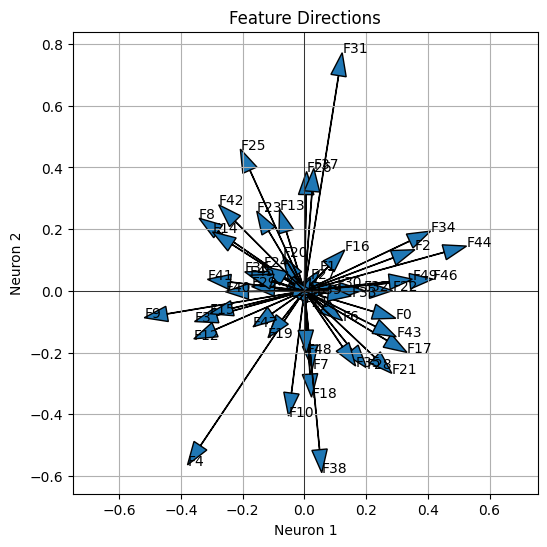

In [ ]:
import matplotlib.pyplot as plt

W = model.weights.detach().cpu().numpy()  # shape (2, 5)

plt.figure(figsize=(6, 6))

for i in range(W.shape[1]):
    x = W[0, i]
    y = W[1, i]

    # draw vector from origin
    plt.arrow(
        0, 0, x, y,
        length_includes_head=True,
        head_width=0.05
    )

    plt.text(x, y, f"F{i}")

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.xlabel("Neuron 1")
plt.ylabel("Neuron 2")
plt.title("Feature Directions")
plt.axis("equal")
plt.grid(True)
plt.show()

In [ ]:
data[4]

tensor([0.0000, 0.0000, 0.0000, 0.4399, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0322, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6298, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0238, 0.0000,
        0.0000, 0.3707, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.4149, 0.0000, 0.0000, 0.2707])

In [8]:
def get_loss(mat, components, data, sparsity='l1', batch_size=32):
  # Ensure mat is on the same device as reconstructed for calculations
  mat_on_device = mat.to(device) # Moved this up for consistent device usage

  # matrix reconstruction loss
  comp_list = []
  n_components = len(components)
  reconstructed = torch.zeros_like(mat_on_device, device=device) # Use mat_on_device for zeros_like reference
  for U,S,V in components:
    #S = S.reshape(1)
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (V.T)
    comp_list.append(Mi)
    reconstructed += Mi

  reconstruction_error = ((mat_on_device-reconstructed)**2).mean()

  # Matrix Cosine Similarity Loss
  mat_flat = mat_on_device.view(-1)
  reconstructed_flat = reconstructed.view(-1)
  matrix_cosine_sim = F.cosine_similarity(mat_flat, reconstructed_flat, dim=0)
  matrix_cosine_loss = (1 - matrix_cosine_sim) # We want to maximize similarity, so minimize (1 - sim)

  #column space orthogonality
  loss_col = torch.tensor(0.0, device=device)
  for i in range(n_components):
        U_i, _, _ = components[i]
        U_i_norm, _ = torch.linalg.qr(U_i.to(torch.float32))
        for j in range(i + 1, n_components):
            U_j, _, _ = components[j]
            U_j_norm, _ = torch.linalg.qr(U_j.to(torch.float32))
            overlap = U_i_norm.T @ U_j_norm
            rank_i = U_i_norm.shape[1]
            rank_j = U_j_norm.shape[1]
            norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, device=device, dtype=torch.float32))
            loss_col += (torch.norm(overlap, p="fro") / norm_factor)

  loss_row = torch.tensor(0.0,device=device)
  for i in range(n_components):
            _, _, V_i = components[i]
            V_i_norm, _ = torch.linalg.qr(V_i)
            for j in range(i + 1, n_components):
                _, _, V_j = components[j]
                V_j_norm, _ = torch.linalg.qr(V_j)
                overlap = V_i_norm.T @ V_j_norm
                rank_i = V_i_norm.shape[1]
                rank_j = V_j_norm.shape[1]
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j,device=device,dtype=torch.float32))
                loss_row += (torch.norm(overlap, p="fro")/ norm_factor)

  if n_components > 1:
        n_pairs = n_components * (n_components - 1) / 2
        loss_col /= n_pairs
        loss_row /= n_pairs



  total_batches = data.shape[0] // batch_size

  #activation reconstruction
  total_activation_reconstruction_loss = 0.0
  total_sparsity_loss = 0.0
  total_activation_cosine_sim = 0.0 # New accumulator for activation cosine similarity

  for i in range(total_batches):
    data_slice = data[i*batch_size:(i+1)*batch_size].to(device)
    comp_hidden = torch.stack([torch.einsum('bn,mn->bm',data_slice,Mi) for Mi in comp_list],dim=1)
    reconstructed_activations = torch.sum(comp_hidden,dim=1)

    target_activations_batch = torch.einsum('bn,mn->bm',data_slice,mat_on_device) # Original activations for the batch

    reconstruction_batch_loss = F.mse_loss(target_activations_batch, reconstructed_activations, reduction='mean')
    total_activation_reconstruction_loss += reconstruction_batch_loss.item()

    # Activation Cosine Similarity for the batch
    activation_cosine_sim_batch = F.cosine_similarity(target_activations_batch, reconstructed_activations, dim=1).mean()
    total_activation_cosine_sim += activation_cosine_sim_batch.item()

    #sparsity
    if sparsity == 'l1':
      comp_norm = torch.norm(comp_hidden,dim=-1,p=1)
      loss_batch = torch.sum(comp_norm,dim=1).mean(dim=0)
      total_sparsity_loss += loss_batch.item()
    elif sparsity == 'comp':
        # Use abs() to ensure 'active' status is based on magnitude,
        # not direction (positive vs negative).
        comp_norm = torch.norm(torch.abs(comp_hidden), dim=-1, p=2)
        # Calculate pairwise product
        pairwise = 3 * comp_norm.unsqueeze(2) * comp_norm.unsqueeze(1)
        # Sum the upper triangle of the pairwise interaction matrix
        loss_batch = torch.triu(pairwise, diagonal=1).sum(dim=(1, 2)).mean()
        total_sparsity_loss += loss_batch.item()
    elif sparsity == 'entrop':
      temperature = 0.1  # lower = sharper competition
      comp_norm = torch.norm(comp_hidden, dim=-1, p=2)
      # Apply temperature scaling
      logits = comp_norm / temperature  # shape: (32, 5)

      # Softmax across components (dim=-1) to get probabilities
      probs = torch.softmax(logits, dim=-1)  # shape: (32, 5)

      # Entropy loss: negative log probability of the max component
      # This encourages one component to dominate
      max_probs, max_idx = torch.max(probs, dim=-1)  # shape: (32,)

      # Option 1: Negative log likelihood of the max probability
      loss_competition = -torch.log(max_probs + 1e-8).mean()
      total_sparsity_loss += loss_competition.item()

  total_activation_reconstruction_loss /= total_batches
  total_sparsity_loss /= total_batches
  total_activation_cosine_sim /= total_batches # Average over batches
  activation_cosine_loss = (1 - total_activation_cosine_sim) # Convert similarity to loss

  # Combined loss with new cosine similarity terms
  total_loss = 5*reconstruction_error + 5*loss_col + 3*loss_row +1.0*total_activation_reconstruction_loss + 3.0*total_sparsity_loss + 0.5*matrix_cosine_loss + 0.5*activation_cosine_loss
  return total_loss

In [9]:
def train(mat, data, n_components=5, n_iterations=65, batch_size=32,rank=4):
    d_out, d_in = mat.shape
    components = []


    # Initialize components
    for _ in range(n_components):
        U = torch.nn.init.xavier_normal_(torch.empty(d_out, rank, requires_grad=True))
        V = torch.nn.init.xavier_normal_(torch.empty(d_in, rank, requires_grad=True))
        S = torch.ones(rank, requires_grad=True)
        components.append((U, S, V))

    param = [p for comp in components for p in comp]
    optimizer = torch.optim.Adam(param, lr=1e-2)

    # --- Scheduler Setup ---
    # mode='min' because we want to reduce LR when loss stops decreasing
    # factor=0.5 means new_lr = lr * 0.5
    # patience=5 means wait 5 epochs of no improvement before dropping LR
    '''scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2   )'''

    for epoch in range(n_iterations):
        optimizer.zero_grad()
        loss = get_loss(mat, components, data, sparsity='comp', batch_size=batch_size)
        loss.backward()
        optimizer.step()

        # --- Update Scheduler ---
        #scheduler.step(loss)

        print(f"Epoch: {epoch+1}, Loss: {loss.item():.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    return components

In [ ]:
n_components = 100
d_in = N_FEATURES
d_out = M_NEURONS
factor = 1
rank = max(1, min(d_in, d_out) // n_components*factor)
components = train(model.weights.detach().cpu(), data,n_components=n_components,batch_size=BATCH_SIZE,rank = rank)

Epoch: 1, Loss: 15594.407227, LR: 0.010000


In [ ]:
comp_list = []
for U,S,V in components:
  #S = S.reshape(1)
  S = F.softplus(S)
  Mi = U @ torch.diag(S) @ (V.T)
  comp_list.append(Mi)


In [ ]:
def get_matrix_reconstruction_metrics(model,comp_list):
  # Get the original weights and the reconstructed matrix
  original_weights = model.weights.detach().cpu()
  reconstructed_matrix = torch.stack(comp_list, dim=0).sum(dim=0).detach().cpu()

  # Flatten both matrices to 1D vectors for cosine similarity calculation
  original_weights_flat = original_weights.view(-1)
  reconstructed_matrix_flat = reconstructed_matrix.view(-1)

  # Calculate cosine similarity
  similarity_metric = cosine_similarity(original_weights_flat, reconstructed_matrix_flat, dim=0)

  reconstruction_error = ((original_weights - reconstructed_matrix)**2).mean()
  print(f"Reconstruction MSE: {reconstruction_error.item():.6f}")
  print(f"Cosine Similarity between original and reconstructed weights: {similarity_metric.item():.6f}")
  return reconstruction_error, similarity_metric
_,_ = get_matrix_reconstruction_metrics(model,comp_list)


Reconstruction MSE: 0.003767
Cosine Similarity between original and reconstructed weights: 0.967129


In [ ]:
def get_activation_reconstruction_error(model,data,comp_list):
  mat_on_device = model.weights.detach().to(device)

  # Calculate target activations by passing data_slice through the original model weights
  target_activations = torch.einsum('bn,mn->bm', data, mat_on_device)
  print(f'Average norm of activation:{torch.norm(target_activations,p=2).mean(dim=0)}')

  # Calculate activations reconstructed from the learned components
  comp_hidden = torch.stack([torch.einsum('bn,mn->bm', data, Mi) for Mi in comp_list], dim=1)
  reconstructed_activations = torch.sum(comp_hidden, dim=1)

  # Calculate the average MSE loss between reconstructed and target activations
  average_mse_loss = F.mse_loss(reconstructed_activations, target_activations, reduction='mean')

  print(f"Average activation reconstruction MSE loss: {average_mse_loss.item():.6f}")
  return average_mse_loss
_ = get_activation_reconstruction_error(model,data,comp_list)

Average norm of activation:424.3042907714844
Average activation reconstruction MSE loss: 0.006373


In [ ]:
def get_activation_reconstruction_similarity(model,data,comp_list):
  mat_on_device = model.weights.detach().to(device)

  # Calculate target activations by passing data_slice through the original model weights
  target_activations = torch.einsum('bn,mn->bm', data, model.weights)
  reconstructed_activations = torch.stack([torch.einsum('bn,mn->bm', data, Mi) for Mi in comp_list], dim=1).sum(dim=1)

    # Calculate the cosine similarity between target and reconstructed activations
  cosine_similarities = F.cosine_similarity(target_activations, reconstructed_activations, dim=1)

  # Calculate descriptive statistics
  avg_cosine_similarity = torch.mean(cosine_similarities)
  min_cosine_similarity = torch.min(cosine_similarities)
  max_cosine_similarity = torch.max(cosine_similarities)
  median_cosine_similarity_value = torch.median(cosine_similarities) # Get the median value directly
  variance_cosine_similarity = torch.var(cosine_similarities)

  print(f"\nCosine Similarity between target and reconstructed activations per data point:")
  print(f"  Average: {avg_cosine_similarity.item():.6f}")
  print(f"  Minimum: {min_cosine_similarity.item():.6f}")
  print(f"  Maximum: {max_cosine_similarity.item():.6f}")
  print(f"  Median:  {median_cosine_similarity_value.item():.6f}") # Directly call .item()
  print(f"  Variance: {variance_cosine_similarity.item():.6f}")
  return avg_cosine_similarity,min_cosine_similarity,max_cosine_similarity,median_cosine_similarity_value,variance_cosine_similarity
_ ,_,_,_,_ = get_activation_reconstruction_similarity(model,data,comp_list)


Cosine Similarity between target and reconstructed activations per data point:
  Average: 0.958718
  Minimum: 0.000000
  Maximum: 0.998374
  Median:  0.971040
  Variance: 0.005345


In [ ]:
import torch
import statistics

def get_orthogonality_metrics(components):
    # --- Helper for processing overlaps ---
    def process_overlaps(bases):
        all_overlaps = []
        num_bases = len(bases)

        for i in range(num_bases):
            Bi = bases[i]
            rank_i = Bi.shape[1]
            for j in range(i + 1, num_bases):
                Bj = bases[j]
                rank_j = Bj.shape[1]

                overlap = Bi.T @ Bj
                fro_norm = torch.norm(overlap, p='fro')
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, dtype=torch.float32))
                normalized_fro_norm = (fro_norm / norm_factor).item()

                all_overlaps.append(normalized_fro_norm)
                print(f"  Overlap between Component {i+1} and Component {j+1}: {normalized_fro_norm:.6f}")

        avg = statistics.mean(all_overlaps) if all_overlaps else 0.0
        med = statistics.median(all_overlaps) if all_overlaps else 0.0
        return avg, med

    # --- Process Column Space (U) ---
    print("Normalized Frobenius Norm of Overlap for Column Space (U):\n")
    U_bases = [torch.linalg.qr(c[0].to(torch.float32))[0].cpu().detach() for c in components]
    col_avg, col_med = process_overlaps(U_bases)
    print(f"-> Column Space | Avg: {col_avg:.6f}, Median: {col_med:.6f}")

    # --- Process Row Space (V) ---
    print("\nNormalized Frobenius Norm of Overlap for Row Space (V):\n")
    V_bases = [torch.linalg.qr(c[2].to(torch.float32))[0].cpu().detach() for c in components]
    row_avg, row_med = process_overlaps(V_bases)
    print(f"-> Row Space    | Avg: {row_avg:.6f}, Median: {row_med:.6f}")

    return col_avg,col_med,row_avg,row_med
_,_,_,_ = get_orthogonality_metrics(components)

Normalized Frobenius Norm of Overlap for Column Space (U):

  Overlap between Component 1 and Component 2: 0.001799
  Overlap between Component 1 and Component 3: 0.001704
  Overlap between Component 1 and Component 4: 0.001122
  Overlap between Component 1 and Component 5: 0.005240
  Overlap between Component 2 and Component 3: 0.001374
  Overlap between Component 2 and Component 4: 0.006461
  Overlap between Component 2 and Component 5: 0.001006
  Overlap between Component 3 and Component 4: 0.004155
  Overlap between Component 3 and Component 5: 0.001775
  Overlap between Component 4 and Component 5: 0.007983
-> Column Space | Avg: 0.003262, Median: 0.001787

Normalized Frobenius Norm of Overlap for Row Space (V):

  Overlap between Component 1 and Component 2: 0.001243
  Overlap between Component 1 and Component 3: 0.001373
  Overlap between Component 1 and Component 4: 0.001284
  Overlap between Component 1 and Component 5: 0.001345
  Overlap between Component 2 and Component 3: 0

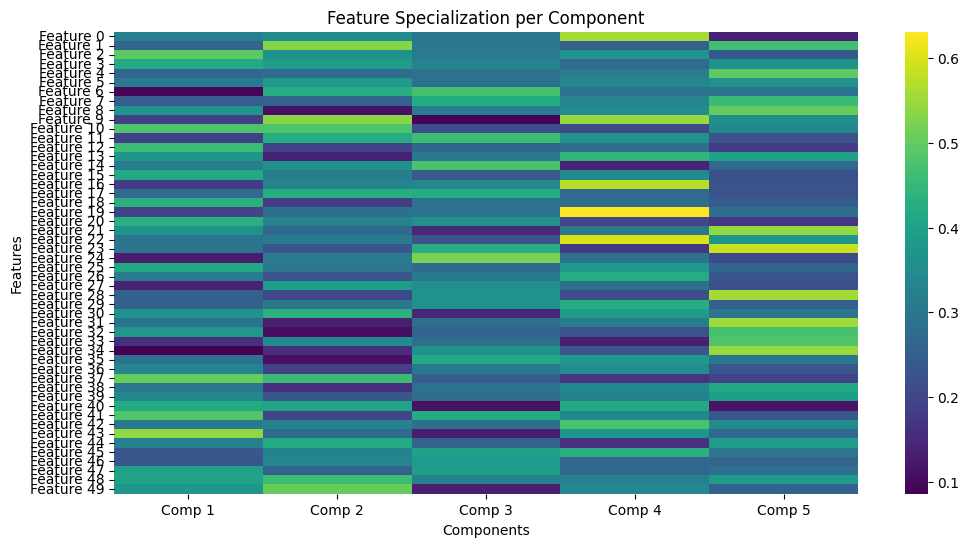

In [ ]:


# Collect the V matrices and stack them
# V_matrices shape: (n_components, n_features, rank)
V_mats = [comp[2].detach().cpu() for comp in components]
V_stacked = torch.stack(V_mats, dim=0)

# Calculate the norm of each feature for each component
# This shows how much "energy" each component assigns to each feature
# shape: (n_components, n_features)
feature_specialization = torch.norm(V_stacked, dim=2).T

plt.figure(figsize=(12, 6))
sns.heatmap(feature_specialization.numpy(),
            cmap="viridis",
            xticklabels=[f"Comp {i+1}" for i in range(len(components))],
            yticklabels=[f"Feature {i}" for i in range(N_FEATURES)])
plt.title("Feature Specialization per Component")
plt.xlabel("Components")
plt.ylabel("Features")
plt.show()

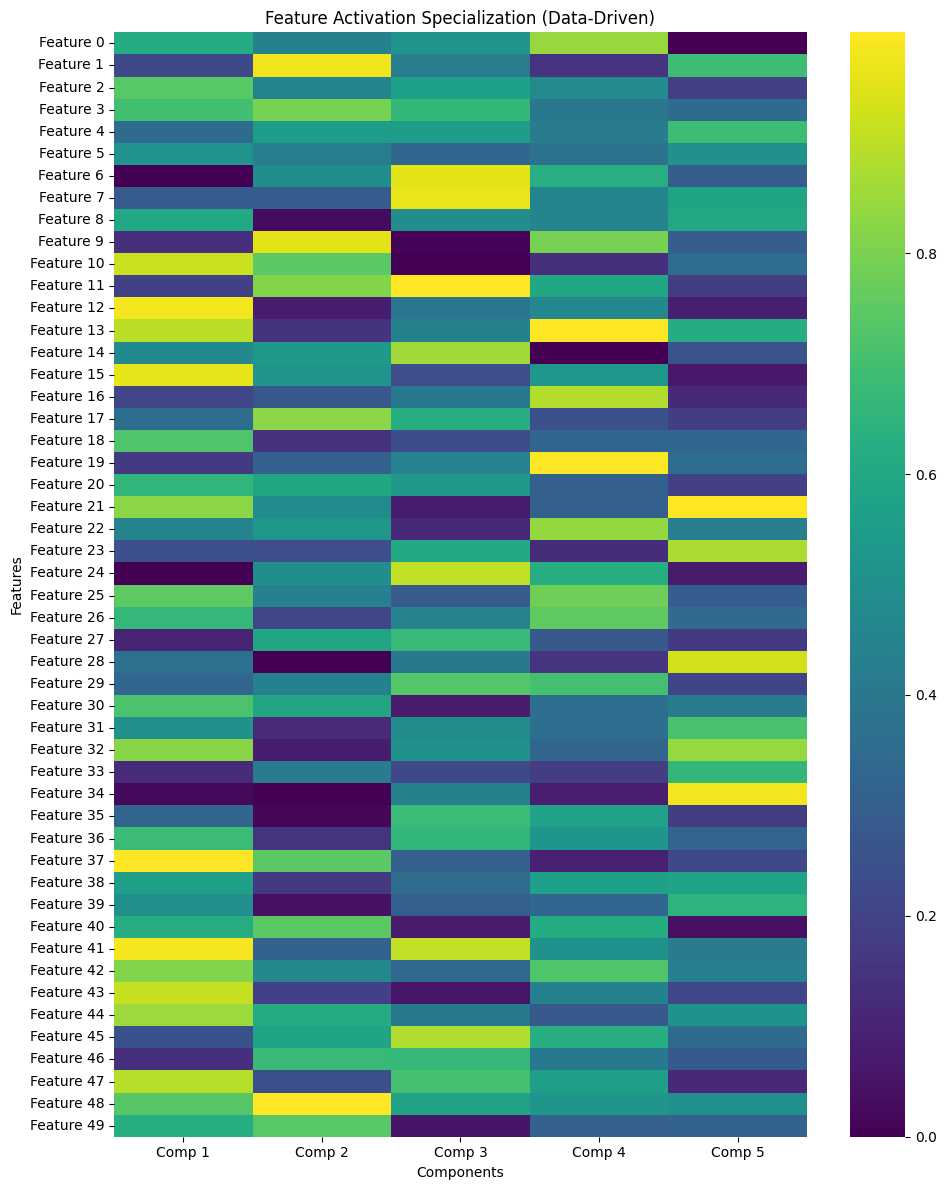

In [ ]:
# 1. Reconstruct Mi matrices from components
# Each component Mi = U @ diag(S) @ V.T
comp_list = []
for U, S, V in components:
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (V.T)
    comp_list.append(Mi)

# 2. Calculate Data-Driven Specialization
# Shape: (n_features, n_components)
n_features = data.shape[1]
n_components = len(components)
specialization = torch.zeros((n_features, n_components))

# We use a subset of data for efficient calculation
subset_size = min(len(data), 10000)
data_sample = data[:subset_size].to(device)

for j in range(n_features):
    # Find indices where feature j is active
    active_mask = (data_sample[:, j] != 0)
    if active_mask.sum() > 0:
        data_subset = data_sample[active_mask]

        for k in range(n_components):
            # The model forward pass uses einsum 'bn,mn->bm'
            # This is equivalent to data @ Mi.T
            Mi = comp_list[k].to(device)
            activations = torch.abs(data_subset @ Mi.T)

            # Record the average activation strength of this component
            # for this specific feature
            specialization[j, k] = activations.mean()

# 3. Normalize for visualization (Scale 0-1 per component column)
# This allows us to see the "relative" specialization of each component
specialization_norm = (specialization - specialization.min(dim=0, keepdim=True)[0]) / \
                      (specialization.max(dim=0, keepdim=True)[0] - specialization.min(dim=0, keepdim=True)[0] + 1e-9)

# 4. Plot the Heatmap
plt.figure(figsize=(10, 12))

# Use .detach() to remove the graph before conversion
data_to_plot = specialization_norm.detach().cpu().numpy()

sns.heatmap(data_to_plot,
            cmap="viridis",
            xticklabels=[f"Comp {i+1}" for i in range(n_components)],
            yticklabels=[f"Feature {i}" for i in range(n_features)])

plt.title("Feature Activation Specialization (Data-Driven)")
plt.xlabel("Components")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
def calculate_sparsity_and_peaks(components, data, device='cpu', batch_size=32):
    # 1. Reconstruct Mi matrices
    # Mi = U @ diag(S) @ V.T
    # U is (d_out, rank), V is (d_in, rank)
    # Mi will be (d_out, d_in)
    comp_list = [U @ torch.diag(F.softplus(S)) @ V.T for U, S, V in components]

    # data is (n_samples, n_features)
    n_features = data.shape[1]
    n_components = len(components)

    # 2. Calculate Activations
    # Mi is (d_out, d_in).
    # data @ Mi.T results in (n_samples, d_out)
    # So activations should be measured across the d_out dimension (features)

    data_sample = data[:min(len(data), 5000)].to(device)
    activations = []

    for Mi in comp_list:
        # data @ Mi.T -> (sample_size, d_out)
        # We want to see how each feature (d_out) activates the component
        act = torch.abs(data_sample @ Mi.to(device).T).mean(dim=0)
        activations.append(act)

    # Stack to shape: (d_out, n_components)
    activation_matrix = torch.stack(activations, dim=1)

    # 3. Corrected Loop
    # Use activation_matrix.shape[0] instead of assuming n_features matches input data
    num_rows = activation_matrix.shape[0]

    components_active_per_feature = []
    peak_to_other_ratios = []

    for i in range(num_rows):
        row = activation_matrix[i]

        # Sparsity
        max_val = row.max()
        is_active = row > (0.5 * max_val)
        components_active_per_feature.append(is_active.sum().float())

        # Peak-to-Other
        peak_val = max_val
        is_not_peak = (row != peak_val)
        if is_not_peak.sum() > 0:
            other_mean = row[is_not_peak].mean()
            ratio = (peak_val / (other_mean + 1e-9)).item()
            peak_to_other_ratios.append(ratio)

    avg_active_components = torch.tensor(components_active_per_feature).mean().item()
    avg_peak_to_other = np.mean(peak_to_other_ratios)

    print(f"--- Sparsity Metrics ---")
    print(f"Avg Components Active per Feature: {avg_active_components:.2f}")
    print(f"Avg Peak-to-Other Activation Ratio: {avg_peak_to_other:.2f}")

    return avg_active_components, avg_peak_to_other
# Usage:
avg_sparsity, avg_ratio = calculate_sparsity_and_peaks(components, data, device)

--- Sparsity Metrics ---
Avg Components Active per Feature: 3.70
Avg Peak-to-Other Activation Ratio: 1.69


In [ ]:
import torch
import torch.nn.functional as F
from itertools import combinations

def run_ablation(mat, components, data):
    # Baseline model's weight
    baseline = torch.einsum('bn,mn->bm', data, mat)

    # Precompute activation for all components
    # Assuming components is a list of weight matrices [M1, M2, ..., Mn]
    comp_activation = torch.stack([torch.einsum('bn,mn->bm', data, Mi) for Mi in components], dim=1)

    # Full reconstruction
    total_reconstructed = torch.sum(comp_activation, dim=1)

    print(f"Base average MSE LOSS: {F.mse_loss(baseline, total_reconstructed, reduction='mean').item():.6f}\n")

    # Helper to calculate and print loss
    def report_loss(label, current_reconstruction):
        mse = F.mse_loss(baseline, current_reconstruction, reduction='mean').item()
        print(f"{label} MSE LOSS: {mse:.6f}")

    # 1. Single Ablations (Ablate one at a time)
    print("--- Single Ablations ---")
    for i in range(len(components)):
        reconstructed = total_reconstructed - comp_activation[:, i, :]
        report_loss(f"Ablate component {i}", reconstructed)

    # 2. Pairwise Ablations (Ablate two at a time)
    print("\n--- Pairwise Ablations ---")
    for i, j in combinations(range(len(components)), 2):
        reconstructed = total_reconstructed - (comp_activation[:, i, :] + comp_activation[:, j, :])
        report_loss(f"Ablate components {i}, {j}", reconstructed)

    # 3. Triplet Ablations (Ablate three at a time)
    print("\n--- Triplet Ablations ---")
    for i, j, k in combinations(range(len(components)), 3):
        reconstructed = total_reconstructed - (comp_activation[:, i, :] + comp_activation[:, j, :] + comp_activation[:, k, :])
        report_loss(f"Ablate components {i}, {j}, {k}", reconstructed)

# Run the function
run_ablation(model.weights, comp_list, data)

Base average MSE LOSS: 0.006373

--- Single Ablations ---
Ablate component 0 MSE LOSS: 0.023510
Ablate component 1 MSE LOSS: 0.022581
Ablate component 2 MSE LOSS: 0.023221
Ablate component 3 MSE LOSS: 0.022924
Ablate component 4 MSE LOSS: 0.023282

--- Pairwise Ablations ---
Ablate components 0, 1 MSE LOSS: 0.039718
Ablate components 0, 2 MSE LOSS: 0.040358
Ablate components 0, 3 MSE LOSS: 0.040061
Ablate components 0, 4 MSE LOSS: 0.040418
Ablate components 1, 2 MSE LOSS: 0.039429
Ablate components 1, 3 MSE LOSS: 0.039134
Ablate components 1, 4 MSE LOSS: 0.039491
Ablate components 2, 3 MSE LOSS: 0.039773
Ablate components 2, 4 MSE LOSS: 0.040131
Ablate components 3, 4 MSE LOSS: 0.039834

--- Triplet Ablations ---
Ablate components 0, 1, 2 MSE LOSS: 0.056566
Ablate components 0, 1, 3 MSE LOSS: 0.056270
Ablate components 0, 1, 4 MSE LOSS: 0.056626
Ablate components 0, 2, 3 MSE LOSS: 0.056909
Ablate components 0, 2, 4 MSE LOSS: 0.057266
Ablate components 0, 3, 4 MSE LOSS: 0.056969
Ablate 

--- Specialization Metrics for Feature 29 ---
Peak-to-Other Activation Ratio: 1.0273


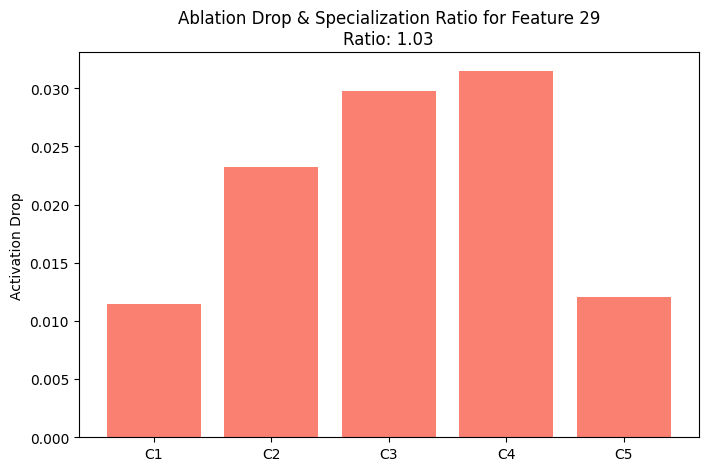

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def plot_activation_ablation_and_ratio(feature_idx, data, components, device):
    data = data.to(device)

    # 1. Collect activations per component specifically for the target feature
    # We look at how strongly each component responds to this specific feature
    comp_activations = []
    for U, S, V in components:
        Mi = (U @ torch.diag(F.softplus(S)) @ V.T).to(device)
        # Projection: (n_samples, d_out)
        projection = torch.abs(data @ Mi.T)
        # Mean activation intensity across data for this component
        comp_activations.append(projection.sum(dim=1).mean().item())

    comp_activations = torch.tensor(comp_activations)

    # 2. Calculate Peak-to-Other Ratio for this feature
    peak_val = comp_activations.max()
    is_not_peak = (comp_activations != peak_val)

    if is_not_peak.sum() > 0:
        other_mean = comp_activations[is_not_peak].mean()
        ratio = (peak_val / (other_mean + 1e-9)).item()
    else:
        ratio = 1.0

    print(f"--- Specialization Metrics for Feature {feature_idx} ---")
    print(f"Peak-to-Other Activation Ratio: {ratio:.4f}")

    # 3. Perform Ablation (existing logic)
    baseline = comp_activations.tolist()

    data_modified = data.clone()
    data_modified[:, feature_idx] = 0

    ablated = []
    for U, S, V in components:
        Mi = (U @ torch.diag(F.softplus(S)) @ V.T).to(device)
        act = torch.abs(data_modified @ Mi.T).sum(dim=1).mean().item()
        ablated.append(act)

    drops = [b - a for b, a in zip(baseline, ablated)]

    # 4. Plot
    plt.figure(figsize=(8, 5))
    plt.bar([f"C{i+1}" for i in range(len(components))], drops, color='salmon')
    plt.title(f"Ablation Drop & Specialization Ratio for Feature {feature_idx}\nRatio: {ratio:.2f}")
    plt.ylabel("Activation Drop")
    plt.show()

    return ratio

# Usage:
ratio = plot_activation_ablation_and_ratio(29, data, components, device)

--- Global Specialization Metric ---
Average Peak-to-Other Activation Ratio across 50 features: 1.6207


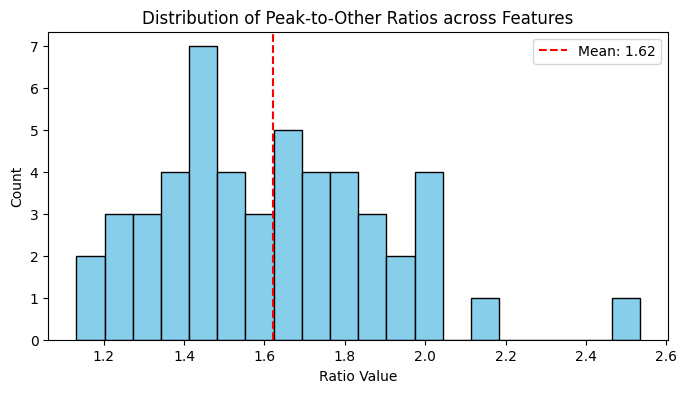

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def calculate_global_specialization_ratio(data, components, device):
    """
    Computes the average Peak-to-Other ratio across all input features.
    """
    data = data.to(device)
    n_features = data.shape[1]
    n_components = len(components)

    # Pre-calculate all Mi matrices for efficiency
    Mi_list = [(U @ torch.diag(F.softplus(S)) @ V.T).to(device) for U, S, V in components]

    all_ratios = []

    # Iterate over every feature index
    for feat_idx in range(n_features):
        comp_activations = []

        # 1. Get activation intensity for each component for this feature
        # We need the response of each component to the current feature index
        for Mi in Mi_list:
            # We look at the projection, but since we are interested in feature importance,
            # we isolate the contribution of this specific input feature.
            # A common way is to see the weight magnitude for this feature in Mi
            # or the response of Mi to a one-hot input.
            # Using weight magnitude (column norm) as a proxy for feature response:
            activation_strength = torch.norm(Mi[:, feat_idx], p=2).item()
            comp_activations.append(activation_strength)

        comp_activations = torch.tensor(comp_activations)

        # 2. Calculate Peak-to-Other Ratio for this feature
        peak_val = comp_activations.max()
        is_not_peak = (comp_activations != peak_val)

        if is_not_peak.sum() > 0:
            other_mean = comp_activations[is_not_peak].mean()
            ratio = (peak_val / (other_mean + 1e-9)).item()
        else:
            ratio = 1.0

        all_ratios.append(ratio)

    # 3. Calculate Average
    avg_ratio = np.mean(all_ratios)

    print(f"--- Global Specialization Metric ---")
    print(f"Average Peak-to-Other Activation Ratio across {n_features} features: {avg_ratio:.4f}")

    # 4. Plot distribution
    plt.figure(figsize=(8, 4))
    plt.hist(all_ratios, bins=20, color='skyblue', edgecolor='black')
    plt.axvline(avg_ratio, color='red', linestyle='dashed', label=f'Mean: {avg_ratio:.2f}')
    plt.title("Distribution of Peak-to-Other Ratios across Features")
    plt.xlabel("Ratio Value")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    return avg_ratio

# Usage:
avg_ratio = calculate_global_specialization_ratio(data, components, device)


--- Testing Factor: 1 ---
Epoch: 1, Loss: 52.071251, LR: 0.010000
Epoch: 2, Loss: 48.495636, LR: 0.010000
Epoch: 3, Loss: 45.394459, LR: 0.010000
Epoch: 4, Loss: 42.704884, LR: 0.010000
Epoch: 5, Loss: 40.354111, LR: 0.010000
Epoch: 6, Loss: 38.303410, LR: 0.010000
Epoch: 7, Loss: 36.532921, LR: 0.010000
Epoch: 8, Loss: 35.012688, LR: 0.010000
Epoch: 9, Loss: 33.705906, LR: 0.010000
Epoch: 10, Loss: 32.574596, LR: 0.010000
Epoch: 11, Loss: 31.584505, LR: 0.010000
Epoch: 12, Loss: 30.699503, LR: 0.010000
Epoch: 13, Loss: 29.885887, LR: 0.010000
Epoch: 14, Loss: 29.134182, LR: 0.010000
Epoch: 15, Loss: 28.440193, LR: 0.010000
Epoch: 16, Loss: 27.794710, LR: 0.010000
Epoch: 17, Loss: 27.188536, LR: 0.010000
Epoch: 18, Loss: 26.618380, LR: 0.010000
Epoch: 19, Loss: 26.089497, LR: 0.010000
Epoch: 20, Loss: 25.602381, LR: 0.010000
Epoch: 21, Loss: 25.170780, LR: 0.010000
Epoch: 22, Loss: 24.802837, LR: 0.010000
Epoch: 23, Loss: 24.496309, LR: 0.010000
Epoch: 24, Loss: 24.240456, LR: 0.01000

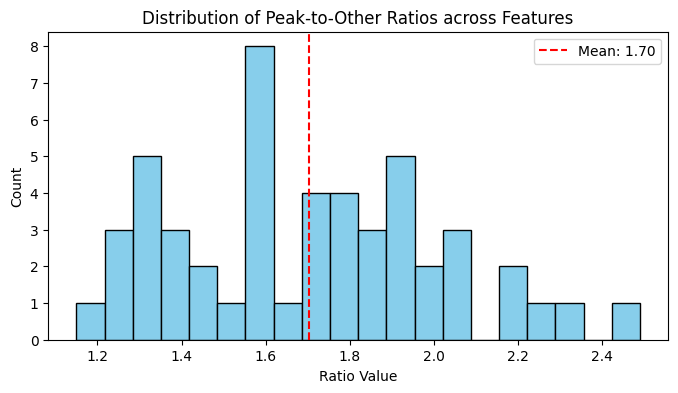

Epoch: 1, Loss: 66.248543, LR: 0.010000
Epoch: 2, Loss: 61.123341, LR: 0.010000
Epoch: 3, Loss: 56.735313, LR: 0.010000
Epoch: 4, Loss: 52.937691, LR: 0.010000
Epoch: 5, Loss: 49.627972, LR: 0.010000
Epoch: 6, Loss: 46.733105, LR: 0.010000
Epoch: 7, Loss: 44.189880, LR: 0.010000
Epoch: 8, Loss: 41.954224, LR: 0.010000
Epoch: 9, Loss: 39.988129, LR: 0.010000
Epoch: 10, Loss: 38.243279, LR: 0.010000
Epoch: 11, Loss: 36.690189, LR: 0.010000
Epoch: 12, Loss: 35.309635, LR: 0.010000
Epoch: 13, Loss: 34.081982, LR: 0.010000
Epoch: 14, Loss: 32.993904, LR: 0.010000
Epoch: 15, Loss: 32.037052, LR: 0.010000
Epoch: 16, Loss: 31.200388, LR: 0.010000
Epoch: 17, Loss: 30.465603, LR: 0.010000
Epoch: 18, Loss: 29.808935, LR: 0.010000
Epoch: 19, Loss: 29.213953, LR: 0.010000
Epoch: 20, Loss: 28.665016, LR: 0.010000
Epoch: 21, Loss: 28.147253, LR: 0.010000
Epoch: 22, Loss: 27.653603, LR: 0.010000
Epoch: 23, Loss: 27.182335, LR: 0.010000
Epoch: 24, Loss: 26.730204, LR: 0.010000
Epoch: 25, Loss: 26.29620

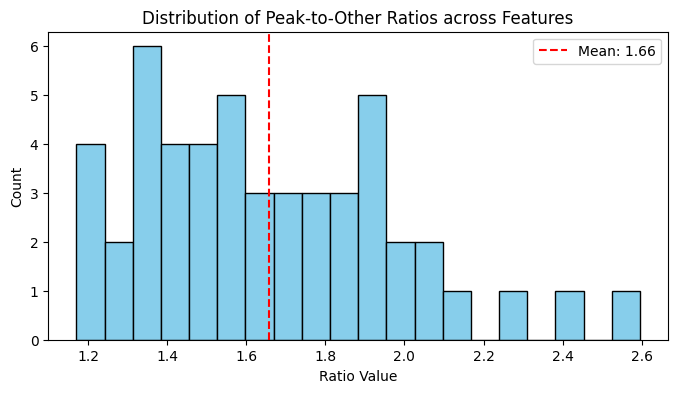

Epoch: 1, Loss: 55.059326, LR: 0.010000
Epoch: 2, Loss: 51.159077, LR: 0.010000
Epoch: 3, Loss: 47.768818, LR: 0.010000
Epoch: 4, Loss: 44.830761, LR: 0.010000
Epoch: 5, Loss: 42.284782, LR: 0.010000
Epoch: 6, Loss: 40.077095, LR: 0.010000
Epoch: 7, Loss: 38.150913, LR: 0.010000
Epoch: 8, Loss: 36.455959, LR: 0.010000
Epoch: 9, Loss: 34.946800, LR: 0.010000
Epoch: 10, Loss: 33.601105, LR: 0.010000
Epoch: 11, Loss: 32.405434, LR: 0.010000
Epoch: 12, Loss: 31.342371, LR: 0.010000
Epoch: 13, Loss: 30.394461, LR: 0.010000
Epoch: 14, Loss: 29.550541, LR: 0.010000
Epoch: 15, Loss: 28.794043, LR: 0.010000
Epoch: 16, Loss: 28.118818, LR: 0.010000
Epoch: 17, Loss: 27.527678, LR: 0.010000
Epoch: 18, Loss: 27.016109, LR: 0.010000
Epoch: 19, Loss: 26.574394, LR: 0.010000
Epoch: 20, Loss: 26.193283, LR: 0.010000
Epoch: 21, Loss: 25.856291, LR: 0.010000
Epoch: 22, Loss: 25.545321, LR: 0.010000
Epoch: 23, Loss: 25.251976, LR: 0.010000
Epoch: 24, Loss: 24.970600, LR: 0.010000
Epoch: 25, Loss: 24.69725

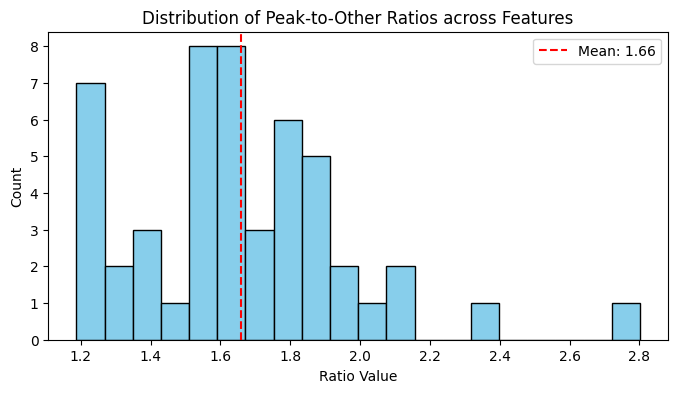

Epoch: 1, Loss: 55.077774, LR: 0.010000
Epoch: 2, Loss: 50.960796, LR: 0.010000
Epoch: 3, Loss: 47.470680, LR: 0.010000
Epoch: 4, Loss: 44.499802, LR: 0.010000
Epoch: 5, Loss: 41.944824, LR: 0.010000
Epoch: 6, Loss: 39.756626, LR: 0.010000
Epoch: 7, Loss: 37.875908, LR: 0.010000
Epoch: 8, Loss: 36.233364, LR: 0.010000
Epoch: 9, Loss: 34.785297, LR: 0.010000
Epoch: 10, Loss: 33.511436, LR: 0.010000
Epoch: 11, Loss: 32.397057, LR: 0.010000
Epoch: 12, Loss: 31.422640, LR: 0.010000
Epoch: 13, Loss: 30.564291, LR: 0.010000
Epoch: 14, Loss: 29.792509, LR: 0.010000
Epoch: 15, Loss: 29.087572, LR: 0.010000
Epoch: 16, Loss: 28.442844, LR: 0.010000
Epoch: 17, Loss: 27.843134, LR: 0.010000
Epoch: 18, Loss: 27.275724, LR: 0.010000
Epoch: 19, Loss: 26.735682, LR: 0.010000
Epoch: 20, Loss: 26.218740, LR: 0.010000
Epoch: 21, Loss: 25.723730, LR: 0.010000
Epoch: 22, Loss: 25.256123, LR: 0.010000
Epoch: 23, Loss: 24.823875, LR: 0.010000
Epoch: 24, Loss: 24.434135, LR: 0.010000
Epoch: 25, Loss: 24.08542

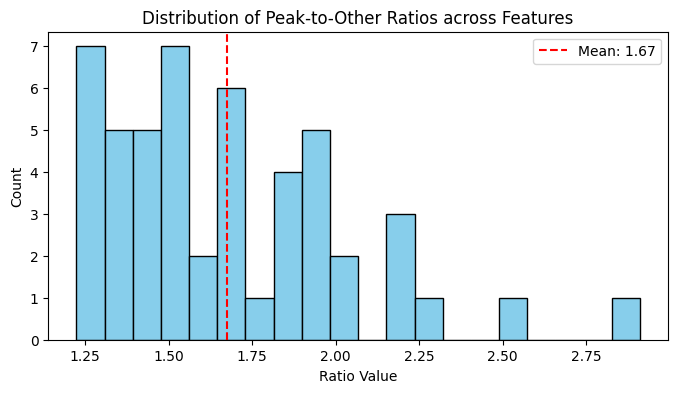

Epoch: 1, Loss: 60.333851, LR: 0.010000
Epoch: 2, Loss: 55.978836, LR: 0.010000
Epoch: 3, Loss: 52.285351, LR: 0.010000
Epoch: 4, Loss: 49.122356, LR: 0.010000
Epoch: 5, Loss: 46.390339, LR: 0.010000
Epoch: 6, Loss: 44.017273, LR: 0.010000
Epoch: 7, Loss: 41.948887, LR: 0.010000
Epoch: 8, Loss: 40.144508, LR: 0.010000
Epoch: 9, Loss: 38.572025, LR: 0.010000
Epoch: 10, Loss: 37.199589, LR: 0.010000
Epoch: 11, Loss: 35.998180, LR: 0.010000
Epoch: 12, Loss: 34.940662, LR: 0.010000
Epoch: 13, Loss: 34.002914, LR: 0.010000
Epoch: 14, Loss: 33.168499, LR: 0.010000
Epoch: 15, Loss: 32.420872, LR: 0.010000
Epoch: 16, Loss: 31.743803, LR: 0.010000
Epoch: 17, Loss: 31.118500, LR: 0.010000
Epoch: 18, Loss: 30.518457, LR: 0.010000
Epoch: 19, Loss: 29.937830, LR: 0.010000
Epoch: 20, Loss: 29.378468, LR: 0.010000
Epoch: 21, Loss: 28.846029, LR: 0.010000
Epoch: 22, Loss: 28.347343, LR: 0.010000
Epoch: 23, Loss: 27.887005, LR: 0.010000
Epoch: 24, Loss: 27.465328, LR: 0.010000
Epoch: 25, Loss: 27.07931

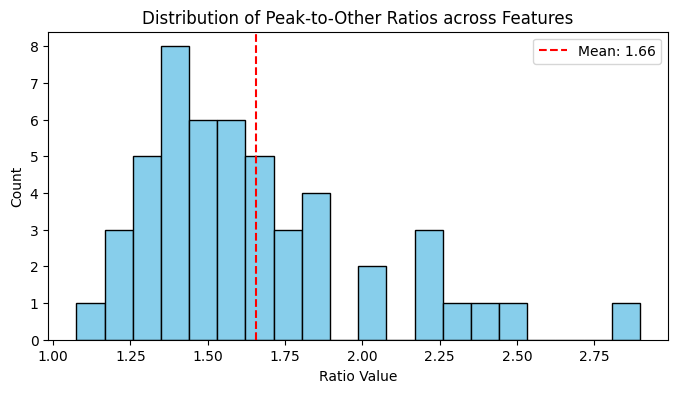

Epoch: 1, Loss: 56.505924, LR: 0.010000
Epoch: 2, Loss: 52.777672, LR: 0.010000
Epoch: 3, Loss: 49.584614, LR: 0.010000
Epoch: 4, Loss: 46.828094, LR: 0.010000
Epoch: 5, Loss: 44.418736, LR: 0.010000
Epoch: 6, Loss: 42.309761, LR: 0.010000
Epoch: 7, Loss: 40.468105, LR: 0.010000
Epoch: 8, Loss: 38.849743, LR: 0.010000
Epoch: 9, Loss: 37.416008, LR: 0.010000
Epoch: 10, Loss: 36.134899, LR: 0.010000
Epoch: 11, Loss: 34.980301, LR: 0.010000
Epoch: 12, Loss: 33.932034, LR: 0.010000
Epoch: 13, Loss: 32.972992, LR: 0.010000
Epoch: 14, Loss: 32.084236, LR: 0.010000
Epoch: 15, Loss: 31.259014, LR: 0.010000
Epoch: 16, Loss: 30.495686, LR: 0.010000
Epoch: 17, Loss: 29.794977, LR: 0.010000
Epoch: 18, Loss: 29.158878, LR: 0.010000
Epoch: 19, Loss: 28.588345, LR: 0.010000
Epoch: 20, Loss: 28.083311, LR: 0.010000
Epoch: 21, Loss: 27.636547, LR: 0.010000
Epoch: 22, Loss: 27.234213, LR: 0.010000
Epoch: 23, Loss: 26.868078, LR: 0.010000
Epoch: 24, Loss: 26.533371, LR: 0.010000
Epoch: 25, Loss: 26.21891

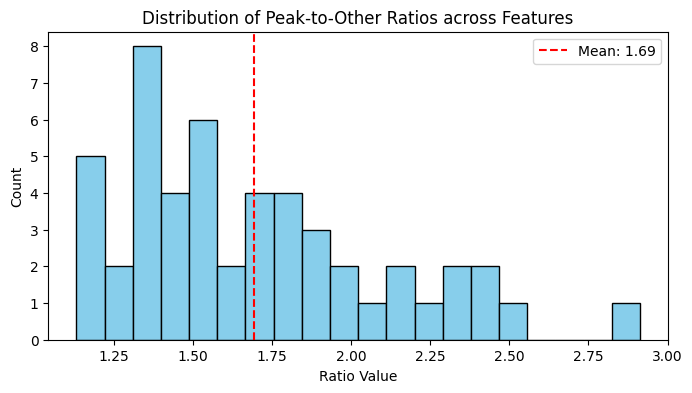

Epoch: 1, Loss: 61.521034, LR: 0.010000
Epoch: 2, Loss: 56.796711, LR: 0.010000
Epoch: 3, Loss: 52.741791, LR: 0.010000
Epoch: 4, Loss: 49.230671, LR: 0.010000
Epoch: 5, Loss: 46.180931, LR: 0.010000
Epoch: 6, Loss: 43.521542, LR: 0.010000
Epoch: 7, Loss: 41.221214, LR: 0.010000
Epoch: 8, Loss: 39.249920, LR: 0.010000
Epoch: 9, Loss: 37.561863, LR: 0.010000
Epoch: 10, Loss: 36.107456, LR: 0.010000
Epoch: 11, Loss: 34.836872, LR: 0.010000
Epoch: 12, Loss: 33.706867, LR: 0.010000
Epoch: 13, Loss: 32.688477, LR: 0.010000
Epoch: 14, Loss: 31.765934, LR: 0.010000
Epoch: 15, Loss: 30.930845, LR: 0.010000
Epoch: 16, Loss: 30.175005, LR: 0.010000
Epoch: 17, Loss: 29.491154, LR: 0.010000
Epoch: 18, Loss: 28.871220, LR: 0.010000
Epoch: 19, Loss: 28.303133, LR: 0.010000
Epoch: 20, Loss: 27.782110, LR: 0.010000
Epoch: 21, Loss: 27.307087, LR: 0.010000
Epoch: 22, Loss: 26.877481, LR: 0.010000
Epoch: 23, Loss: 26.494160, LR: 0.010000
Epoch: 24, Loss: 26.156025, LR: 0.010000
Epoch: 25, Loss: 25.85078

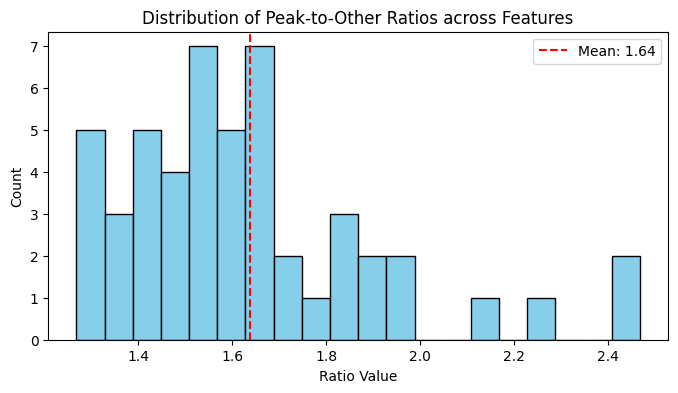

Epoch: 1, Loss: 60.932301, LR: 0.010000
Epoch: 2, Loss: 56.111420, LR: 0.010000
Epoch: 3, Loss: 52.039471, LR: 0.010000
Epoch: 4, Loss: 48.578808, LR: 0.010000
Epoch: 5, Loss: 45.644070, LR: 0.010000
Epoch: 6, Loss: 43.169331, LR: 0.010000
Epoch: 7, Loss: 41.076492, LR: 0.010000
Epoch: 8, Loss: 39.283627, LR: 0.010000
Epoch: 9, Loss: 37.730717, LR: 0.010000
Epoch: 10, Loss: 36.364391, LR: 0.010000
Epoch: 11, Loss: 35.140842, LR: 0.010000
Epoch: 12, Loss: 34.042599, LR: 0.010000
Epoch: 13, Loss: 33.054832, LR: 0.010000
Epoch: 14, Loss: 32.163208, LR: 0.010000
Epoch: 15, Loss: 31.349636, LR: 0.010000
Epoch: 16, Loss: 30.594166, LR: 0.010000
Epoch: 17, Loss: 29.885326, LR: 0.010000
Epoch: 18, Loss: 29.215956, LR: 0.010000
Epoch: 19, Loss: 28.582212, LR: 0.010000
Epoch: 20, Loss: 27.984713, LR: 0.010000
Epoch: 21, Loss: 27.425840, LR: 0.010000
Epoch: 22, Loss: 26.905453, LR: 0.010000
Epoch: 23, Loss: 26.419750, LR: 0.010000
Epoch: 24, Loss: 25.966951, LR: 0.010000
Epoch: 25, Loss: 25.54844

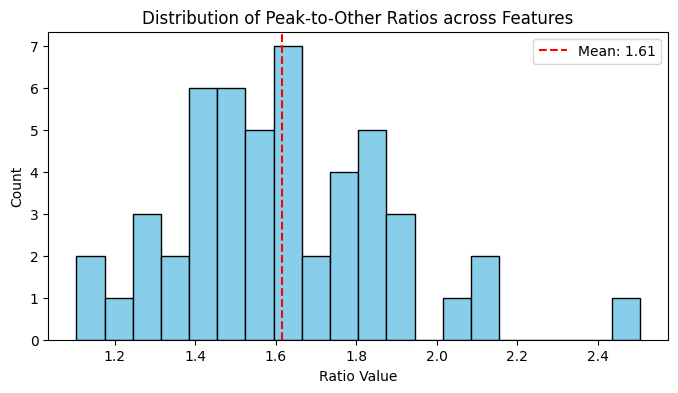

Epoch: 1, Loss: 55.817036, LR: 0.010000
Epoch: 2, Loss: 51.953896, LR: 0.010000
Epoch: 3, Loss: 48.776894, LR: 0.010000
Epoch: 4, Loss: 46.056194, LR: 0.010000
Epoch: 5, Loss: 43.655197, LR: 0.010000
Epoch: 6, Loss: 41.542355, LR: 0.010000
Epoch: 7, Loss: 39.695660, LR: 0.010000
Epoch: 8, Loss: 38.076168, LR: 0.010000
Epoch: 9, Loss: 36.652817, LR: 0.010000
Epoch: 10, Loss: 35.402885, LR: 0.010000
Epoch: 11, Loss: 34.299397, LR: 0.010000
Epoch: 12, Loss: 33.311096, LR: 0.010000
Epoch: 13, Loss: 32.413074, LR: 0.010000
Epoch: 14, Loss: 31.588100, LR: 0.010000
Epoch: 15, Loss: 30.818769, LR: 0.010000
Epoch: 16, Loss: 30.091064, LR: 0.010000
Epoch: 17, Loss: 29.404232, LR: 0.010000
Epoch: 18, Loss: 28.769455, LR: 0.010000
Epoch: 19, Loss: 28.199896, LR: 0.010000
Epoch: 20, Loss: 27.705257, LR: 0.010000
Epoch: 21, Loss: 27.290436, LR: 0.010000
Epoch: 22, Loss: 26.942610, LR: 0.010000
Epoch: 23, Loss: 26.639709, LR: 0.010000
Epoch: 24, Loss: 26.364763, LR: 0.010000
Epoch: 25, Loss: 26.10415

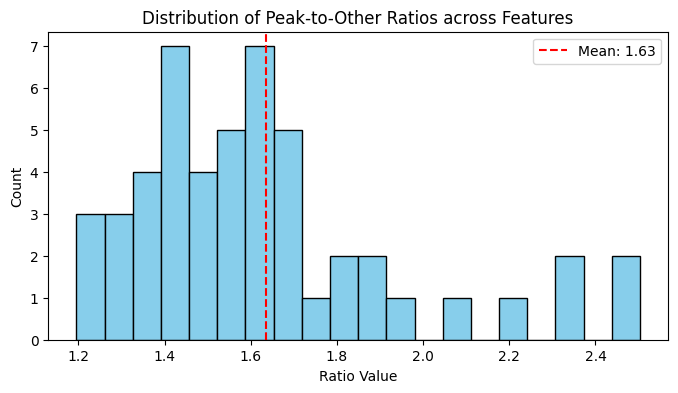

Epoch: 1, Loss: 58.805260, LR: 0.010000
Epoch: 2, Loss: 54.471653, LR: 0.010000
Epoch: 3, Loss: 50.786617, LR: 0.010000
Epoch: 4, Loss: 47.689041, LR: 0.010000
Epoch: 5, Loss: 45.065845, LR: 0.010000
Epoch: 6, Loss: 42.818760, LR: 0.010000
Epoch: 7, Loss: 40.871658, LR: 0.010000
Epoch: 8, Loss: 39.166515, LR: 0.010000
Epoch: 9, Loss: 37.666809, LR: 0.010000
Epoch: 10, Loss: 36.336540, LR: 0.010000
Epoch: 11, Loss: 35.146912, LR: 0.010000
Epoch: 12, Loss: 34.073177, LR: 0.010000
Epoch: 13, Loss: 33.101761, LR: 0.010000
Epoch: 14, Loss: 32.217663, LR: 0.010000
Epoch: 15, Loss: 31.402569, LR: 0.010000
Epoch: 16, Loss: 30.648157, LR: 0.010000
Epoch: 17, Loss: 29.944727, LR: 0.010000
Epoch: 18, Loss: 29.287222, LR: 0.010000
Epoch: 19, Loss: 28.673149, LR: 0.010000
Epoch: 20, Loss: 28.095377, LR: 0.010000
Epoch: 21, Loss: 27.559870, LR: 0.010000
Epoch: 22, Loss: 27.075121, LR: 0.010000
Epoch: 23, Loss: 26.639717, LR: 0.010000
Epoch: 24, Loss: 26.250330, LR: 0.010000
Epoch: 25, Loss: 25.90232

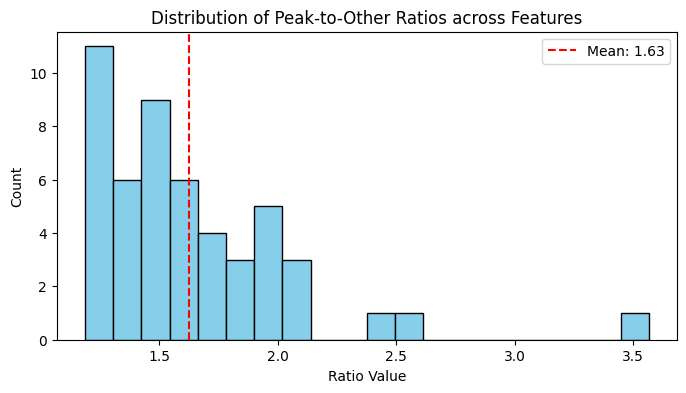


--- Testing Factor: 2 ---
Epoch: 1, Loss: 102.724930, LR: 0.010000
Epoch: 2, Loss: 93.224312, LR: 0.010000
Epoch: 3, Loss: 85.334122, LR: 0.010000
Epoch: 4, Loss: 78.851547, LR: 0.010000
Epoch: 5, Loss: 73.547440, LR: 0.010000
Epoch: 6, Loss: 69.223381, LR: 0.010000
Epoch: 7, Loss: 65.719894, LR: 0.010000
Epoch: 8, Loss: 62.901520, LR: 0.010000
Epoch: 9, Loss: 60.645065, LR: 0.010000
Epoch: 10, Loss: 58.840992, LR: 0.010000
Epoch: 11, Loss: 57.397938, LR: 0.010000
Epoch: 12, Loss: 56.239864, LR: 0.010000
Epoch: 13, Loss: 55.303764, LR: 0.010000
Epoch: 14, Loss: 54.536858, LR: 0.010000
Epoch: 15, Loss: 53.896080, LR: 0.010000
Epoch: 16, Loss: 53.346832, LR: 0.010000
Epoch: 17, Loss: 52.861229, LR: 0.010000
Epoch: 18, Loss: 52.416981, LR: 0.010000
Epoch: 19, Loss: 51.996513, LR: 0.010000
Epoch: 20, Loss: 51.586140, LR: 0.010000
Epoch: 21, Loss: 51.175541, LR: 0.010000
Epoch: 22, Loss: 50.756927, LR: 0.010000
Epoch: 23, Loss: 50.324120, LR: 0.010000
Epoch: 24, Loss: 49.872593, LR: 0.0100

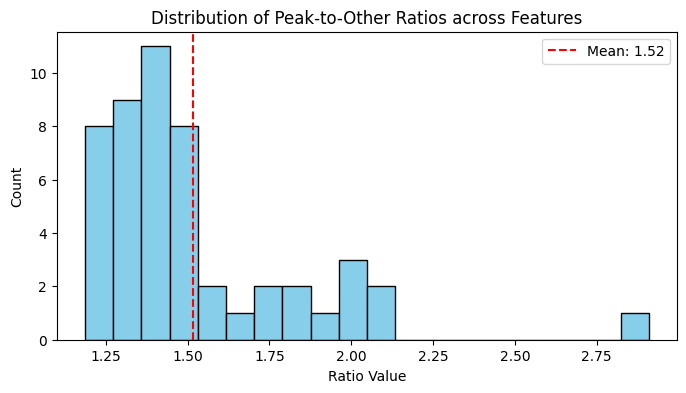

Epoch: 1, Loss: 95.703278, LR: 0.010000
Epoch: 2, Loss: 86.670074, LR: 0.010000
Epoch: 3, Loss: 79.305977, LR: 0.010000
Epoch: 4, Loss: 73.309357, LR: 0.010000
Epoch: 5, Loss: 68.505890, LR: 0.010000
Epoch: 6, Loss: 64.700249, LR: 0.010000
Epoch: 7, Loss: 61.697468, LR: 0.010000
Epoch: 8, Loss: 59.320698, LR: 0.010000
Epoch: 9, Loss: 57.426903, LR: 0.010000
Epoch: 10, Loss: 55.901588, LR: 0.010000
Epoch: 11, Loss: 54.650986, LR: 0.010000
Epoch: 12, Loss: 53.601158, LR: 0.010000
Epoch: 13, Loss: 52.702717, LR: 0.010000
Epoch: 14, Loss: 51.923149, LR: 0.010000
Epoch: 15, Loss: 51.237934, LR: 0.010000
Epoch: 16, Loss: 50.626595, LR: 0.010000
Epoch: 17, Loss: 50.070866, LR: 0.010000
Epoch: 18, Loss: 49.555283, LR: 0.010000
Epoch: 19, Loss: 49.067623, LR: 0.010000
Epoch: 20, Loss: 48.599838, LR: 0.010000
Epoch: 21, Loss: 48.148575, LR: 0.010000
Epoch: 22, Loss: 47.713493, LR: 0.010000
Epoch: 23, Loss: 47.294865, LR: 0.010000
Epoch: 24, Loss: 46.892395, LR: 0.010000
Epoch: 25, Loss: 46.50483

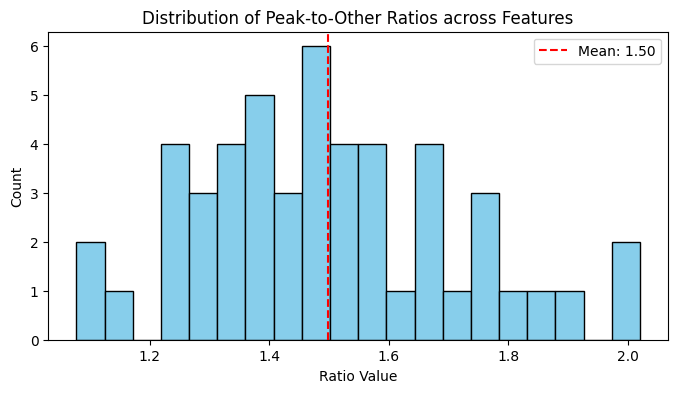

Epoch: 1, Loss: 101.586418, LR: 0.010000
Epoch: 2, Loss: 91.936729, LR: 0.010000
Epoch: 3, Loss: 83.924561, LR: 0.010000
Epoch: 4, Loss: 77.355751, LR: 0.010000
Epoch: 5, Loss: 72.002632, LR: 0.010000
Epoch: 6, Loss: 67.674606, LR: 0.010000
Epoch: 7, Loss: 64.195068, LR: 0.010000
Epoch: 8, Loss: 61.408661, LR: 0.010000
Epoch: 9, Loss: 59.191967, LR: 0.010000
Epoch: 10, Loss: 57.440674, LR: 0.010000
Epoch: 11, Loss: 56.060764, LR: 0.010000
Epoch: 12, Loss: 54.967613, LR: 0.010000
Epoch: 13, Loss: 54.092033, LR: 0.010000
Epoch: 14, Loss: 53.379745, LR: 0.010000
Epoch: 15, Loss: 52.787685, LR: 0.010000
Epoch: 16, Loss: 52.282143, LR: 0.010000
Epoch: 17, Loss: 51.837505, LR: 0.010000
Epoch: 18, Loss: 51.434330, LR: 0.010000
Epoch: 19, Loss: 51.056332, LR: 0.010000
Epoch: 20, Loss: 50.688759, LR: 0.010000
Epoch: 21, Loss: 50.318867, LR: 0.010000
Epoch: 22, Loss: 49.936394, LR: 0.010000
Epoch: 23, Loss: 49.533081, LR: 0.010000
Epoch: 24, Loss: 49.102989, LR: 0.010000
Epoch: 25, Loss: 48.6436

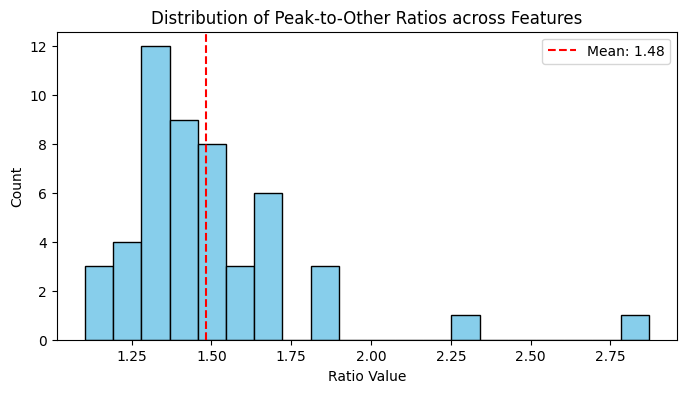

Epoch: 1, Loss: 107.238220, LR: 0.010000
Epoch: 2, Loss: 97.494507, LR: 0.010000
Epoch: 3, Loss: 89.265526, LR: 0.010000
Epoch: 4, Loss: 82.393608, LR: 0.010000
Epoch: 5, Loss: 76.690269, LR: 0.010000
Epoch: 6, Loss: 71.982391, LR: 0.010000
Epoch: 7, Loss: 68.123177, LR: 0.010000
Epoch: 8, Loss: 64.981949, LR: 0.010000
Epoch: 9, Loss: 62.438148, LR: 0.010000
Epoch: 10, Loss: 60.383938, LR: 0.010000
Epoch: 11, Loss: 58.726654, LR: 0.010000
Epoch: 12, Loss: 57.388699, LR: 0.010000
Epoch: 13, Loss: 56.304005, LR: 0.010000
Epoch: 14, Loss: 55.416264, LR: 0.010000
Epoch: 15, Loss: 54.677914, LR: 0.010000
Epoch: 16, Loss: 54.047997, LR: 0.010000
Epoch: 17, Loss: 53.491112, LR: 0.010000
Epoch: 18, Loss: 52.977665, LR: 0.010000
Epoch: 19, Loss: 52.484833, LR: 0.010000
Epoch: 20, Loss: 51.997604, LR: 0.010000
Epoch: 21, Loss: 51.507626, LR: 0.010000
Epoch: 22, Loss: 51.011395, LR: 0.010000
Epoch: 23, Loss: 50.508694, LR: 0.010000
Epoch: 24, Loss: 50.001324, LR: 0.010000
Epoch: 25, Loss: 49.4922

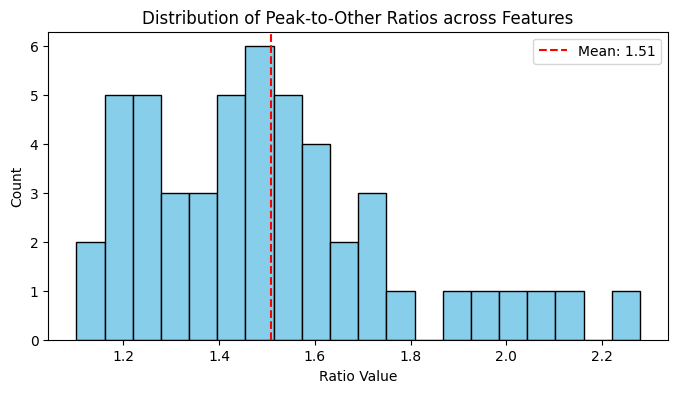

Epoch: 1, Loss: 97.736847, LR: 0.010000
Epoch: 2, Loss: 88.747536, LR: 0.010000
Epoch: 3, Loss: 81.287300, LR: 0.010000
Epoch: 4, Loss: 75.178696, LR: 0.010000
Epoch: 5, Loss: 70.170601, LR: 0.010000
Epoch: 6, Loss: 66.078178, LR: 0.010000
Epoch: 7, Loss: 62.760521, LR: 0.010000
Epoch: 8, Loss: 60.086479, LR: 0.010000
Epoch: 9, Loss: 57.942429, LR: 0.010000
Epoch: 10, Loss: 56.230095, LR: 0.010000
Epoch: 11, Loss: 54.866554, LR: 0.010000
Epoch: 12, Loss: 53.781830, LR: 0.010000
Epoch: 13, Loss: 52.914139, LR: 0.010000
Epoch: 14, Loss: 52.207954, LR: 0.010000
Epoch: 15, Loss: 51.616463, LR: 0.010000
Epoch: 16, Loss: 51.102432, LR: 0.010000
Epoch: 17, Loss: 50.637882, LR: 0.010000
Epoch: 18, Loss: 50.202610, LR: 0.010000
Epoch: 19, Loss: 49.783108, LR: 0.010000
Epoch: 20, Loss: 49.371593, LR: 0.010000
Epoch: 21, Loss: 48.964336, LR: 0.010000
Epoch: 22, Loss: 48.559414, LR: 0.010000
Epoch: 23, Loss: 48.155556, LR: 0.010000
Epoch: 24, Loss: 47.751812, LR: 0.010000
Epoch: 25, Loss: 47.34724

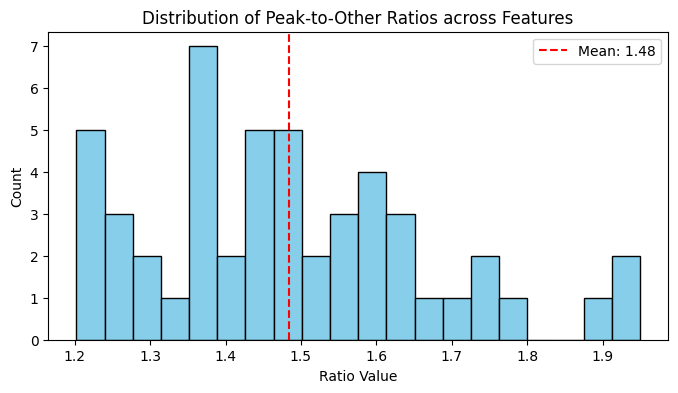

Epoch: 1, Loss: 92.084480, LR: 0.010000
Epoch: 2, Loss: 83.291534, LR: 0.010000
Epoch: 3, Loss: 76.012283, LR: 0.010000
Epoch: 4, Loss: 70.006386, LR: 0.010000
Epoch: 5, Loss: 65.108597, LR: 0.010000
Epoch: 6, Loss: 61.155018, LR: 0.010000
Epoch: 7, Loss: 58.003262, LR: 0.010000
Epoch: 8, Loss: 55.524628, LR: 0.010000
Epoch: 9, Loss: 53.598137, LR: 0.010000
Epoch: 10, Loss: 52.124889, LR: 0.010000
Epoch: 11, Loss: 51.020378, LR: 0.010000
Epoch: 12, Loss: 50.206112, LR: 0.010000
Epoch: 13, Loss: 49.615063, LR: 0.010000
Epoch: 14, Loss: 49.190708, LR: 0.010000
Epoch: 15, Loss: 48.886215, LR: 0.010000
Epoch: 16, Loss: 48.661934, LR: 0.010000
Epoch: 17, Loss: 48.485771, LR: 0.010000
Epoch: 18, Loss: 48.333954, LR: 0.010000
Epoch: 19, Loss: 48.189320, LR: 0.010000
Epoch: 20, Loss: 48.039658, LR: 0.010000
Epoch: 21, Loss: 47.876286, LR: 0.010000
Epoch: 22, Loss: 47.693226, LR: 0.010000
Epoch: 23, Loss: 47.486820, LR: 0.010000
Epoch: 24, Loss: 47.254620, LR: 0.010000
Epoch: 25, Loss: 46.99472

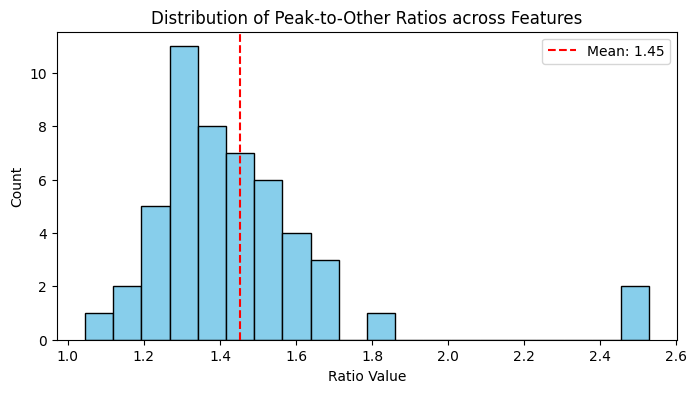

Epoch: 1, Loss: 97.923981, LR: 0.010000
Epoch: 2, Loss: 88.639137, LR: 0.010000
Epoch: 3, Loss: 80.949104, LR: 0.010000
Epoch: 4, Loss: 74.693016, LR: 0.010000
Epoch: 5, Loss: 69.682388, LR: 0.010000
Epoch: 6, Loss: 65.717216, LR: 0.010000
Epoch: 7, Loss: 62.610600, LR: 0.010000
Epoch: 8, Loss: 60.199364, LR: 0.010000
Epoch: 9, Loss: 58.344131, LR: 0.010000
Epoch: 10, Loss: 56.926991, LR: 0.010000
Epoch: 11, Loss: 55.845425, LR: 0.010000
Epoch: 12, Loss: 55.011517, LR: 0.010000
Epoch: 13, Loss: 54.353310, LR: 0.010000
Epoch: 14, Loss: 53.813171, LR: 0.010000
Epoch: 15, Loss: 53.344948, LR: 0.010000
Epoch: 16, Loss: 52.912388, LR: 0.010000
Epoch: 17, Loss: 52.487553, LR: 0.010000
Epoch: 18, Loss: 52.050842, LR: 0.010000
Epoch: 19, Loss: 51.590435, LR: 0.010000
Epoch: 20, Loss: 51.100361, LR: 0.010000
Epoch: 21, Loss: 50.579342, LR: 0.010000
Epoch: 22, Loss: 50.029350, LR: 0.010000
Epoch: 23, Loss: 49.454208, LR: 0.010000
Epoch: 24, Loss: 48.859196, LR: 0.010000
Epoch: 25, Loss: 48.25060

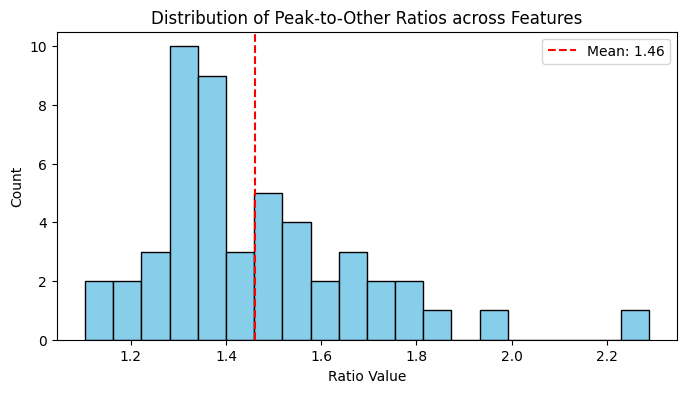

Epoch: 1, Loss: 98.582848, LR: 0.010000
Epoch: 2, Loss: 89.427605, LR: 0.010000
Epoch: 3, Loss: 81.842316, LR: 0.010000
Epoch: 4, Loss: 75.626930, LR: 0.010000
Epoch: 5, Loss: 70.563385, LR: 0.010000
Epoch: 6, Loss: 66.454041, LR: 0.010000
Epoch: 7, Loss: 63.142651, LR: 0.010000
Epoch: 8, Loss: 60.506218, LR: 0.010000
Epoch: 9, Loss: 58.426960, LR: 0.010000
Epoch: 10, Loss: 56.797329, LR: 0.010000
Epoch: 11, Loss: 55.522800, LR: 0.010000
Epoch: 12, Loss: 54.521557, LR: 0.010000
Epoch: 13, Loss: 53.728848, LR: 0.010000
Epoch: 14, Loss: 53.097187, LR: 0.010000
Epoch: 15, Loss: 52.591240, LR: 0.010000
Epoch: 16, Loss: 52.182114, LR: 0.010000
Epoch: 17, Loss: 51.844830, LR: 0.010000
Epoch: 18, Loss: 51.558784, LR: 0.010000
Epoch: 19, Loss: 51.307907, LR: 0.010000
Epoch: 20, Loss: 51.078594, LR: 0.010000
Epoch: 21, Loss: 50.857765, LR: 0.010000
Epoch: 22, Loss: 50.632397, LR: 0.010000
Epoch: 23, Loss: 50.390972, LR: 0.010000
Epoch: 24, Loss: 50.123989, LR: 0.010000
Epoch: 25, Loss: 49.82329

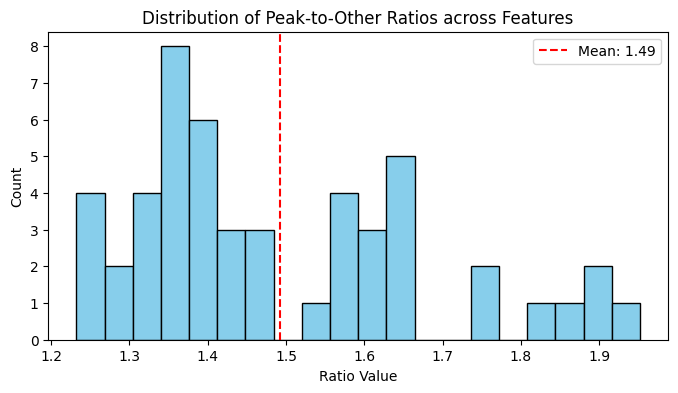

Epoch: 1, Loss: 107.032707, LR: 0.010000
Epoch: 2, Loss: 96.902199, LR: 0.010000
Epoch: 3, Loss: 88.500244, LR: 0.010000
Epoch: 4, Loss: 81.584190, LR: 0.010000
Epoch: 5, Loss: 75.910126, LR: 0.010000
Epoch: 6, Loss: 71.271912, LR: 0.010000
Epoch: 7, Loss: 67.498055, LR: 0.010000
Epoch: 8, Loss: 64.444016, LR: 0.010000
Epoch: 9, Loss: 61.987919, LR: 0.010000
Epoch: 10, Loss: 60.028633, LR: 0.010000
Epoch: 11, Loss: 58.477028, LR: 0.010000
Epoch: 12, Loss: 57.255730, LR: 0.010000
Epoch: 13, Loss: 56.298275, LR: 0.010000
Epoch: 14, Loss: 55.547642, LR: 0.010000
Epoch: 15, Loss: 54.953571, LR: 0.010000
Epoch: 16, Loss: 54.471722, LR: 0.010000
Epoch: 17, Loss: 54.064373, LR: 0.010000
Epoch: 18, Loss: 53.701916, LR: 0.010000
Epoch: 19, Loss: 53.362305, LR: 0.010000
Epoch: 20, Loss: 53.029190, LR: 0.010000
Epoch: 21, Loss: 52.690483, LR: 0.010000
Epoch: 22, Loss: 52.337162, LR: 0.010000
Epoch: 23, Loss: 51.962200, LR: 0.010000
Epoch: 24, Loss: 51.560299, LR: 0.010000
Epoch: 25, Loss: 51.1279

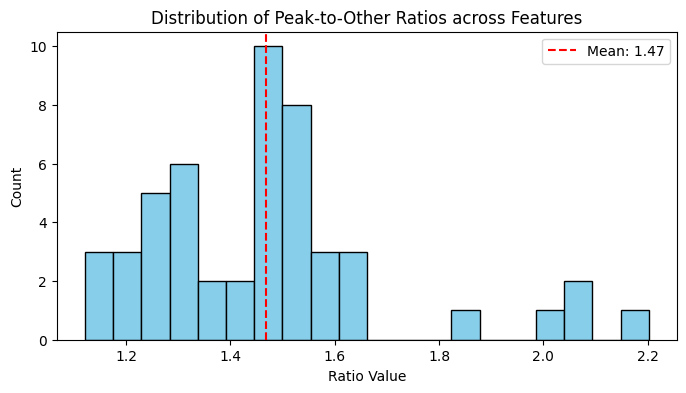

Epoch: 1, Loss: 97.805191, LR: 0.010000
Epoch: 2, Loss: 88.585846, LR: 0.010000
Epoch: 3, Loss: 80.890938, LR: 0.010000
Epoch: 4, Loss: 74.526123, LR: 0.010000
Epoch: 5, Loss: 69.331032, LR: 0.010000
Epoch: 6, Loss: 65.128532, LR: 0.010000
Epoch: 7, Loss: 61.745770, LR: 0.010000
Epoch: 8, Loss: 59.023342, LR: 0.010000
Epoch: 9, Loss: 56.825085, LR: 0.010000
Epoch: 10, Loss: 55.047878, LR: 0.010000
Epoch: 11, Loss: 53.612865, LR: 0.010000
Epoch: 12, Loss: 52.453068, LR: 0.010000
Epoch: 13, Loss: 51.509388, LR: 0.010000
Epoch: 14, Loss: 50.733353, LR: 0.010000
Epoch: 15, Loss: 50.086777, LR: 0.010000
Epoch: 16, Loss: 49.539215, LR: 0.010000
Epoch: 17, Loss: 49.067406, LR: 0.010000
Epoch: 18, Loss: 48.654415, LR: 0.010000
Epoch: 19, Loss: 48.288559, LR: 0.010000
Epoch: 20, Loss: 47.961781, LR: 0.010000
Epoch: 21, Loss: 47.667564, LR: 0.010000
Epoch: 22, Loss: 47.399902, LR: 0.010000
Epoch: 23, Loss: 47.151932, LR: 0.010000
Epoch: 24, Loss: 46.914543, LR: 0.010000
Epoch: 25, Loss: 46.67737

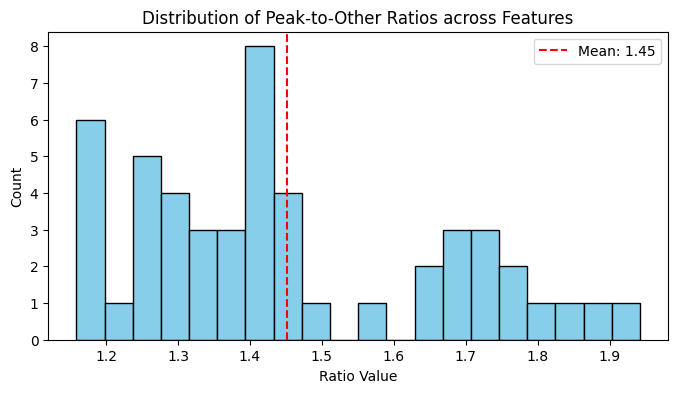


--- Testing Factor: 3 ---
Epoch: 1, Loss: 128.524216, LR: 0.010000
Epoch: 2, Loss: 114.601784, LR: 0.010000
Epoch: 3, Loss: 103.599419, LR: 0.010000
Epoch: 4, Loss: 95.028343, LR: 0.010000
Epoch: 5, Loss: 88.497162, LR: 0.010000
Epoch: 6, Loss: 83.634361, LR: 0.010000
Epoch: 7, Loss: 80.088577, LR: 0.010000
Epoch: 8, Loss: 77.540428, LR: 0.010000
Epoch: 9, Loss: 75.727859, LR: 0.010000
Epoch: 10, Loss: 74.438660, LR: 0.010000
Epoch: 11, Loss: 73.504631, LR: 0.010000
Epoch: 12, Loss: 72.803505, LR: 0.010000
Epoch: 13, Loss: 72.250504, LR: 0.010000
Epoch: 14, Loss: 71.787033, LR: 0.010000
Epoch: 15, Loss: 71.371529, LR: 0.010000
Epoch: 16, Loss: 70.973412, LR: 0.010000
Epoch: 17, Loss: 70.568283, LR: 0.010000
Epoch: 18, Loss: 70.135406, LR: 0.010000
Epoch: 19, Loss: 69.657990, LR: 0.010000
Epoch: 20, Loss: 69.124001, LR: 0.010000
Epoch: 21, Loss: 68.526543, LR: 0.010000
Epoch: 22, Loss: 67.862755, LR: 0.010000
Epoch: 23, Loss: 67.132980, LR: 0.010000
Epoch: 24, Loss: 66.340614, LR: 0.01

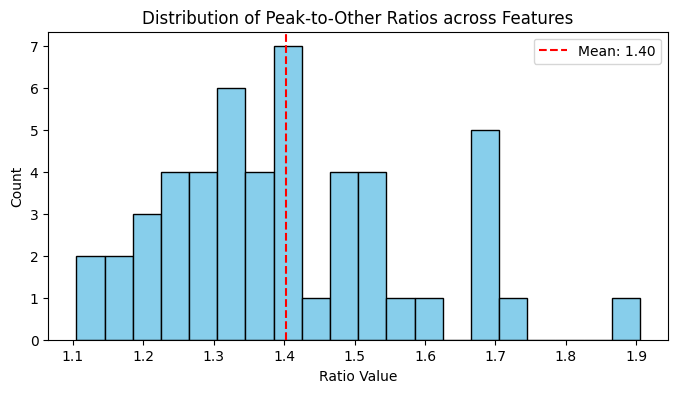

Epoch: 1, Loss: 131.217499, LR: 0.010000
Epoch: 2, Loss: 118.418488, LR: 0.010000
Epoch: 3, Loss: 108.274918, LR: 0.010000
Epoch: 4, Loss: 100.319679, LR: 0.010000
Epoch: 5, Loss: 94.202873, LR: 0.010000
Epoch: 6, Loss: 89.597595, LR: 0.010000
Epoch: 7, Loss: 86.214439, LR: 0.010000
Epoch: 8, Loss: 83.790894, LR: 0.010000
Epoch: 9, Loss: 82.087906, LR: 0.010000
Epoch: 10, Loss: 80.898254, LR: 0.010000
Epoch: 11, Loss: 80.061386, LR: 0.010000
Epoch: 12, Loss: 79.456665, LR: 0.010000
Epoch: 13, Loss: 78.995003, LR: 0.010000
Epoch: 14, Loss: 78.608276, LR: 0.010000
Epoch: 15, Loss: 78.243019, LR: 0.010000
Epoch: 16, Loss: 77.859016, LR: 0.010000
Epoch: 17, Loss: 77.428024, LR: 0.010000
Epoch: 18, Loss: 76.931541, LR: 0.010000
Epoch: 19, Loss: 76.358627, LR: 0.010000
Epoch: 20, Loss: 75.704262, LR: 0.010000
Epoch: 21, Loss: 74.967888, LR: 0.010000
Epoch: 22, Loss: 74.152107, LR: 0.010000
Epoch: 23, Loss: 73.261948, LR: 0.010000
Epoch: 24, Loss: 72.303978, LR: 0.010000
Epoch: 25, Loss: 71.2

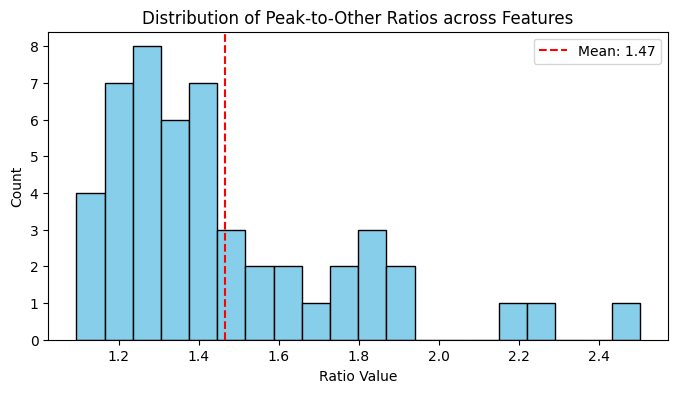

Epoch: 1, Loss: 121.291687, LR: 0.010000
Epoch: 2, Loss: 109.621544, LR: 0.010000
Epoch: 3, Loss: 100.306076, LR: 0.010000
Epoch: 4, Loss: 93.025337, LR: 0.010000
Epoch: 5, Loss: 87.500122, LR: 0.010000
Epoch: 6, Loss: 83.418022, LR: 0.010000
Epoch: 7, Loss: 80.495056, LR: 0.010000
Epoch: 8, Loss: 78.482796, LR: 0.010000
Epoch: 9, Loss: 77.159821, LR: 0.010000
Epoch: 10, Loss: 76.339813, LR: 0.010000
Epoch: 11, Loss: 75.866714, LR: 0.010000
Epoch: 12, Loss: 75.612770, LR: 0.010000
Epoch: 13, Loss: 75.475121, LR: 0.010000
Epoch: 14, Loss: 75.373711, LR: 0.010000
Epoch: 15, Loss: 75.248657, LR: 0.010000
Epoch: 16, Loss: 75.057899, LR: 0.010000
Epoch: 17, Loss: 74.773949, LR: 0.010000
Epoch: 18, Loss: 74.380852, LR: 0.010000
Epoch: 19, Loss: 73.872635, LR: 0.010000
Epoch: 20, Loss: 73.250763, LR: 0.010000
Epoch: 21, Loss: 72.520836, LR: 0.010000
Epoch: 22, Loss: 71.690498, LR: 0.010000
Epoch: 23, Loss: 70.770218, LR: 0.010000
Epoch: 24, Loss: 69.774490, LR: 0.010000
Epoch: 25, Loss: 68.71

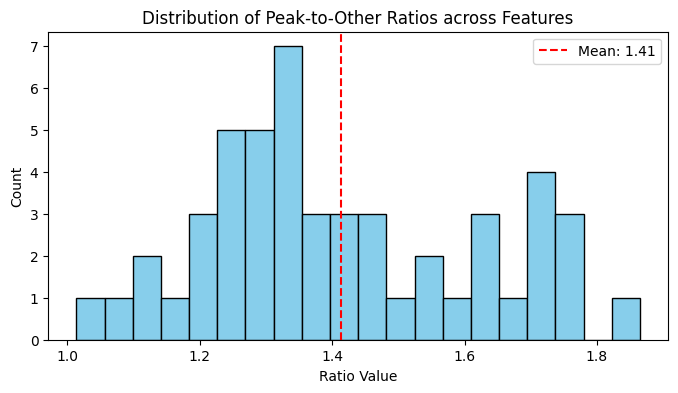

Epoch: 1, Loss: 126.009460, LR: 0.010000
Epoch: 2, Loss: 114.284599, LR: 0.010000
Epoch: 3, Loss: 104.759636, LR: 0.010000
Epoch: 4, Loss: 97.212456, LR: 0.010000
Epoch: 5, Loss: 91.392769, LR: 0.010000
Epoch: 6, Loss: 87.033821, LR: 0.010000
Epoch: 7, Loss: 83.853905, LR: 0.010000
Epoch: 8, Loss: 81.595726, LR: 0.010000
Epoch: 9, Loss: 80.044586, LR: 0.010000
Epoch: 10, Loss: 79.020676, LR: 0.010000
Epoch: 11, Loss: 78.365555, LR: 0.010000
Epoch: 12, Loss: 77.944160, LR: 0.010000
Epoch: 13, Loss: 77.648399, LR: 0.010000
Epoch: 14, Loss: 77.396652, LR: 0.010000
Epoch: 15, Loss: 77.130478, LR: 0.010000
Epoch: 16, Loss: 76.810997, LR: 0.010000
Epoch: 17, Loss: 76.413483, LR: 0.010000
Epoch: 18, Loss: 75.921280, LR: 0.010000
Epoch: 19, Loss: 75.322075, LR: 0.010000
Epoch: 20, Loss: 74.608368, LR: 0.010000
Epoch: 21, Loss: 73.780266, LR: 0.010000
Epoch: 22, Loss: 72.845345, LR: 0.010000
Epoch: 23, Loss: 71.816330, LR: 0.010000
Epoch: 24, Loss: 70.708549, LR: 0.010000
Epoch: 25, Loss: 69.53

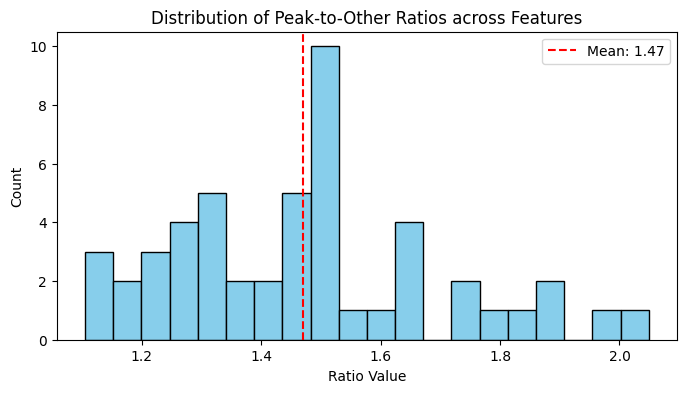

Epoch: 1, Loss: 116.817268, LR: 0.010000
Epoch: 2, Loss: 104.883606, LR: 0.010000
Epoch: 3, Loss: 95.387085, LR: 0.010000
Epoch: 4, Loss: 87.979332, LR: 0.010000
Epoch: 5, Loss: 82.349182, LR: 0.010000
Epoch: 6, Loss: 78.206779, LR: 0.010000
Epoch: 7, Loss: 75.278625, LR: 0.010000
Epoch: 8, Loss: 73.299149, LR: 0.010000
Epoch: 9, Loss: 72.031677, LR: 0.010000
Epoch: 10, Loss: 71.283600, LR: 0.010000
Epoch: 11, Loss: 70.897964, LR: 0.010000
Epoch: 12, Loss: 70.744637, LR: 0.010000
Epoch: 13, Loss: 70.716751, LR: 0.010000
Epoch: 14, Loss: 70.730225, LR: 0.010000
Epoch: 15, Loss: 70.722206, LR: 0.010000
Epoch: 16, Loss: 70.649223, LR: 0.010000
Epoch: 17, Loss: 70.484932, LR: 0.010000
Epoch: 18, Loss: 70.217285, LR: 0.010000
Epoch: 19, Loss: 69.844688, LR: 0.010000
Epoch: 20, Loss: 69.371796, LR: 0.010000
Epoch: 21, Loss: 68.806412, LR: 0.010000
Epoch: 22, Loss: 68.157616, LR: 0.010000
Epoch: 23, Loss: 67.434540, LR: 0.010000
Epoch: 24, Loss: 66.646156, LR: 0.010000
Epoch: 25, Loss: 65.801

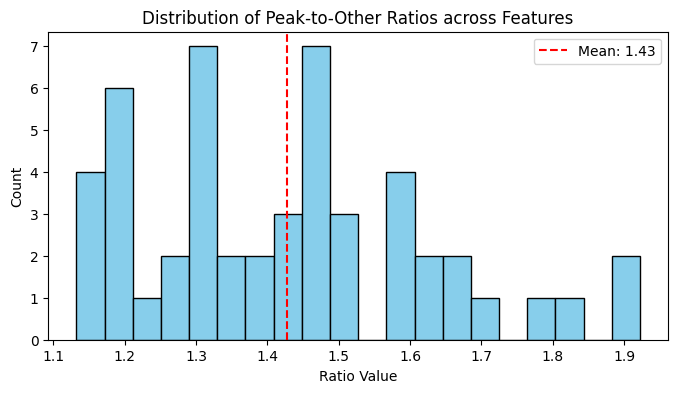

Epoch: 1, Loss: 128.848495, LR: 0.010000
Epoch: 2, Loss: 116.658035, LR: 0.010000
Epoch: 3, Loss: 107.085640, LR: 0.010000
Epoch: 4, Loss: 99.655899, LR: 0.010000
Epoch: 5, Loss: 94.021744, LR: 0.010000
Epoch: 6, Loss: 89.873116, LR: 0.010000
Epoch: 7, Loss: 86.916389, LR: 0.010000
Epoch: 8, Loss: 84.866676, LR: 0.010000
Epoch: 9, Loss: 83.475937, LR: 0.010000
Epoch: 10, Loss: 82.541260, LR: 0.010000
Epoch: 11, Loss: 81.895317, LR: 0.010000
Epoch: 12, Loss: 81.410027, LR: 0.010000
Epoch: 13, Loss: 80.997498, LR: 0.010000
Epoch: 14, Loss: 80.598946, LR: 0.010000
Epoch: 15, Loss: 80.170990, LR: 0.010000
Epoch: 16, Loss: 79.680893, LR: 0.010000
Epoch: 17, Loss: 79.107582, LR: 0.010000
Epoch: 18, Loss: 78.441986, LR: 0.010000
Epoch: 19, Loss: 77.686150, LR: 0.010000
Epoch: 20, Loss: 76.849777, LR: 0.010000
Epoch: 21, Loss: 75.946312, LR: 0.010000
Epoch: 22, Loss: 74.990051, LR: 0.010000
Epoch: 23, Loss: 73.993774, LR: 0.010000
Epoch: 24, Loss: 72.967621, LR: 0.010000
Epoch: 25, Loss: 71.91

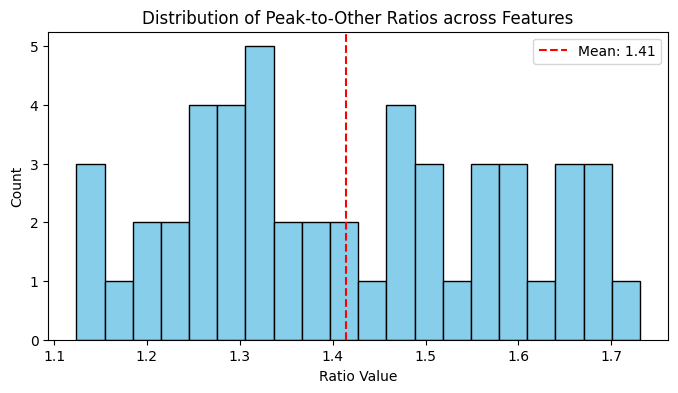

Epoch: 1, Loss: 112.792480, LR: 0.010000
Epoch: 2, Loss: 101.269997, LR: 0.010000
Epoch: 3, Loss: 92.225708, LR: 0.010000
Epoch: 4, Loss: 85.229347, LR: 0.010000
Epoch: 5, Loss: 79.952766, LR: 0.010000
Epoch: 6, Loss: 76.072586, LR: 0.010000
Epoch: 7, Loss: 73.286736, LR: 0.010000
Epoch: 8, Loss: 71.339828, LR: 0.010000
Epoch: 9, Loss: 70.033272, LR: 0.010000
Epoch: 10, Loss: 69.201569, LR: 0.010000
Epoch: 11, Loss: 68.713020, LR: 0.010000
Epoch: 12, Loss: 68.459625, LR: 0.010000
Epoch: 13, Loss: 68.354286, LR: 0.010000
Epoch: 14, Loss: 68.328522, LR: 0.010000
Epoch: 15, Loss: 68.329185, LR: 0.010000
Epoch: 16, Loss: 68.316223, LR: 0.010000
Epoch: 17, Loss: 68.260956, LR: 0.010000
Epoch: 18, Loss: 68.144493, LR: 0.010000
Epoch: 19, Loss: 67.955666, LR: 0.010000
Epoch: 20, Loss: 67.689186, LR: 0.010000
Epoch: 21, Loss: 67.344086, LR: 0.010000
Epoch: 22, Loss: 66.922256, LR: 0.010000
Epoch: 23, Loss: 66.427498, LR: 0.010000
Epoch: 24, Loss: 65.865044, LR: 0.010000
Epoch: 25, Loss: 65.241

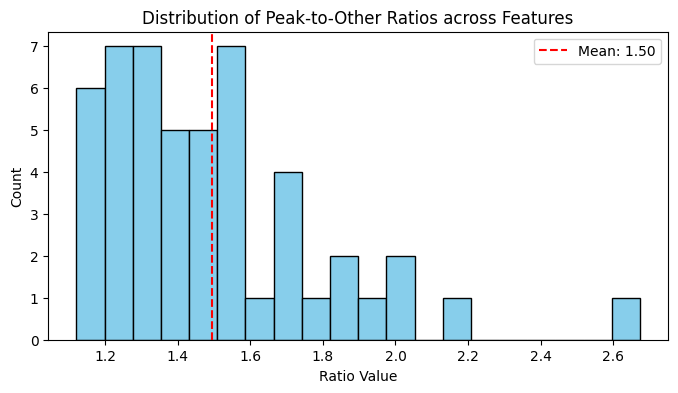

Epoch: 1, Loss: 129.928055, LR: 0.010000
Epoch: 2, Loss: 116.420753, LR: 0.010000
Epoch: 3, Loss: 105.514000, LR: 0.010000
Epoch: 4, Loss: 96.881966, LR: 0.010000
Epoch: 5, Loss: 90.136070, LR: 0.010000
Epoch: 6, Loss: 84.949265, LR: 0.010000
Epoch: 7, Loss: 81.034203, LR: 0.010000
Epoch: 8, Loss: 78.137070, LR: 0.010000
Epoch: 9, Loss: 76.032761, LR: 0.010000
Epoch: 10, Loss: 74.533707, LR: 0.010000
Epoch: 11, Loss: 73.486404, LR: 0.010000
Epoch: 12, Loss: 72.758995, LR: 0.010000
Epoch: 13, Loss: 72.242218, LR: 0.010000
Epoch: 14, Loss: 71.852028, LR: 0.010000
Epoch: 15, Loss: 71.526443, LR: 0.010000
Epoch: 16, Loss: 71.218933, LR: 0.010000
Epoch: 17, Loss: 70.893501, LR: 0.010000
Epoch: 18, Loss: 70.523865, LR: 0.010000
Epoch: 19, Loss: 70.093498, LR: 0.010000
Epoch: 20, Loss: 69.594444, LR: 0.010000
Epoch: 21, Loss: 69.024437, LR: 0.010000
Epoch: 22, Loss: 68.384743, LR: 0.010000
Epoch: 23, Loss: 67.679100, LR: 0.010000
Epoch: 24, Loss: 66.913010, LR: 0.010000
Epoch: 25, Loss: 66.09

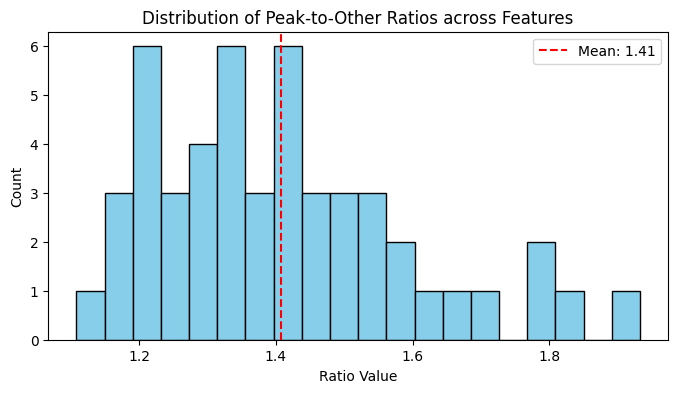

Epoch: 1, Loss: 112.844414, LR: 0.010000
Epoch: 2, Loss: 100.906036, LR: 0.010000
Epoch: 3, Loss: 91.627304, LR: 0.010000
Epoch: 4, Loss: 84.474159, LR: 0.010000
Epoch: 5, Loss: 79.062851, LR: 0.010000
Epoch: 6, Loss: 75.090599, LR: 0.010000
Epoch: 7, Loss: 72.281387, LR: 0.010000
Epoch: 8, Loss: 70.381195, LR: 0.010000
Epoch: 9, Loss: 69.173691, LR: 0.010000
Epoch: 10, Loss: 68.475052, LR: 0.010000
Epoch: 11, Loss: 68.129997, LR: 0.010000
Epoch: 12, Loss: 68.014153, LR: 0.010000
Epoch: 13, Loss: 68.033936, LR: 0.010000
Epoch: 14, Loss: 68.120148, LR: 0.010000
Epoch: 15, Loss: 68.218666, LR: 0.010000
Epoch: 16, Loss: 68.287285, LR: 0.010000
Epoch: 17, Loss: 68.293022, LR: 0.010000
Epoch: 18, Loss: 68.209190, LR: 0.010000
Epoch: 19, Loss: 68.015526, LR: 0.010000
Epoch: 20, Loss: 67.699768, LR: 0.010000
Epoch: 21, Loss: 67.257835, LR: 0.010000
Epoch: 22, Loss: 66.692619, LR: 0.010000
Epoch: 23, Loss: 66.012573, LR: 0.010000
Epoch: 24, Loss: 65.230667, LR: 0.010000
Epoch: 25, Loss: 64.363

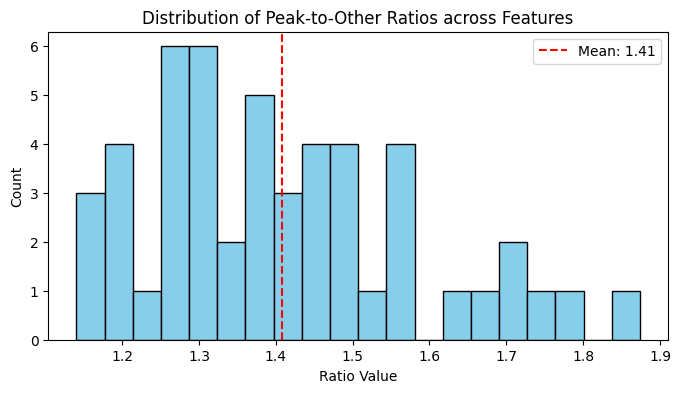

Epoch: 1, Loss: 122.935318, LR: 0.010000
Epoch: 2, Loss: 110.747910, LR: 0.010000
Epoch: 3, Loss: 101.097557, LR: 0.010000
Epoch: 4, Loss: 93.604004, LR: 0.010000
Epoch: 5, Loss: 87.897667, LR: 0.010000
Epoch: 6, Loss: 83.654877, LR: 0.010000
Epoch: 7, Loss: 80.575172, LR: 0.010000
Epoch: 8, Loss: 78.389526, LR: 0.010000
Epoch: 9, Loss: 76.875198, LR: 0.010000
Epoch: 10, Loss: 75.855103, LR: 0.010000
Epoch: 11, Loss: 75.188278, LR: 0.010000
Epoch: 12, Loss: 74.761597, LR: 0.010000
Epoch: 13, Loss: 74.486176, LR: 0.010000
Epoch: 14, Loss: 74.291374, LR: 0.010000
Epoch: 15, Loss: 74.117111, LR: 0.010000
Epoch: 16, Loss: 73.912010, LR: 0.010000
Epoch: 17, Loss: 73.636818, LR: 0.010000
Epoch: 18, Loss: 73.267136, LR: 0.010000
Epoch: 19, Loss: 72.792778, LR: 0.010000
Epoch: 20, Loss: 72.213295, LR: 0.010000
Epoch: 21, Loss: 71.532959, LR: 0.010000
Epoch: 22, Loss: 70.758347, LR: 0.010000
Epoch: 23, Loss: 69.897644, LR: 0.010000
Epoch: 24, Loss: 68.960648, LR: 0.010000
Epoch: 25, Loss: 67.95

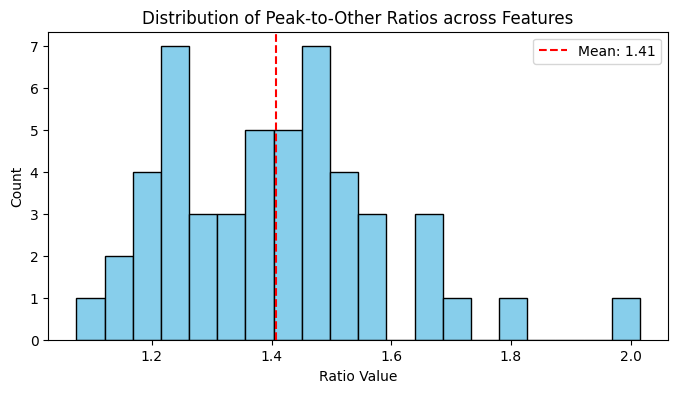


--- Testing Factor: 4 ---
Epoch: 1, Loss: 137.387146, LR: 0.010000
Epoch: 2, Loss: 122.144371, LR: 0.010000
Epoch: 3, Loss: 110.430573, LR: 0.010000
Epoch: 4, Loss: 101.528389, LR: 0.010000
Epoch: 5, Loss: 95.047562, LR: 0.010000
Epoch: 6, Loss: 90.580193, LR: 0.010000
Epoch: 7, Loss: 87.708931, LR: 0.010000
Epoch: 8, Loss: 86.041992, LR: 0.010000
Epoch: 9, Loss: 85.235229, LR: 0.010000
Epoch: 10, Loss: 84.984131, LR: 0.010000
Epoch: 11, Loss: 85.040787, LR: 0.010000
Epoch: 12, Loss: 85.206894, LR: 0.010000
Epoch: 13, Loss: 85.331383, LR: 0.010000
Epoch: 14, Loss: 85.316780, LR: 0.010000
Epoch: 15, Loss: 85.110130, LR: 0.010000
Epoch: 16, Loss: 84.687294, LR: 0.010000
Epoch: 17, Loss: 84.043762, LR: 0.010000
Epoch: 18, Loss: 83.190735, LR: 0.010000
Epoch: 19, Loss: 82.150475, LR: 0.010000
Epoch: 20, Loss: 80.951675, LR: 0.010000
Epoch: 21, Loss: 79.625938, LR: 0.010000
Epoch: 22, Loss: 78.205399, LR: 0.010000
Epoch: 23, Loss: 76.721176, LR: 0.010000
Epoch: 24, Loss: 75.201942, LR: 0.0

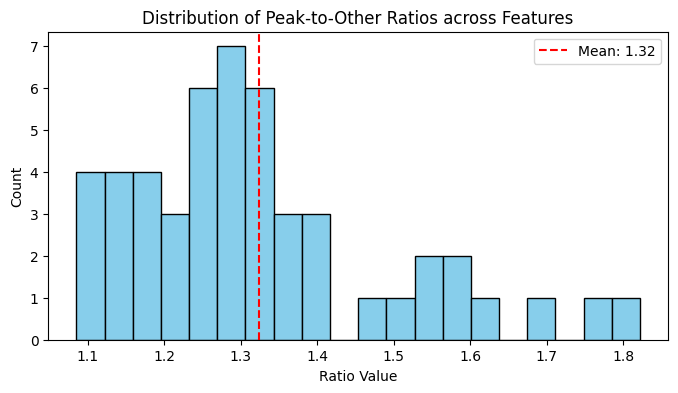

Epoch: 1, Loss: 128.594971, LR: 0.010000
Epoch: 2, Loss: 114.806412, LR: 0.010000
Epoch: 3, Loss: 104.324364, LR: 0.010000
Epoch: 4, Loss: 96.560501, LR: 0.010000
Epoch: 5, Loss: 91.071884, LR: 0.010000
Epoch: 6, Loss: 87.410057, LR: 0.010000
Epoch: 7, Loss: 85.148331, LR: 0.010000
Epoch: 8, Loss: 83.919380, LR: 0.010000
Epoch: 9, Loss: 83.400192, LR: 0.010000
Epoch: 10, Loss: 83.311150, LR: 0.010000
Epoch: 11, Loss: 83.430557, LR: 0.010000
Epoch: 12, Loss: 83.591003, LR: 0.010000
Epoch: 13, Loss: 83.672775, LR: 0.010000
Epoch: 14, Loss: 83.600098, LR: 0.010000
Epoch: 15, Loss: 83.338272, LR: 0.010000
Epoch: 16, Loss: 82.880402, LR: 0.010000
Epoch: 17, Loss: 82.231819, LR: 0.010000
Epoch: 18, Loss: 81.401268, LR: 0.010000
Epoch: 19, Loss: 80.408852, LR: 0.010000
Epoch: 20, Loss: 79.282333, LR: 0.010000
Epoch: 21, Loss: 78.048386, LR: 0.010000
Epoch: 22, Loss: 76.732521, LR: 0.010000
Epoch: 23, Loss: 75.361595, LR: 0.010000
Epoch: 24, Loss: 73.962387, LR: 0.010000
Epoch: 25, Loss: 72.55

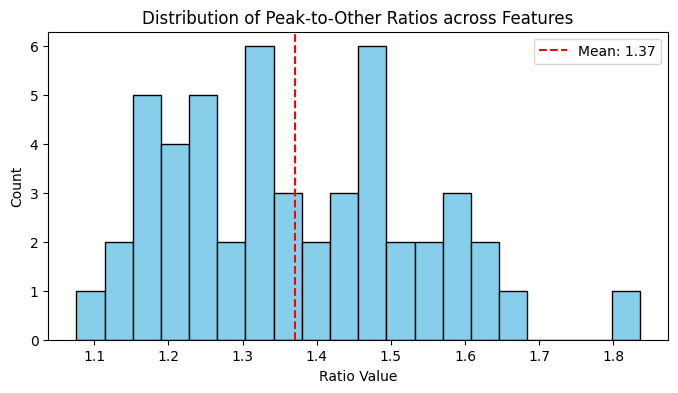

Epoch: 1, Loss: 145.060379, LR: 0.010000
Epoch: 2, Loss: 129.705063, LR: 0.010000
Epoch: 3, Loss: 117.798729, LR: 0.010000
Epoch: 4, Loss: 108.861137, LR: 0.010000
Epoch: 5, Loss: 102.408577, LR: 0.010000
Epoch: 6, Loss: 97.978729, LR: 0.010000
Epoch: 7, Loss: 95.127441, LR: 0.010000
Epoch: 8, Loss: 93.431206, LR: 0.010000
Epoch: 9, Loss: 92.532242, LR: 0.010000
Epoch: 10, Loss: 92.144005, LR: 0.010000
Epoch: 11, Loss: 92.047539, LR: 0.010000
Epoch: 12, Loss: 92.078033, LR: 0.010000
Epoch: 13, Loss: 92.113091, LR: 0.010000
Epoch: 14, Loss: 92.063873, LR: 0.010000
Epoch: 15, Loss: 91.871574, LR: 0.010000
Epoch: 16, Loss: 91.502998, LR: 0.010000
Epoch: 17, Loss: 90.944839, LR: 0.010000
Epoch: 18, Loss: 90.196869, LR: 0.010000
Epoch: 19, Loss: 89.267067, LR: 0.010000
Epoch: 20, Loss: 88.168533, LR: 0.010000
Epoch: 21, Loss: 86.918594, LR: 0.010000
Epoch: 22, Loss: 85.538712, LR: 0.010000
Epoch: 23, Loss: 84.053474, LR: 0.010000
Epoch: 24, Loss: 82.489441, LR: 0.010000
Epoch: 25, Loss: 80.

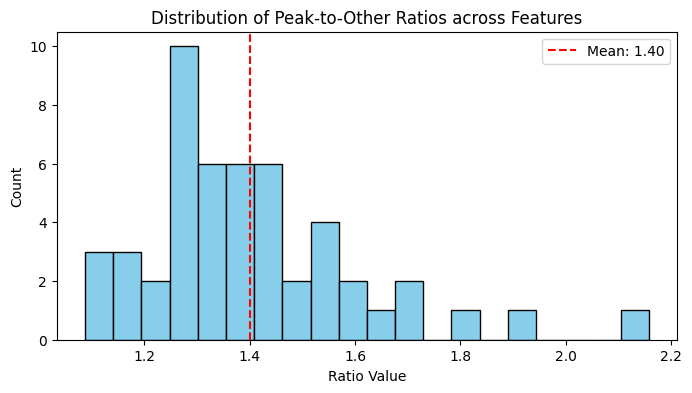

Epoch: 1, Loss: 141.449921, LR: 0.010000
Epoch: 2, Loss: 126.796463, LR: 0.010000
Epoch: 3, Loss: 115.621773, LR: 0.010000
Epoch: 4, Loss: 107.380844, LR: 0.010000
Epoch: 5, Loss: 101.581528, LR: 0.010000
Epoch: 6, Loss: 97.726517, LR: 0.010000
Epoch: 7, Loss: 95.354622, LR: 0.010000
Epoch: 8, Loss: 94.062042, LR: 0.010000
Epoch: 9, Loss: 93.495598, LR: 0.010000
Epoch: 10, Loss: 93.366020, LR: 0.010000
Epoch: 11, Loss: 93.441628, LR: 0.010000
Epoch: 12, Loss: 93.538315, LR: 0.010000
Epoch: 13, Loss: 93.521690, LR: 0.010000
Epoch: 14, Loss: 93.301598, LR: 0.010000
Epoch: 15, Loss: 92.824165, LR: 0.010000
Epoch: 16, Loss: 92.072472, LR: 0.010000
Epoch: 17, Loss: 91.057465, LR: 0.010000
Epoch: 18, Loss: 89.806770, LR: 0.010000
Epoch: 19, Loss: 88.356407, LR: 0.010000
Epoch: 20, Loss: 86.744217, LR: 0.010000
Epoch: 21, Loss: 85.007446, LR: 0.010000
Epoch: 22, Loss: 83.181854, LR: 0.010000
Epoch: 23, Loss: 81.302078, LR: 0.010000
Epoch: 24, Loss: 79.401054, LR: 0.010000
Epoch: 25, Loss: 77.

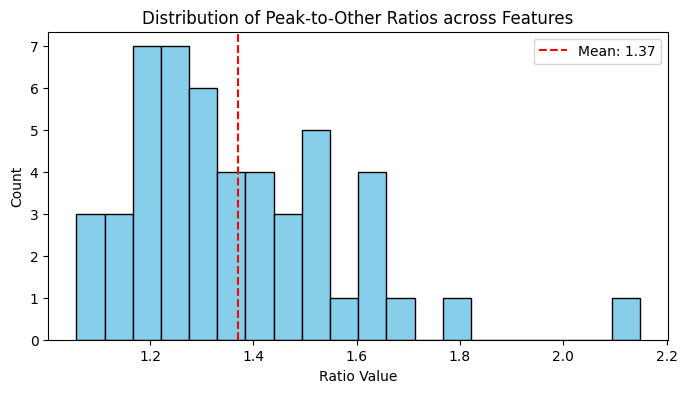

Epoch: 1, Loss: 147.339249, LR: 0.010000
Epoch: 2, Loss: 131.488205, LR: 0.010000
Epoch: 3, Loss: 119.061699, LR: 0.010000
Epoch: 4, Loss: 109.671944, LR: 0.010000
Epoch: 5, Loss: 102.892151, LR: 0.010000
Epoch: 6, Loss: 98.267181, LR: 0.010000
Epoch: 7, Loss: 95.346939, LR: 0.010000
Epoch: 8, Loss: 93.705551, LR: 0.010000
Epoch: 9, Loss: 92.961273, LR: 0.010000
Epoch: 10, Loss: 92.798996, LR: 0.010000
Epoch: 11, Loss: 92.968849, LR: 0.010000
Epoch: 12, Loss: 93.277359, LR: 0.010000
Epoch: 13, Loss: 93.578346, LR: 0.010000
Epoch: 14, Loss: 93.762978, LR: 0.010000
Epoch: 15, Loss: 93.753433, LR: 0.010000
Epoch: 16, Loss: 93.498978, LR: 0.010000
Epoch: 17, Loss: 92.973625, LR: 0.010000
Epoch: 18, Loss: 92.172340, LR: 0.010000
Epoch: 19, Loss: 91.105972, LR: 0.010000
Epoch: 20, Loss: 89.798416, LR: 0.010000
Epoch: 21, Loss: 88.282875, LR: 0.010000
Epoch: 22, Loss: 86.597885, LR: 0.010000
Epoch: 23, Loss: 84.784645, LR: 0.010000
Epoch: 24, Loss: 82.883530, LR: 0.010000
Epoch: 25, Loss: 80.

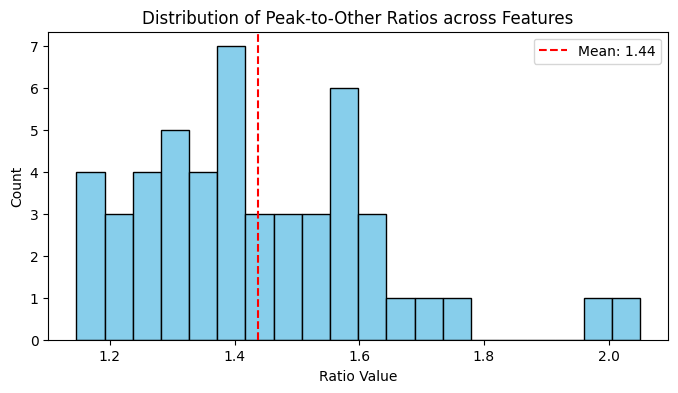

Epoch: 1, Loss: 143.992172, LR: 0.010000
Epoch: 2, Loss: 129.485886, LR: 0.010000
Epoch: 3, Loss: 118.294136, LR: 0.010000
Epoch: 4, Loss: 110.023926, LR: 0.010000
Epoch: 5, Loss: 104.197853, LR: 0.010000
Epoch: 6, Loss: 100.328957, LR: 0.010000
Epoch: 7, Loss: 97.952713, LR: 0.010000
Epoch: 8, Loss: 96.650909, LR: 0.010000
Epoch: 9, Loss: 96.066711, LR: 0.010000
Epoch: 10, Loss: 95.893707, LR: 0.010000
Epoch: 11, Loss: 95.898308, LR: 0.010000
Epoch: 12, Loss: 95.930237, LR: 0.010000
Epoch: 13, Loss: 95.888580, LR: 0.010000
Epoch: 14, Loss: 95.706238, LR: 0.010000
Epoch: 15, Loss: 95.338608, LR: 0.010000
Epoch: 16, Loss: 94.765694, LR: 0.010000
Epoch: 17, Loss: 93.979233, LR: 0.010000
Epoch: 18, Loss: 92.981781, LR: 0.010000
Epoch: 19, Loss: 91.787842, LR: 0.010000
Epoch: 20, Loss: 90.422943, LR: 0.010000
Epoch: 21, Loss: 88.917984, LR: 0.010000
Epoch: 22, Loss: 87.303535, LR: 0.010000
Epoch: 23, Loss: 85.612053, LR: 0.010000
Epoch: 24, Loss: 83.875015, LR: 0.010000
Epoch: 25, Loss: 82

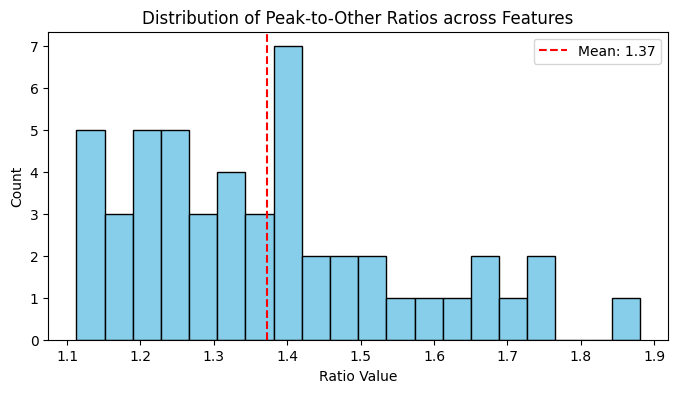

Epoch: 1, Loss: 137.869003, LR: 0.010000
Epoch: 2, Loss: 122.894386, LR: 0.010000
Epoch: 3, Loss: 111.388084, LR: 0.010000
Epoch: 4, Loss: 102.762329, LR: 0.010000
Epoch: 5, Loss: 96.523438, LR: 0.010000
Epoch: 6, Loss: 92.220245, LR: 0.010000
Epoch: 7, Loss: 89.420624, LR: 0.010000
Epoch: 8, Loss: 87.723473, LR: 0.010000
Epoch: 9, Loss: 86.779144, LR: 0.010000
Epoch: 10, Loss: 86.305725, LR: 0.010000
Epoch: 11, Loss: 86.087639, LR: 0.010000
Epoch: 12, Loss: 85.968788, LR: 0.010000
Epoch: 13, Loss: 85.835602, LR: 0.010000
Epoch: 14, Loss: 85.603859, LR: 0.010000
Epoch: 15, Loss: 85.217476, LR: 0.010000
Epoch: 16, Loss: 84.645164, LR: 0.010000
Epoch: 17, Loss: 83.879707, LR: 0.010000
Epoch: 18, Loss: 82.928940, LR: 0.010000
Epoch: 19, Loss: 81.811104, LR: 0.010000
Epoch: 20, Loss: 80.551338, LR: 0.010000
Epoch: 21, Loss: 79.176926, LR: 0.010000
Epoch: 22, Loss: 77.715164, LR: 0.010000
Epoch: 23, Loss: 76.193237, LR: 0.010000
Epoch: 24, Loss: 74.637955, LR: 0.010000
Epoch: 25, Loss: 73.0

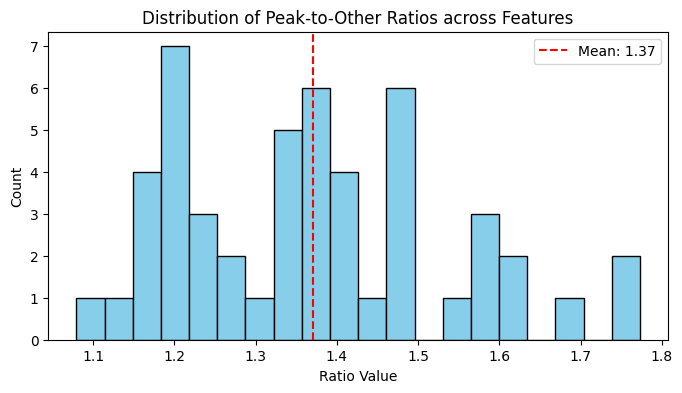

Epoch: 1, Loss: 125.446571, LR: 0.010000
Epoch: 2, Loss: 112.313370, LR: 0.010000
Epoch: 3, Loss: 102.369759, LR: 0.010000
Epoch: 4, Loss: 95.031242, LR: 0.010000
Epoch: 5, Loss: 89.854111, LR: 0.010000
Epoch: 6, Loss: 86.414085, LR: 0.010000
Epoch: 7, Loss: 84.338554, LR: 0.010000
Epoch: 8, Loss: 83.273155, LR: 0.010000
Epoch: 9, Loss: 82.907593, LR: 0.010000
Epoch: 10, Loss: 82.972786, LR: 0.010000
Epoch: 11, Loss: 83.235085, LR: 0.010000
Epoch: 12, Loss: 83.529556, LR: 0.010000
Epoch: 13, Loss: 83.742950, LR: 0.010000
Epoch: 14, Loss: 83.788353, LR: 0.010000
Epoch: 15, Loss: 83.622719, LR: 0.010000
Epoch: 16, Loss: 83.224579, LR: 0.010000
Epoch: 17, Loss: 82.592590, LR: 0.010000
Epoch: 18, Loss: 81.738701, LR: 0.010000
Epoch: 19, Loss: 80.683609, LR: 0.010000
Epoch: 20, Loss: 79.454987, LR: 0.010000
Epoch: 21, Loss: 78.086075, LR: 0.010000
Epoch: 22, Loss: 76.612946, LR: 0.010000
Epoch: 23, Loss: 75.071671, LR: 0.010000
Epoch: 24, Loss: 73.495644, LR: 0.010000
Epoch: 25, Loss: 71.91

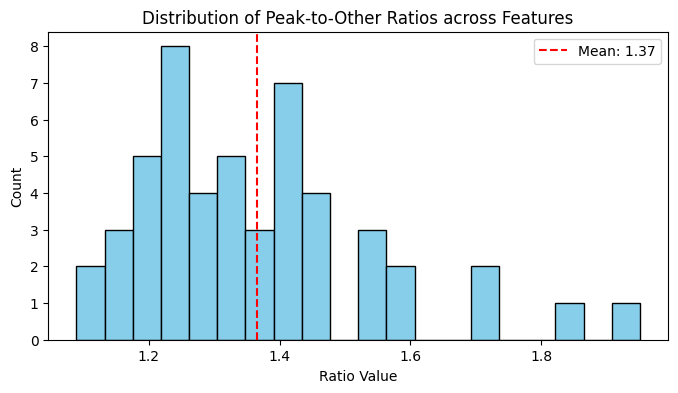

Epoch: 1, Loss: 135.985764, LR: 0.010000
Epoch: 2, Loss: 121.639145, LR: 0.010000
Epoch: 3, Loss: 110.496468, LR: 0.010000
Epoch: 4, Loss: 102.152794, LR: 0.010000
Epoch: 5, Loss: 96.160591, LR: 0.010000
Epoch: 6, Loss: 92.071945, LR: 0.010000
Epoch: 7, Loss: 89.458054, LR: 0.010000
Epoch: 8, Loss: 87.925331, LR: 0.010000
Epoch: 9, Loss: 87.141159, LR: 0.010000
Epoch: 10, Loss: 86.827034, LR: 0.010000
Epoch: 11, Loss: 86.764114, LR: 0.010000
Epoch: 12, Loss: 86.786888, LR: 0.010000
Epoch: 13, Loss: 86.773064, LR: 0.010000
Epoch: 14, Loss: 86.637787, LR: 0.010000
Epoch: 15, Loss: 86.328171, LR: 0.010000
Epoch: 16, Loss: 85.816025, LR: 0.010000
Epoch: 17, Loss: 85.093559, LR: 0.010000
Epoch: 18, Loss: 84.167198, LR: 0.010000
Epoch: 19, Loss: 83.053391, LR: 0.010000
Epoch: 20, Loss: 81.774826, LR: 0.010000
Epoch: 21, Loss: 80.357468, LR: 0.010000
Epoch: 22, Loss: 78.828796, LR: 0.010000
Epoch: 23, Loss: 77.216576, LR: 0.010000
Epoch: 24, Loss: 75.548347, LR: 0.010000
Epoch: 25, Loss: 73.8

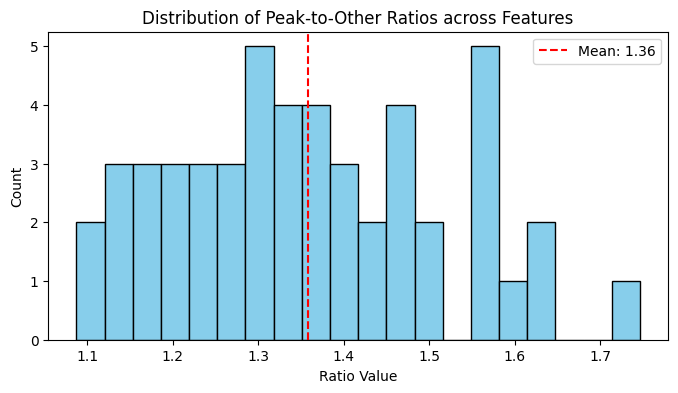

Epoch: 1, Loss: 123.636398, LR: 0.010000
Epoch: 2, Loss: 110.105568, LR: 0.010000
Epoch: 3, Loss: 99.675751, LR: 0.010000
Epoch: 4, Loss: 91.897324, LR: 0.010000
Epoch: 5, Loss: 86.327423, LR: 0.010000
Epoch: 6, Loss: 82.523361, LR: 0.010000
Epoch: 7, Loss: 80.083504, LR: 0.010000
Epoch: 8, Loss: 78.659744, LR: 0.010000
Epoch: 9, Loss: 77.961975, LR: 0.010000
Epoch: 10, Loss: 77.742767, LR: 0.010000
Epoch: 11, Loss: 77.789780, LR: 0.010000
Epoch: 12, Loss: 77.933563, LR: 0.010000
Epoch: 13, Loss: 78.045647, LR: 0.010000
Epoch: 14, Loss: 78.037186, LR: 0.010000
Epoch: 15, Loss: 77.853851, LR: 0.010000
Epoch: 16, Loss: 77.464798, LR: 0.010000
Epoch: 17, Loss: 76.855652, LR: 0.010000
Epoch: 18, Loss: 76.024765, LR: 0.010000
Epoch: 19, Loss: 74.983185, LR: 0.010000
Epoch: 20, Loss: 73.754562, LR: 0.010000
Epoch: 21, Loss: 72.372063, LR: 0.010000
Epoch: 22, Loss: 70.874580, LR: 0.010000
Epoch: 23, Loss: 69.302849, LR: 0.010000
Epoch: 24, Loss: 67.695564, LR: 0.010000
Epoch: 25, Loss: 66.087

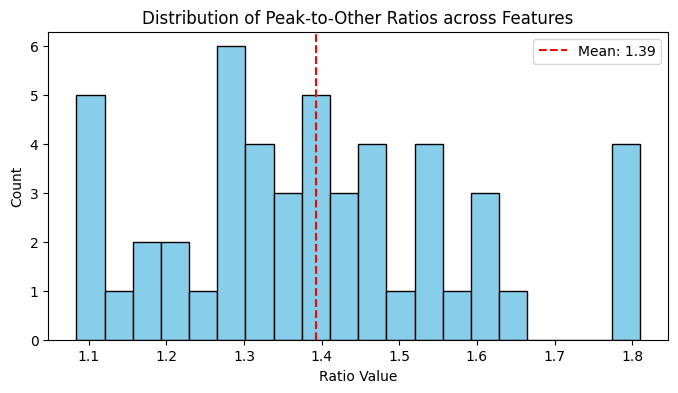


--- Testing Factor: 5 ---
Epoch: 1, Loss: 138.645416, LR: 0.010000
Epoch: 2, Loss: 124.231026, LR: 0.010000
Epoch: 3, Loss: 113.696045, LR: 0.010000
Epoch: 4, Loss: 106.367325, LR: 0.010000
Epoch: 5, Loss: 101.651459, LR: 0.010000
Epoch: 6, Loss: 98.956764, LR: 0.010000
Epoch: 7, Loss: 97.731049, LR: 0.010000
Epoch: 8, Loss: 97.487999, LR: 0.010000
Epoch: 9, Loss: 97.829544, LR: 0.010000
Epoch: 10, Loss: 98.431824, LR: 0.010000
Epoch: 11, Loss: 99.023483, LR: 0.010000
Epoch: 12, Loss: 99.388084, LR: 0.010000
Epoch: 13, Loss: 99.375832, LR: 0.010000
Epoch: 14, Loss: 98.907181, LR: 0.010000
Epoch: 15, Loss: 97.964607, LR: 0.010000
Epoch: 16, Loss: 96.575813, LR: 0.010000
Epoch: 17, Loss: 94.797035, LR: 0.010000
Epoch: 18, Loss: 92.701668, LR: 0.010000
Epoch: 19, Loss: 90.370728, LR: 0.010000
Epoch: 20, Loss: 87.884552, LR: 0.010000
Epoch: 21, Loss: 85.317368, LR: 0.010000
Epoch: 22, Loss: 82.735077, LR: 0.010000
Epoch: 23, Loss: 80.194321, LR: 0.010000
Epoch: 24, Loss: 77.742027, LR: 0.

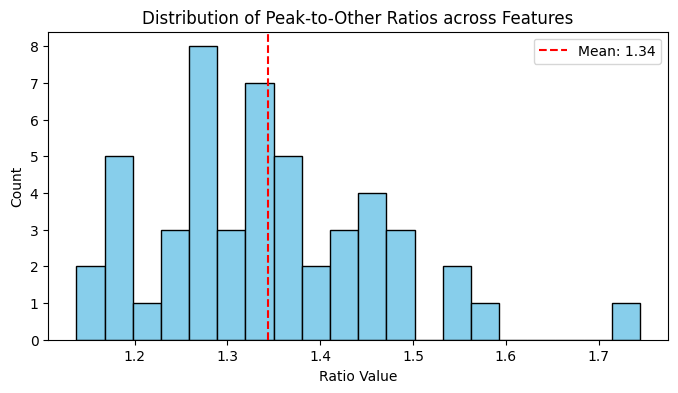

Epoch: 1, Loss: 129.253220, LR: 0.010000
Epoch: 2, Loss: 114.146591, LR: 0.010000
Epoch: 3, Loss: 102.876961, LR: 0.010000
Epoch: 4, Loss: 94.915634, LR: 0.010000
Epoch: 5, Loss: 89.679100, LR: 0.010000
Epoch: 6, Loss: 86.597900, LR: 0.010000
Epoch: 7, Loss: 85.101799, LR: 0.010000
Epoch: 8, Loss: 84.667427, LR: 0.010000
Epoch: 9, Loss: 84.849037, LR: 0.010000
Epoch: 10, Loss: 85.302406, LR: 0.010000
Epoch: 11, Loss: 85.776390, LR: 0.010000
Epoch: 12, Loss: 86.088921, LR: 0.010000
Epoch: 13, Loss: 86.115807, LR: 0.010000
Epoch: 14, Loss: 85.788086, LR: 0.010000
Epoch: 15, Loss: 85.085419, LR: 0.010000
Epoch: 16, Loss: 84.024323, LR: 0.010000
Epoch: 17, Loss: 82.645721, LR: 0.010000
Epoch: 18, Loss: 81.004692, LR: 0.010000
Epoch: 19, Loss: 79.162430, LR: 0.010000
Epoch: 20, Loss: 77.179863, LR: 0.010000
Epoch: 21, Loss: 75.113464, LR: 0.010000
Epoch: 22, Loss: 73.013649, LR: 0.010000
Epoch: 23, Loss: 70.924683, LR: 0.010000
Epoch: 24, Loss: 68.885048, LR: 0.010000
Epoch: 25, Loss: 66.92

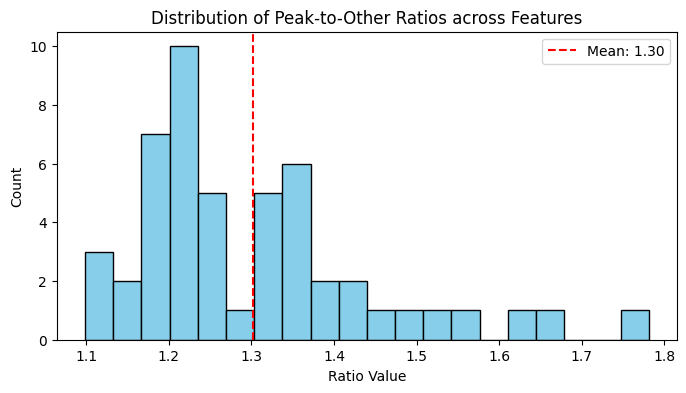

Epoch: 1, Loss: 148.334030, LR: 0.010000
Epoch: 2, Loss: 131.829422, LR: 0.010000
Epoch: 3, Loss: 119.546326, LR: 0.010000
Epoch: 4, Loss: 110.859306, LR: 0.010000
Epoch: 5, Loss: 105.114609, LR: 0.010000
Epoch: 6, Loss: 101.688316, LR: 0.010000
Epoch: 7, Loss: 100.009766, LR: 0.010000
Epoch: 8, Loss: 99.563232, LR: 0.010000
Epoch: 9, Loss: 99.877228, LR: 0.010000
Epoch: 10, Loss: 100.540367, LR: 0.010000
Epoch: 11, Loss: 101.216621, LR: 0.010000
Epoch: 12, Loss: 101.656021, LR: 0.010000
Epoch: 13, Loss: 101.697197, LR: 0.010000
Epoch: 14, Loss: 101.260078, LR: 0.010000
Epoch: 15, Loss: 100.329895, LR: 0.010000
Epoch: 16, Loss: 98.938370, LR: 0.010000
Epoch: 17, Loss: 97.147141, LR: 0.010000
Epoch: 18, Loss: 95.035103, LR: 0.010000
Epoch: 19, Loss: 92.686867, LR: 0.010000
Epoch: 20, Loss: 90.184418, LR: 0.010000
Epoch: 21, Loss: 87.602493, LR: 0.010000
Epoch: 22, Loss: 85.006508, LR: 0.010000
Epoch: 23, Loss: 82.451302, LR: 0.010000
Epoch: 24, Loss: 79.980965, LR: 0.010000
Epoch: 25, L

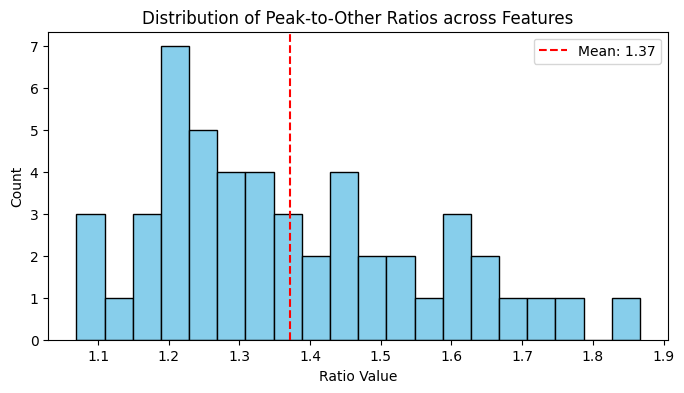

Epoch: 1, Loss: 150.504166, LR: 0.010000
Epoch: 2, Loss: 133.775833, LR: 0.010000
Epoch: 3, Loss: 121.290863, LR: 0.010000
Epoch: 4, Loss: 112.388527, LR: 0.010000
Epoch: 5, Loss: 106.481720, LR: 0.010000
Epoch: 6, Loss: 102.936256, LR: 0.010000
Epoch: 7, Loss: 101.127350, LR: 0.010000
Epoch: 8, Loss: 100.485237, LR: 0.010000
Epoch: 9, Loss: 100.523323, LR: 0.010000
Epoch: 10, Loss: 100.853310, LR: 0.010000
Epoch: 11, Loss: 101.173203, LR: 0.010000
Epoch: 12, Loss: 101.263512, LR: 0.010000
Epoch: 13, Loss: 100.988167, LR: 0.010000
Epoch: 14, Loss: 100.282021, LR: 0.010000
Epoch: 15, Loss: 99.133812, LR: 0.010000
Epoch: 16, Loss: 97.572189, LR: 0.010000
Epoch: 17, Loss: 95.653831, LR: 0.010000
Epoch: 18, Loss: 93.452057, LR: 0.010000
Epoch: 19, Loss: 91.046890, LR: 0.010000
Epoch: 20, Loss: 88.517128, LR: 0.010000
Epoch: 21, Loss: 85.934746, LR: 0.010000
Epoch: 22, Loss: 83.361893, LR: 0.010000
Epoch: 23, Loss: 80.849892, LR: 0.010000
Epoch: 24, Loss: 78.439430, LR: 0.010000
Epoch: 25, 

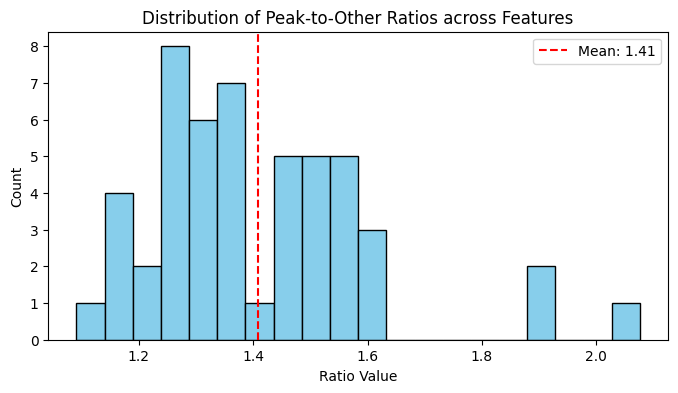

Epoch: 1, Loss: 141.835312, LR: 0.010000
Epoch: 2, Loss: 126.880119, LR: 0.010000
Epoch: 3, Loss: 116.080139, LR: 0.010000
Epoch: 4, Loss: 108.661171, LR: 0.010000
Epoch: 5, Loss: 103.970779, LR: 0.010000
Epoch: 6, Loss: 101.380241, LR: 0.010000
Epoch: 7, Loss: 100.317719, LR: 0.010000
Epoch: 8, Loss: 100.262054, LR: 0.010000
Epoch: 9, Loss: 100.747978, LR: 0.010000
Epoch: 10, Loss: 101.399925, LR: 0.010000
Epoch: 11, Loss: 101.942360, LR: 0.010000
Epoch: 12, Loss: 102.187515, LR: 0.010000
Epoch: 13, Loss: 102.024582, LR: 0.010000
Epoch: 14, Loss: 101.409576, LR: 0.010000
Epoch: 15, Loss: 100.348228, LR: 0.010000
Epoch: 16, Loss: 98.877975, LR: 0.010000
Epoch: 17, Loss: 97.055428, LR: 0.010000
Epoch: 18, Loss: 94.949287, LR: 0.010000
Epoch: 19, Loss: 92.634789, LR: 0.010000
Epoch: 20, Loss: 90.187691, LR: 0.010000
Epoch: 21, Loss: 87.678200, LR: 0.010000
Epoch: 22, Loss: 85.167725, LR: 0.010000
Epoch: 23, Loss: 82.707802, LR: 0.010000
Epoch: 24, Loss: 80.340042, LR: 0.010000
Epoch: 25,

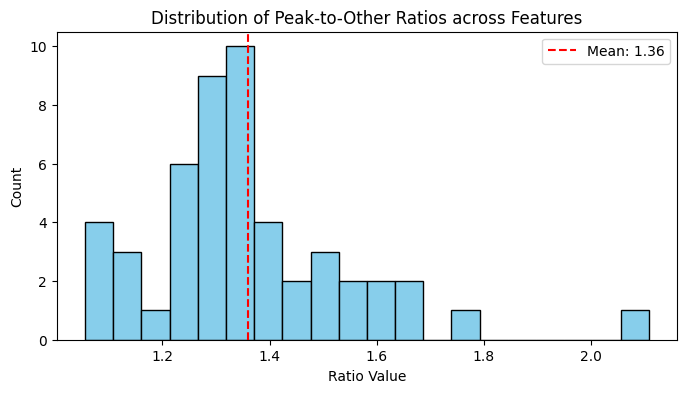

Epoch: 1, Loss: 137.933517, LR: 0.010000
Epoch: 2, Loss: 122.251419, LR: 0.010000
Epoch: 3, Loss: 110.599548, LR: 0.010000
Epoch: 4, Loss: 102.309242, LR: 0.010000
Epoch: 5, Loss: 96.768608, LR: 0.010000
Epoch: 6, Loss: 93.379616, LR: 0.010000
Epoch: 7, Loss: 91.585800, LR: 0.010000
Epoch: 8, Loss: 90.885643, LR: 0.010000
Epoch: 9, Loss: 90.854149, LR: 0.010000
Epoch: 10, Loss: 91.147285, LR: 0.010000
Epoch: 11, Loss: 91.497307, LR: 0.010000
Epoch: 12, Loss: 91.718346, LR: 0.010000
Epoch: 13, Loss: 91.687912, LR: 0.010000
Epoch: 14, Loss: 91.334595, LR: 0.010000
Epoch: 15, Loss: 90.629967, LR: 0.010000
Epoch: 16, Loss: 89.578957, LR: 0.010000
Epoch: 17, Loss: 88.209587, LR: 0.010000
Epoch: 18, Loss: 86.564163, LR: 0.010000
Epoch: 19, Loss: 84.693466, LR: 0.010000
Epoch: 20, Loss: 82.653488, LR: 0.010000
Epoch: 21, Loss: 80.503189, LR: 0.010000
Epoch: 22, Loss: 78.301193, LR: 0.010000
Epoch: 23, Loss: 76.102356, LR: 0.010000
Epoch: 24, Loss: 73.954987, LR: 0.010000
Epoch: 25, Loss: 71.8

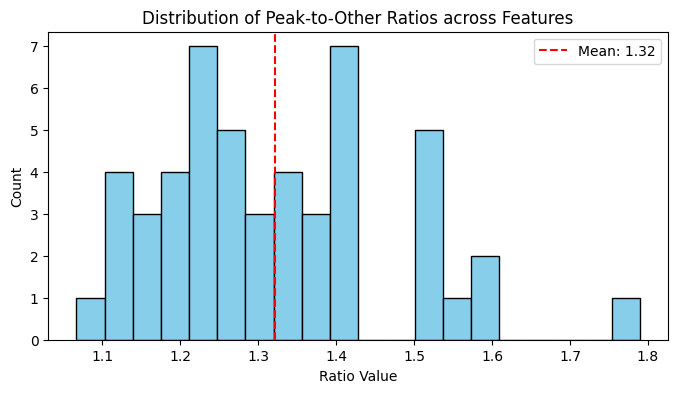

Epoch: 1, Loss: 160.450531, LR: 0.010000
Epoch: 2, Loss: 142.364960, LR: 0.010000
Epoch: 3, Loss: 129.058090, LR: 0.010000
Epoch: 4, Loss: 119.576820, LR: 0.010000
Epoch: 5, Loss: 113.266525, LR: 0.010000
Epoch: 6, Loss: 109.462654, LR: 0.010000
Epoch: 7, Loss: 107.514641, LR: 0.010000
Epoch: 8, Loss: 106.804886, LR: 0.010000
Epoch: 9, Loss: 106.822060, LR: 0.010000
Epoch: 10, Loss: 107.166183, LR: 0.010000
Epoch: 11, Loss: 107.536957, LR: 0.010000
Epoch: 12, Loss: 107.716446, LR: 0.010000
Epoch: 13, Loss: 107.557930, LR: 0.010000
Epoch: 14, Loss: 106.977623, LR: 0.010000
Epoch: 15, Loss: 105.946884, LR: 0.010000
Epoch: 16, Loss: 104.480835, LR: 0.010000
Epoch: 17, Loss: 102.625839, LR: 0.010000
Epoch: 18, Loss: 100.448074, LR: 0.010000
Epoch: 19, Loss: 98.024040, LR: 0.010000
Epoch: 20, Loss: 95.432762, LR: 0.010000
Epoch: 21, Loss: 92.749649, LR: 0.010000
Epoch: 22, Loss: 90.042343, LR: 0.010000
Epoch: 23, Loss: 87.369072, LR: 0.010000
Epoch: 24, Loss: 84.778275, LR: 0.010000
Epoch: 

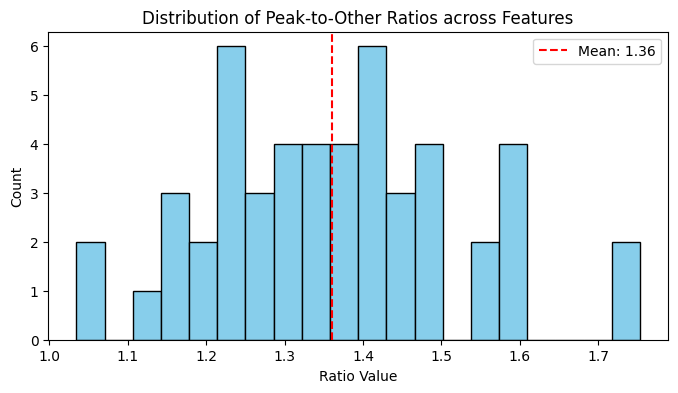

Epoch: 1, Loss: 145.340012, LR: 0.010000
Epoch: 2, Loss: 130.093002, LR: 0.010000
Epoch: 3, Loss: 118.947525, LR: 0.010000
Epoch: 4, Loss: 111.215981, LR: 0.010000
Epoch: 5, Loss: 106.244934, LR: 0.010000
Epoch: 6, Loss: 103.372787, LR: 0.010000
Epoch: 7, Loss: 101.967377, LR: 0.010000
Epoch: 8, Loss: 101.502289, LR: 0.010000
Epoch: 9, Loss: 101.543289, LR: 0.010000
Epoch: 10, Loss: 101.760162, LR: 0.010000
Epoch: 11, Loss: 101.908043, LR: 0.010000
Epoch: 12, Loss: 101.813354, LR: 0.010000
Epoch: 13, Loss: 101.370705, LR: 0.010000
Epoch: 14, Loss: 100.530922, LR: 0.010000
Epoch: 15, Loss: 99.285904, LR: 0.010000
Epoch: 16, Loss: 97.660103, LR: 0.010000
Epoch: 17, Loss: 95.702728, LR: 0.010000
Epoch: 18, Loss: 93.477226, LR: 0.010000
Epoch: 19, Loss: 91.054604, LR: 0.010000
Epoch: 20, Loss: 88.507881, LR: 0.010000
Epoch: 21, Loss: 85.907181, LR: 0.010000
Epoch: 22, Loss: 83.316338, LR: 0.010000
Epoch: 23, Loss: 80.790657, LR: 0.010000
Epoch: 24, Loss: 78.375763, LR: 0.010000
Epoch: 25, 

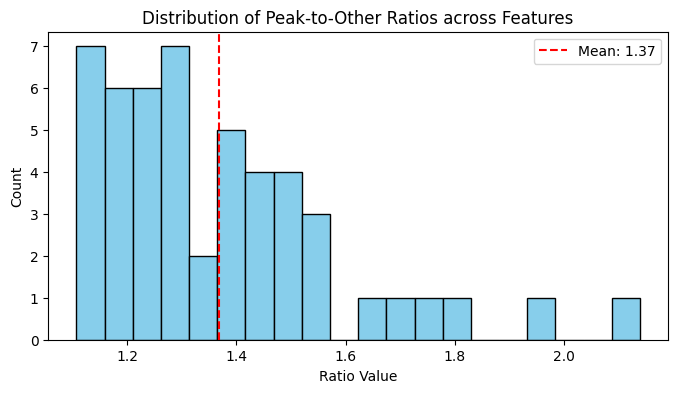

Epoch: 1, Loss: 146.844589, LR: 0.010000
Epoch: 2, Loss: 130.589630, LR: 0.010000
Epoch: 3, Loss: 118.498062, LR: 0.010000
Epoch: 4, Loss: 109.883087, LR: 0.010000
Epoch: 5, Loss: 104.129631, LR: 0.010000
Epoch: 6, Loss: 100.552719, LR: 0.010000
Epoch: 7, Loss: 98.542175, LR: 0.010000
Epoch: 8, Loss: 97.584679, LR: 0.010000
Epoch: 9, Loss: 97.243217, LR: 0.010000
Epoch: 10, Loss: 97.170891, LR: 0.010000
Epoch: 11, Loss: 97.114967, LR: 0.010000
Epoch: 12, Loss: 96.904991, LR: 0.010000
Epoch: 13, Loss: 96.434319, LR: 0.010000
Epoch: 14, Loss: 95.644951, LR: 0.010000
Epoch: 15, Loss: 94.518951, LR: 0.010000
Epoch: 16, Loss: 93.071396, LR: 0.010000
Epoch: 17, Loss: 91.340889, LR: 0.010000
Epoch: 18, Loss: 89.380013, LR: 0.010000
Epoch: 19, Loss: 87.247673, LR: 0.010000
Epoch: 20, Loss: 85.003883, LR: 0.010000
Epoch: 21, Loss: 82.706169, LR: 0.010000
Epoch: 22, Loss: 80.406921, LR: 0.010000
Epoch: 23, Loss: 78.151566, LR: 0.010000
Epoch: 24, Loss: 75.977806, LR: 0.010000
Epoch: 25, Loss: 73

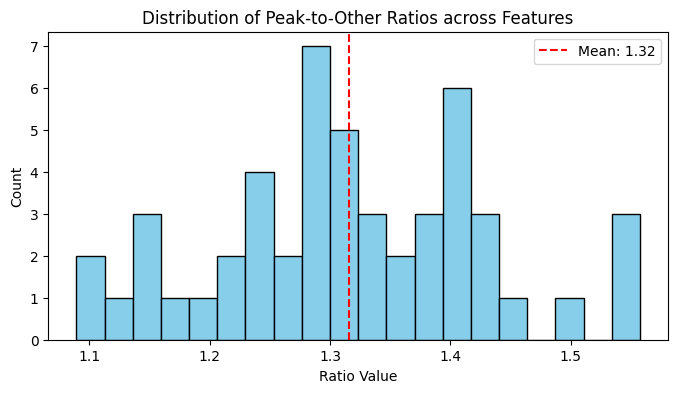

Epoch: 1, Loss: 154.091690, LR: 0.010000
Epoch: 2, Loss: 138.475479, LR: 0.010000
Epoch: 3, Loss: 126.919655, LR: 0.010000
Epoch: 4, Loss: 118.765808, LR: 0.010000
Epoch: 5, Loss: 113.390129, LR: 0.010000
Epoch: 6, Loss: 110.160187, LR: 0.010000
Epoch: 7, Loss: 108.473740, LR: 0.010000
Epoch: 8, Loss: 107.770363, LR: 0.010000
Epoch: 9, Loss: 107.597366, LR: 0.010000
Epoch: 10, Loss: 107.622887, LR: 0.010000
Epoch: 11, Loss: 107.603645, LR: 0.010000
Epoch: 12, Loss: 107.366524, LR: 0.010000
Epoch: 13, Loss: 106.800171, LR: 0.010000
Epoch: 14, Loss: 105.849258, LR: 0.010000
Epoch: 15, Loss: 104.505821, LR: 0.010000
Epoch: 16, Loss: 102.797264, LR: 0.010000
Epoch: 17, Loss: 100.773735, LR: 0.010000
Epoch: 18, Loss: 98.497772, LR: 0.010000
Epoch: 19, Loss: 96.037163, LR: 0.010000
Epoch: 20, Loss: 93.459793, LR: 0.010000
Epoch: 21, Loss: 90.829597, LR: 0.010000
Epoch: 22, Loss: 88.204041, LR: 0.010000
Epoch: 23, Loss: 85.633034, LR: 0.010000
Epoch: 24, Loss: 83.158699, LR: 0.010000
Epoch: 2

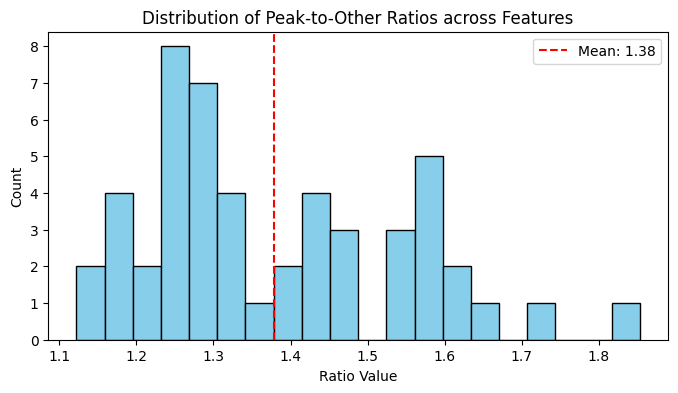

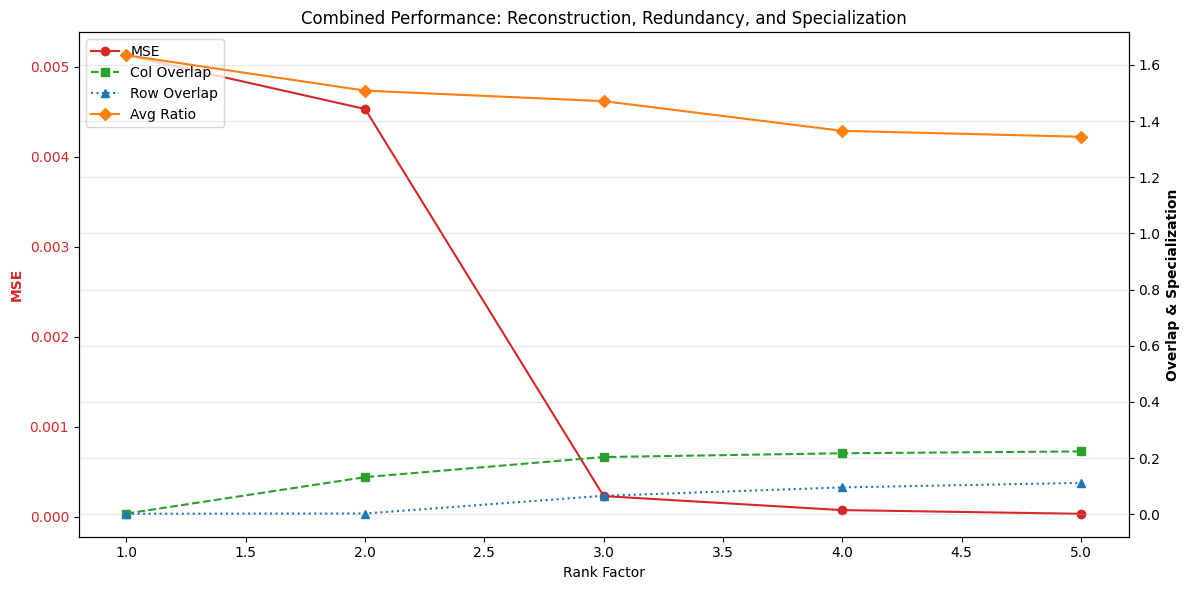

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Configuration
factors = [1, 2, 3, 4, 5]
num_trials = 10
results = {f: {"mse": 0.0, "sim": 0.0, "col": 0.0, "row": 0.0, "ratio": 0.0} for f in factors}

for factor in factors:
    print(f"\n--- Testing Factor: {factor} ---")
    rank = max(1, (min(d_in, d_out) // n_components) * factor)

    # Initialize trackers
    min_overlap_sum = float('inf')
    best_trial_data = None

    for trial in range(num_trials):
        # 1. Train
        components = train(model.weights.detach().cpu(), data, rank=rank)
        comp_list = [U @ torch.diag(F.softplus(S)) @ V.T for U, S, V in components]

        # 2. Gather Metrics
        err, sim = get_matrix_reconstruction_metrics(model, comp_list)
        col_avg, _, row_avg, _ = get_orthogonality_metrics(components)
        ratio = calculate_global_specialization_ratio(data, components, device)

        # 3. Selection Logic (Minimizing overlap)
        overlap_sum = col_avg + row_avg
        if overlap_sum < min_overlap_sum:
            min_overlap_sum = overlap_sum
            results[factor] = {
                "mse": err.item() if hasattr(err, 'item') else err,
                "sim": sim.item() if hasattr(sim, 'item') else sim,
                "col": col_avg,
                "row": row_avg,
                "ratio": ratio
            }

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: MSE
ax1.set_xlabel('Rank Factor')
ax1.set_ylabel('MSE', color='tab:red', fontweight='bold')
ax1.plot(factors, [results[f]["mse"] for f in factors], marker='o', color='tab:red', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Secondary Axis: Metrics
ax2 = ax1.twinx()
ax2.set_ylabel('Overlap & Specialization', color='black', fontweight='bold')
ax2.plot(factors, [results[f]["col"] for f in factors], marker='s', linestyle='--', color='tab:green', label='Col Overlap')
ax2.plot(factors, [results[f]["row"] for f in factors], marker='^', linestyle=':', color='tab:blue', label='Row Overlap')
ax2.plot(factors, [results[f]["ratio"] for f in factors], marker='D', linestyle='-', color='tab:orange', label='Avg Ratio')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Combined Performance: Reconstruction, Redundancy, and Specialization')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


--- Testing Factor: 1 ---
Epoch: 1, Loss: 22.017721, LR: 0.010000
Epoch: 2, Loss: 20.562014, LR: 0.010000
Epoch: 3, Loss: 19.301382, LR: 0.010000
Epoch: 4, Loss: 18.195608, LR: 0.010000
Epoch: 5, Loss: 17.215582, LR: 0.010000
Epoch: 6, Loss: 16.342361, LR: 0.010000
Epoch: 7, Loss: 15.567417, LR: 0.010000
Epoch: 8, Loss: 14.878307, LR: 0.010000
Epoch: 9, Loss: 14.259593, LR: 0.010000
Epoch: 10, Loss: 13.699091, LR: 0.010000
Epoch: 11, Loss: 13.191132, LR: 0.010000
Epoch: 12, Loss: 12.731297, LR: 0.010000
Epoch: 13, Loss: 12.314885, LR: 0.010000
Epoch: 14, Loss: 11.936543, LR: 0.010000
Epoch: 15, Loss: 11.587874, LR: 0.010000
Epoch: 16, Loss: 11.261480, LR: 0.010000
Epoch: 17, Loss: 10.956351, LR: 0.010000
Epoch: 18, Loss: 10.677668, LR: 0.010000
Epoch: 19, Loss: 10.424664, LR: 0.010000
Epoch: 20, Loss: 10.186571, LR: 0.010000
Epoch: 21, Loss: 9.959567, LR: 0.010000
Epoch: 22, Loss: 9.745038, LR: 0.010000
Epoch: 23, Loss: 9.544485, LR: 0.010000
Epoch: 24, Loss: 9.356711, LR: 0.010000
Ep

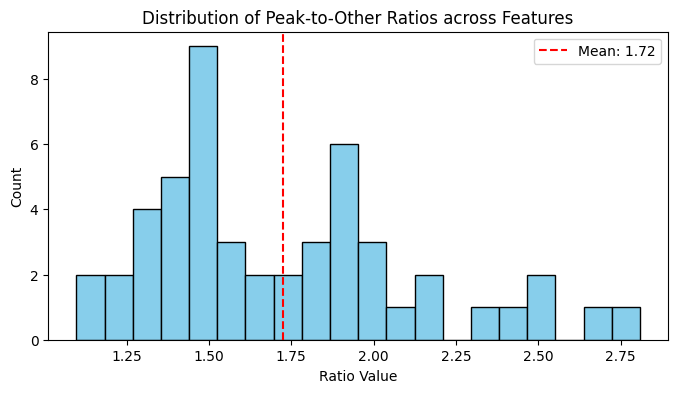

Epoch: 1, Loss: 21.587221, LR: 0.010000
Epoch: 2, Loss: 20.105000, LR: 0.010000
Epoch: 3, Loss: 18.859018, LR: 0.010000
Epoch: 4, Loss: 17.803307, LR: 0.010000
Epoch: 5, Loss: 16.894989, LR: 0.010000
Epoch: 6, Loss: 16.112087, LR: 0.010000
Epoch: 7, Loss: 15.428767, LR: 0.010000
Epoch: 8, Loss: 14.821661, LR: 0.010000
Epoch: 9, Loss: 14.276105, LR: 0.010000
Epoch: 10, Loss: 13.779658, LR: 0.010000
Epoch: 11, Loss: 13.323530, LR: 0.010000
Epoch: 12, Loss: 12.901482, LR: 0.010000
Epoch: 13, Loss: 12.511554, LR: 0.010000
Epoch: 14, Loss: 12.151836, LR: 0.010000
Epoch: 15, Loss: 11.817733, LR: 0.010000
Epoch: 16, Loss: 11.504896, LR: 0.010000
Epoch: 17, Loss: 11.212753, LR: 0.010000
Epoch: 18, Loss: 10.942583, LR: 0.010000
Epoch: 19, Loss: 10.694379, LR: 0.010000
Epoch: 20, Loss: 10.466691, LR: 0.010000
Epoch: 21, Loss: 10.257666, LR: 0.010000
Epoch: 22, Loss: 10.066291, LR: 0.010000
Epoch: 23, Loss: 9.894217, LR: 0.010000
Epoch: 24, Loss: 9.743470, LR: 0.010000
Epoch: 25, Loss: 9.611012, 

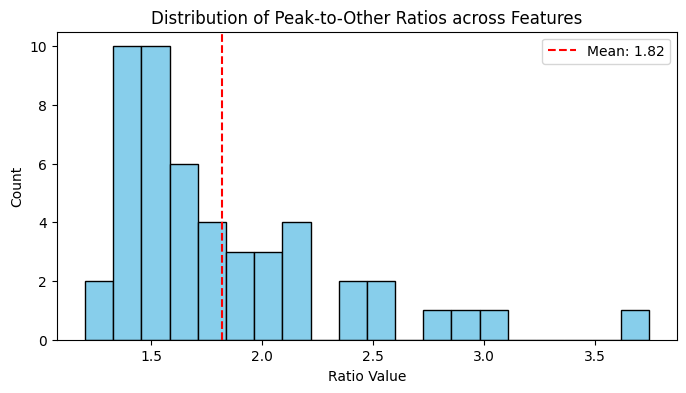

Epoch: 1, Loss: 23.177368, LR: 0.010000
Epoch: 2, Loss: 21.578552, LR: 0.010000
Epoch: 3, Loss: 20.194216, LR: 0.010000
Epoch: 4, Loss: 19.008165, LR: 0.010000
Epoch: 5, Loss: 17.984171, LR: 0.010000
Epoch: 6, Loss: 17.098360, LR: 0.010000
Epoch: 7, Loss: 16.329189, LR: 0.010000
Epoch: 8, Loss: 15.659844, LR: 0.010000
Epoch: 9, Loss: 15.067717, LR: 0.010000
Epoch: 10, Loss: 14.534105, LR: 0.010000
Epoch: 11, Loss: 14.050658, LR: 0.010000
Epoch: 12, Loss: 13.611458, LR: 0.010000
Epoch: 13, Loss: 13.207367, LR: 0.010000
Epoch: 14, Loss: 12.830515, LR: 0.010000
Epoch: 15, Loss: 12.477002, LR: 0.010000
Epoch: 16, Loss: 12.144239, LR: 0.010000
Epoch: 17, Loss: 11.831053, LR: 0.010000
Epoch: 18, Loss: 11.536364, LR: 0.010000
Epoch: 19, Loss: 11.258525, LR: 0.010000
Epoch: 20, Loss: 10.995763, LR: 0.010000
Epoch: 21, Loss: 10.745639, LR: 0.010000
Epoch: 22, Loss: 10.508357, LR: 0.010000
Epoch: 23, Loss: 10.286823, LR: 0.010000
Epoch: 24, Loss: 10.084715, LR: 0.010000
Epoch: 25, Loss: 9.904490

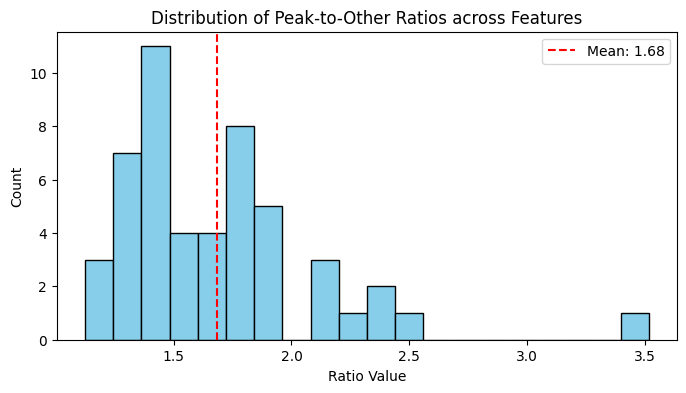

Epoch: 1, Loss: 21.957516, LR: 0.010000
Epoch: 2, Loss: 20.371328, LR: 0.010000
Epoch: 3, Loss: 18.998703, LR: 0.010000
Epoch: 4, Loss: 17.792400, LR: 0.010000
Epoch: 5, Loss: 16.732525, LR: 0.010000
Epoch: 6, Loss: 15.794740, LR: 0.010000
Epoch: 7, Loss: 14.957809, LR: 0.010000
Epoch: 8, Loss: 14.205508, LR: 0.010000
Epoch: 9, Loss: 13.531722, LR: 0.010000
Epoch: 10, Loss: 12.935521, LR: 0.010000
Epoch: 11, Loss: 12.413401, LR: 0.010000
Epoch: 12, Loss: 11.957338, LR: 0.010000
Epoch: 13, Loss: 11.554851, LR: 0.010000
Epoch: 14, Loss: 11.195006, LR: 0.010000
Epoch: 15, Loss: 10.871196, LR: 0.010000
Epoch: 16, Loss: 10.579659, LR: 0.010000
Epoch: 17, Loss: 10.318439, LR: 0.010000
Epoch: 18, Loss: 10.085880, LR: 0.010000
Epoch: 19, Loss: 9.878653, LR: 0.010000
Epoch: 20, Loss: 9.691202, LR: 0.010000
Epoch: 21, Loss: 9.520766, LR: 0.010000
Epoch: 22, Loss: 9.365202, LR: 0.010000
Epoch: 23, Loss: 9.222559, LR: 0.010000
Epoch: 24, Loss: 9.090769, LR: 0.010000
Epoch: 25, Loss: 8.967487, LR: 

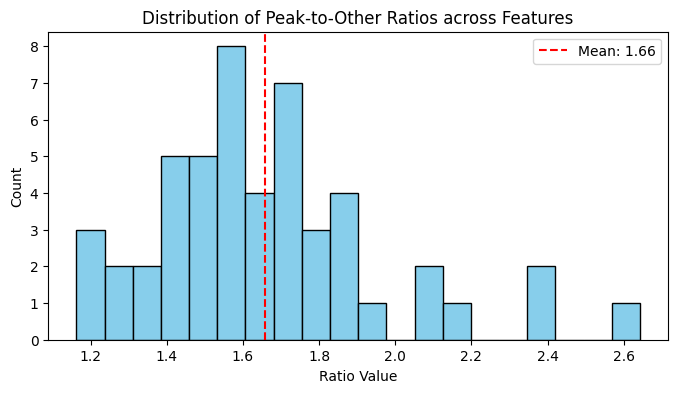

Epoch: 1, Loss: 24.454252, LR: 0.010000
Epoch: 2, Loss: 22.715126, LR: 0.010000
Epoch: 3, Loss: 21.164217, LR: 0.010000
Epoch: 4, Loss: 19.800442, LR: 0.010000
Epoch: 5, Loss: 18.601557, LR: 0.010000
Epoch: 6, Loss: 17.542976, LR: 0.010000
Epoch: 7, Loss: 16.607048, LR: 0.010000
Epoch: 8, Loss: 15.774741, LR: 0.010000
Epoch: 9, Loss: 15.032553, LR: 0.010000
Epoch: 10, Loss: 14.366446, LR: 0.010000
Epoch: 11, Loss: 13.760283, LR: 0.010000
Epoch: 12, Loss: 13.202991, LR: 0.010000
Epoch: 13, Loss: 12.689758, LR: 0.010000
Epoch: 14, Loss: 12.220061, LR: 0.010000
Epoch: 15, Loss: 11.793079, LR: 0.010000
Epoch: 16, Loss: 11.408274, LR: 0.010000
Epoch: 17, Loss: 11.067239, LR: 0.010000
Epoch: 18, Loss: 10.769695, LR: 0.010000
Epoch: 19, Loss: 10.510117, LR: 0.010000
Epoch: 20, Loss: 10.282118, LR: 0.010000
Epoch: 21, Loss: 10.078485, LR: 0.010000
Epoch: 22, Loss: 9.889874, LR: 0.010000
Epoch: 23, Loss: 9.709556, LR: 0.010000
Epoch: 24, Loss: 9.533928, LR: 0.010000
Epoch: 25, Loss: 9.362304, L

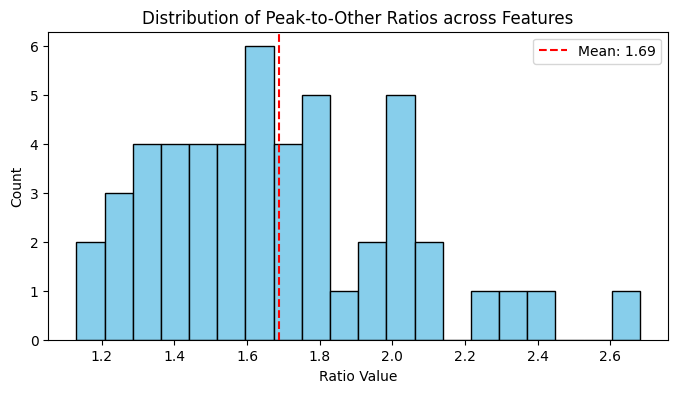

Epoch: 1, Loss: 19.006536, LR: 0.010000
Epoch: 2, Loss: 17.720219, LR: 0.010000
Epoch: 3, Loss: 16.620283, LR: 0.010000
Epoch: 4, Loss: 15.668187, LR: 0.010000
Epoch: 5, Loss: 14.846024, LR: 0.010000
Epoch: 6, Loss: 14.134030, LR: 0.010000
Epoch: 7, Loss: 13.513352, LR: 0.010000
Epoch: 8, Loss: 12.971631, LR: 0.010000
Epoch: 9, Loss: 12.497241, LR: 0.010000
Epoch: 10, Loss: 12.079716, LR: 0.010000
Epoch: 11, Loss: 11.703771, LR: 0.010000
Epoch: 12, Loss: 11.359549, LR: 0.010000
Epoch: 13, Loss: 11.043685, LR: 0.010000
Epoch: 14, Loss: 10.751720, LR: 0.010000
Epoch: 15, Loss: 10.477301, LR: 0.010000
Epoch: 16, Loss: 10.217321, LR: 0.010000
Epoch: 17, Loss: 9.971079, LR: 0.010000
Epoch: 18, Loss: 9.739155, LR: 0.010000
Epoch: 19, Loss: 9.519506, LR: 0.010000
Epoch: 20, Loss: 9.312306, LR: 0.010000
Epoch: 21, Loss: 9.120471, LR: 0.010000
Epoch: 22, Loss: 8.946297, LR: 0.010000
Epoch: 23, Loss: 8.788700, LR: 0.010000
Epoch: 24, Loss: 8.646097, LR: 0.010000
Epoch: 25, Loss: 8.514661, LR: 0.

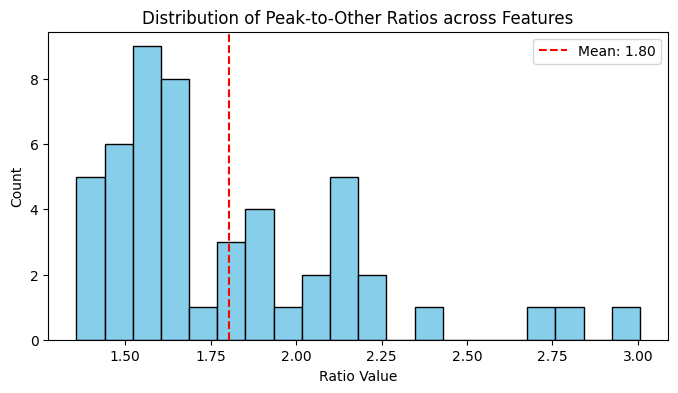

Epoch: 1, Loss: 24.826096, LR: 0.010000
Epoch: 2, Loss: 22.988317, LR: 0.010000
Epoch: 3, Loss: 21.412542, LR: 0.010000
Epoch: 4, Loss: 20.048504, LR: 0.010000
Epoch: 5, Loss: 18.863546, LR: 0.010000
Epoch: 6, Loss: 17.827461, LR: 0.010000
Epoch: 7, Loss: 16.911573, LR: 0.010000
Epoch: 8, Loss: 16.092695, LR: 0.010000
Epoch: 9, Loss: 15.356127, LR: 0.010000
Epoch: 10, Loss: 14.689744, LR: 0.010000
Epoch: 11, Loss: 14.083867, LR: 0.010000
Epoch: 12, Loss: 13.529543, LR: 0.010000
Epoch: 13, Loss: 13.022050, LR: 0.010000
Epoch: 14, Loss: 12.559931, LR: 0.010000
Epoch: 15, Loss: 12.137201, LR: 0.010000
Epoch: 16, Loss: 11.748297, LR: 0.010000
Epoch: 17, Loss: 11.393505, LR: 0.010000
Epoch: 18, Loss: 11.073629, LR: 0.010000
Epoch: 19, Loss: 10.785069, LR: 0.010000
Epoch: 20, Loss: 10.520509, LR: 0.010000
Epoch: 21, Loss: 10.274199, LR: 0.010000
Epoch: 22, Loss: 10.044047, LR: 0.010000
Epoch: 23, Loss: 9.831164, LR: 0.010000
Epoch: 24, Loss: 9.637161, LR: 0.010000
Epoch: 25, Loss: 9.460648, 

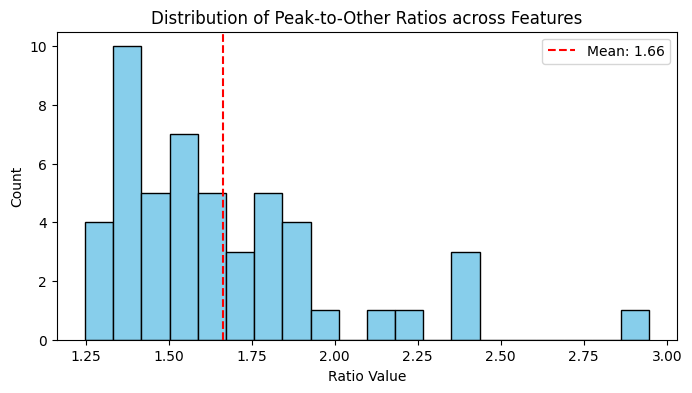

Epoch: 1, Loss: 21.630394, LR: 0.010000
Epoch: 2, Loss: 19.971718, LR: 0.010000
Epoch: 3, Loss: 18.542461, LR: 0.010000
Epoch: 4, Loss: 17.313505, LR: 0.010000
Epoch: 5, Loss: 16.252985, LR: 0.010000
Epoch: 6, Loss: 15.336692, LR: 0.010000
Epoch: 7, Loss: 14.539744, LR: 0.010000
Epoch: 8, Loss: 13.843617, LR: 0.010000
Epoch: 9, Loss: 13.231145, LR: 0.010000
Epoch: 10, Loss: 12.690790, LR: 0.010000
Epoch: 11, Loss: 12.212894, LR: 0.010000
Epoch: 12, Loss: 11.790397, LR: 0.010000
Epoch: 13, Loss: 11.419159, LR: 0.010000
Epoch: 14, Loss: 11.095666, LR: 0.010000
Epoch: 15, Loss: 10.814349, LR: 0.010000
Epoch: 16, Loss: 10.565022, LR: 0.010000
Epoch: 17, Loss: 10.337136, LR: 0.010000
Epoch: 18, Loss: 10.124365, LR: 0.010000
Epoch: 19, Loss: 9.924796, LR: 0.010000
Epoch: 20, Loss: 9.738120, LR: 0.010000
Epoch: 21, Loss: 9.564865, LR: 0.010000
Epoch: 22, Loss: 9.404657, LR: 0.010000
Epoch: 23, Loss: 9.258315, LR: 0.010000
Epoch: 24, Loss: 9.124191, LR: 0.010000
Epoch: 25, Loss: 9.000241, LR: 

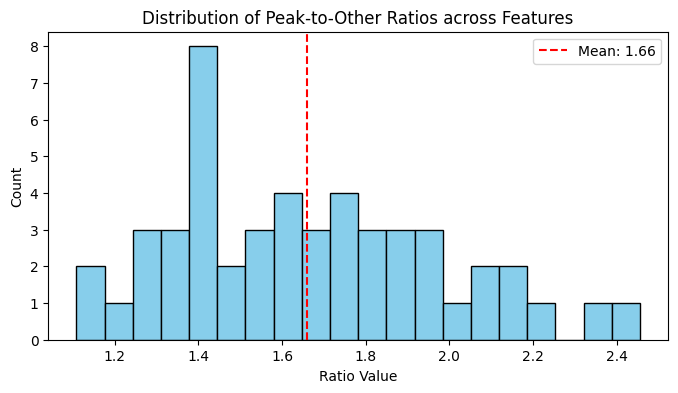

Epoch: 1, Loss: 19.633705, LR: 0.010000
Epoch: 2, Loss: 18.264410, LR: 0.010000
Epoch: 3, Loss: 17.130911, LR: 0.010000
Epoch: 4, Loss: 16.160854, LR: 0.010000
Epoch: 5, Loss: 15.318089, LR: 0.010000
Epoch: 6, Loss: 14.582029, LR: 0.010000
Epoch: 7, Loss: 13.937283, LR: 0.010000
Epoch: 8, Loss: 13.369219, LR: 0.010000
Epoch: 9, Loss: 12.863096, LR: 0.010000
Epoch: 10, Loss: 12.401093, LR: 0.010000
Epoch: 11, Loss: 11.974792, LR: 0.010000
Epoch: 12, Loss: 11.582024, LR: 0.010000
Epoch: 13, Loss: 11.222816, LR: 0.010000
Epoch: 14, Loss: 10.895892, LR: 0.010000
Epoch: 15, Loss: 10.599033, LR: 0.010000
Epoch: 16, Loss: 10.329592, LR: 0.010000
Epoch: 17, Loss: 10.085575, LR: 0.010000
Epoch: 18, Loss: 9.865542, LR: 0.010000
Epoch: 19, Loss: 9.668070, LR: 0.010000
Epoch: 20, Loss: 9.490165, LR: 0.010000
Epoch: 21, Loss: 9.326946, LR: 0.010000
Epoch: 22, Loss: 9.175412, LR: 0.010000
Epoch: 23, Loss: 9.031391, LR: 0.010000
Epoch: 24, Loss: 8.894638, LR: 0.010000
Epoch: 25, Loss: 8.765136, LR: 0

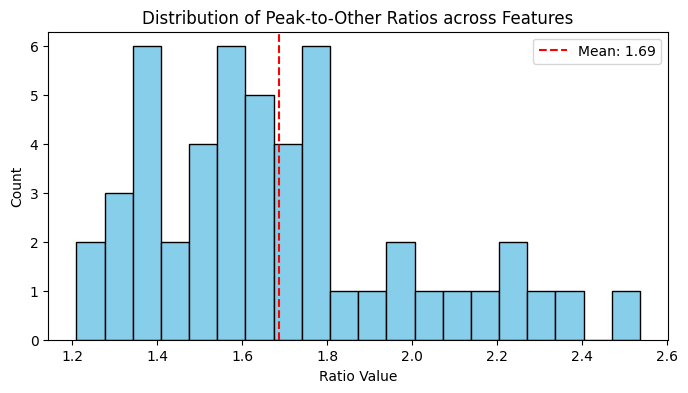

Epoch: 1, Loss: 23.467537, LR: 0.010000
Epoch: 2, Loss: 21.692701, LR: 0.010000
Epoch: 3, Loss: 20.167242, LR: 0.010000
Epoch: 4, Loss: 18.862921, LR: 0.010000
Epoch: 5, Loss: 17.731140, LR: 0.010000
Epoch: 6, Loss: 16.738815, LR: 0.010000
Epoch: 7, Loss: 15.865934, LR: 0.010000
Epoch: 8, Loss: 15.096153, LR: 0.010000
Epoch: 9, Loss: 14.411221, LR: 0.010000
Epoch: 10, Loss: 13.793700, LR: 0.010000
Epoch: 11, Loss: 13.231670, LR: 0.010000
Epoch: 12, Loss: 12.716299, LR: 0.010000
Epoch: 13, Loss: 12.241181, LR: 0.010000
Epoch: 14, Loss: 11.804090, LR: 0.010000
Epoch: 15, Loss: 11.403708, LR: 0.010000
Epoch: 16, Loss: 11.036753, LR: 0.010000
Epoch: 17, Loss: 10.702454, LR: 0.010000
Epoch: 18, Loss: 10.401608, LR: 0.010000
Epoch: 19, Loss: 10.133486, LR: 0.010000
Epoch: 20, Loss: 9.894498, LR: 0.010000
Epoch: 21, Loss: 9.681035, LR: 0.010000
Epoch: 22, Loss: 9.488422, LR: 0.010000
Epoch: 23, Loss: 9.312419, LR: 0.010000
Epoch: 24, Loss: 9.149234, LR: 0.010000
Epoch: 25, Loss: 8.996094, LR:

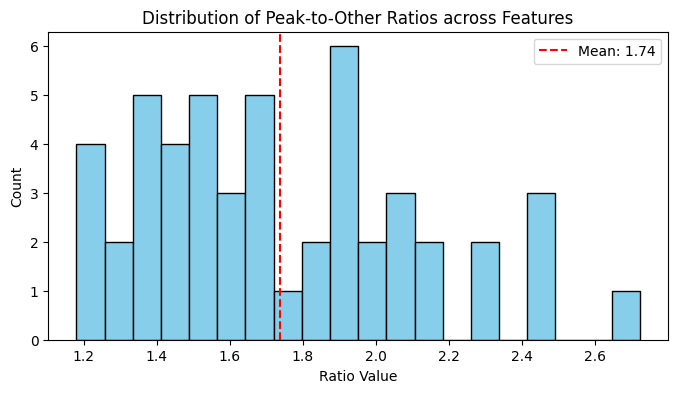


--- Testing Factor: 2 ---
Epoch: 1, Loss: 33.187130, LR: 0.010000
Epoch: 2, Loss: 30.120523, LR: 0.010000
Epoch: 3, Loss: 27.590401, LR: 0.010000
Epoch: 4, Loss: 25.531603, LR: 0.010000
Epoch: 5, Loss: 23.867523, LR: 0.010000
Epoch: 6, Loss: 22.528135, LR: 0.010000
Epoch: 7, Loss: 21.454906, LR: 0.010000
Epoch: 8, Loss: 20.597097, LR: 0.010000
Epoch: 9, Loss: 19.909891, LR: 0.010000
Epoch: 10, Loss: 19.358007, LR: 0.010000
Epoch: 11, Loss: 18.912695, LR: 0.010000
Epoch: 12, Loss: 18.551085, LR: 0.010000
Epoch: 13, Loss: 18.255997, LR: 0.010000
Epoch: 14, Loss: 18.013445, LR: 0.010000
Epoch: 15, Loss: 17.810841, LR: 0.010000
Epoch: 16, Loss: 17.637173, LR: 0.010000
Epoch: 17, Loss: 17.483522, LR: 0.010000
Epoch: 18, Loss: 17.343418, LR: 0.010000
Epoch: 19, Loss: 17.212421, LR: 0.010000
Epoch: 20, Loss: 17.086870, LR: 0.010000
Epoch: 21, Loss: 16.963158, LR: 0.010000
Epoch: 22, Loss: 16.837910, LR: 0.010000
Epoch: 23, Loss: 16.708475, LR: 0.010000
Epoch: 24, Loss: 16.573294, LR: 0.01000

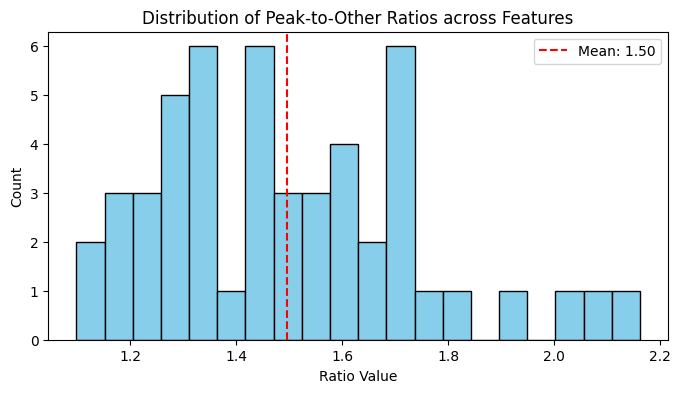

Epoch: 1, Loss: 33.114109, LR: 0.010000
Epoch: 2, Loss: 30.038464, LR: 0.010000
Epoch: 3, Loss: 27.467354, LR: 0.010000
Epoch: 4, Loss: 25.336697, LR: 0.010000
Epoch: 5, Loss: 23.579412, LR: 0.010000
Epoch: 6, Loss: 22.133633, LR: 0.010000
Epoch: 7, Loss: 20.950281, LR: 0.010000
Epoch: 8, Loss: 19.988609, LR: 0.010000
Epoch: 9, Loss: 19.213539, LR: 0.010000
Epoch: 10, Loss: 18.592884, LR: 0.010000
Epoch: 11, Loss: 18.098392, LR: 0.010000
Epoch: 12, Loss: 17.706228, LR: 0.010000
Epoch: 13, Loss: 17.396015, LR: 0.010000
Epoch: 14, Loss: 17.150501, LR: 0.010000
Epoch: 15, Loss: 16.954926, LR: 0.010000
Epoch: 16, Loss: 16.796961, LR: 0.010000
Epoch: 17, Loss: 16.666126, LR: 0.010000
Epoch: 18, Loss: 16.553415, LR: 0.010000
Epoch: 19, Loss: 16.451338, LR: 0.010000
Epoch: 20, Loss: 16.353792, LR: 0.010000
Epoch: 21, Loss: 16.256069, LR: 0.010000
Epoch: 22, Loss: 16.155081, LR: 0.010000
Epoch: 23, Loss: 16.049385, LR: 0.010000
Epoch: 24, Loss: 15.938822, LR: 0.010000
Epoch: 25, Loss: 15.82391

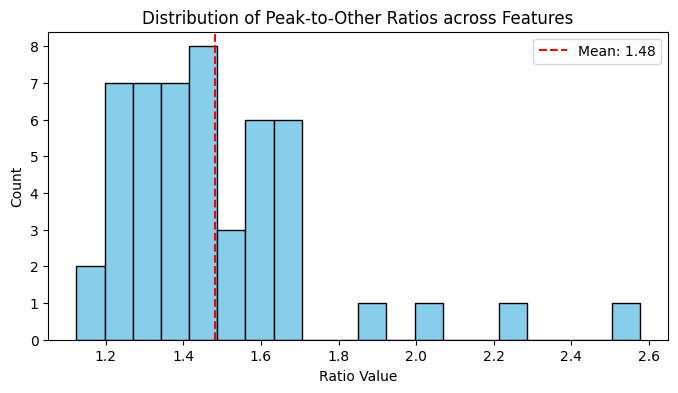

Epoch: 1, Loss: 37.708084, LR: 0.010000
Epoch: 2, Loss: 34.068138, LR: 0.010000
Epoch: 3, Loss: 31.059271, LR: 0.010000
Epoch: 4, Loss: 28.580732, LR: 0.010000
Epoch: 5, Loss: 26.547525, LR: 0.010000
Epoch: 6, Loss: 24.889904, LR: 0.010000
Epoch: 7, Loss: 23.541660, LR: 0.010000
Epoch: 8, Loss: 22.445217, LR: 0.010000
Epoch: 9, Loss: 21.554510, LR: 0.010000
Epoch: 10, Loss: 20.830091, LR: 0.010000
Epoch: 11, Loss: 20.236235, LR: 0.010000
Epoch: 12, Loss: 19.742632, LR: 0.010000
Epoch: 13, Loss: 19.326254, LR: 0.010000
Epoch: 14, Loss: 18.970528, LR: 0.010000
Epoch: 15, Loss: 18.663607, LR: 0.010000
Epoch: 16, Loss: 18.396753, LR: 0.010000
Epoch: 17, Loss: 18.162781, LR: 0.010000
Epoch: 18, Loss: 17.955433, LR: 0.010000
Epoch: 19, Loss: 17.769331, LR: 0.010000
Epoch: 20, Loss: 17.600103, LR: 0.010000
Epoch: 21, Loss: 17.444229, LR: 0.010000
Epoch: 22, Loss: 17.298483, LR: 0.010000
Epoch: 23, Loss: 17.159630, LR: 0.010000
Epoch: 24, Loss: 17.024519, LR: 0.010000
Epoch: 25, Loss: 16.89037

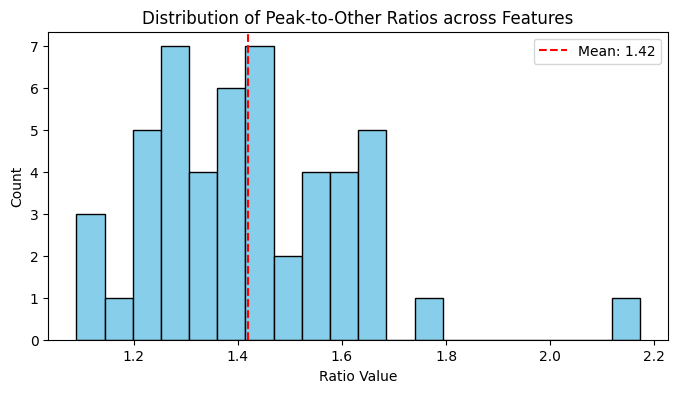

Epoch: 1, Loss: 35.055759, LR: 0.010000
Epoch: 2, Loss: 31.791416, LR: 0.010000
Epoch: 3, Loss: 29.061665, LR: 0.010000
Epoch: 4, Loss: 26.817430, LR: 0.010000
Epoch: 5, Loss: 24.989250, LR: 0.010000
Epoch: 6, Loss: 23.510397, LR: 0.010000
Epoch: 7, Loss: 22.325283, LR: 0.010000
Epoch: 8, Loss: 21.383537, LR: 0.010000
Epoch: 9, Loss: 20.639215, LR: 0.010000
Epoch: 10, Loss: 20.051306, LR: 0.010000
Epoch: 11, Loss: 19.586269, LR: 0.010000
Epoch: 12, Loss: 19.217211, LR: 0.010000
Epoch: 13, Loss: 18.920671, LR: 0.010000
Epoch: 14, Loss: 18.676245, LR: 0.010000
Epoch: 15, Loss: 18.466900, LR: 0.010000
Epoch: 16, Loss: 18.279800, LR: 0.010000
Epoch: 17, Loss: 18.106344, LR: 0.010000
Epoch: 18, Loss: 17.941189, LR: 0.010000
Epoch: 19, Loss: 17.781334, LR: 0.010000
Epoch: 20, Loss: 17.625473, LR: 0.010000
Epoch: 21, Loss: 17.473181, LR: 0.010000
Epoch: 22, Loss: 17.324133, LR: 0.010000
Epoch: 23, Loss: 17.177879, LR: 0.010000
Epoch: 24, Loss: 17.033960, LR: 0.010000
Epoch: 25, Loss: 16.89213

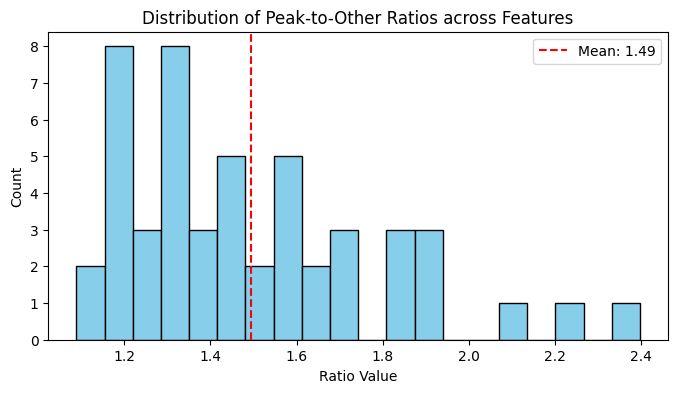

Epoch: 1, Loss: 36.714066, LR: 0.010000
Epoch: 2, Loss: 33.447983, LR: 0.010000
Epoch: 3, Loss: 30.721405, LR: 0.010000
Epoch: 4, Loss: 28.443846, LR: 0.010000
Epoch: 5, Loss: 26.563614, LR: 0.010000
Epoch: 6, Loss: 25.027485, LR: 0.010000
Epoch: 7, Loss: 23.778898, LR: 0.010000
Epoch: 8, Loss: 22.765541, LR: 0.010000
Epoch: 9, Loss: 21.941879, LR: 0.010000
Epoch: 10, Loss: 21.268595, LR: 0.010000
Epoch: 11, Loss: 20.713648, LR: 0.010000
Epoch: 12, Loss: 20.252794, LR: 0.010000
Epoch: 13, Loss: 19.867758, LR: 0.010000
Epoch: 14, Loss: 19.543024, LR: 0.010000
Epoch: 15, Loss: 19.265339, LR: 0.010000
Epoch: 16, Loss: 19.023798, LR: 0.010000
Epoch: 17, Loss: 18.809340, LR: 0.010000
Epoch: 18, Loss: 18.614712, LR: 0.010000
Epoch: 19, Loss: 18.434753, LR: 0.010000
Epoch: 20, Loss: 18.265938, LR: 0.010000
Epoch: 21, Loss: 18.105627, LR: 0.010000
Epoch: 22, Loss: 17.951437, LR: 0.010000
Epoch: 23, Loss: 17.800886, LR: 0.010000
Epoch: 24, Loss: 17.651445, LR: 0.010000
Epoch: 25, Loss: 17.50103

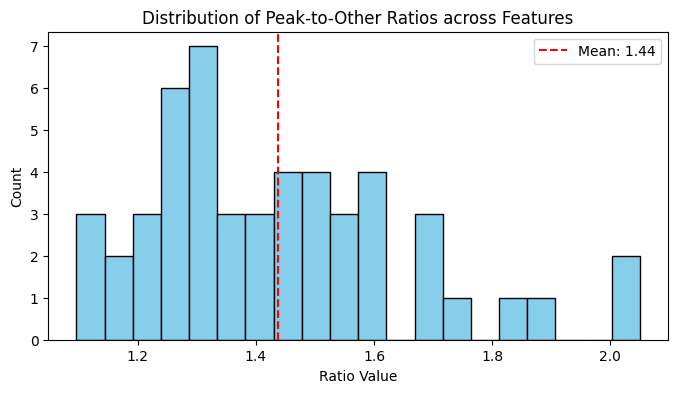

Epoch: 1, Loss: 34.671272, LR: 0.010000
Epoch: 2, Loss: 31.607464, LR: 0.010000
Epoch: 3, Loss: 29.043144, LR: 0.010000
Epoch: 4, Loss: 26.933350, LR: 0.010000
Epoch: 5, Loss: 25.221180, LR: 0.010000
Epoch: 6, Loss: 23.838610, LR: 0.010000
Epoch: 7, Loss: 22.722834, LR: 0.010000
Epoch: 8, Loss: 21.819305, LR: 0.010000
Epoch: 9, Loss: 21.082054, LR: 0.010000
Epoch: 10, Loss: 20.476700, LR: 0.010000
Epoch: 11, Loss: 19.977287, LR: 0.010000
Epoch: 12, Loss: 19.561487, LR: 0.010000
Epoch: 13, Loss: 19.211647, LR: 0.010000
Epoch: 14, Loss: 18.914206, LR: 0.010000
Epoch: 15, Loss: 18.658552, LR: 0.010000
Epoch: 16, Loss: 18.435785, LR: 0.010000
Epoch: 17, Loss: 18.238306, LR: 0.010000
Epoch: 18, Loss: 18.059561, LR: 0.010000
Epoch: 19, Loss: 17.894077, LR: 0.010000
Epoch: 20, Loss: 17.737730, LR: 0.010000
Epoch: 21, Loss: 17.587399, LR: 0.010000
Epoch: 22, Loss: 17.440481, LR: 0.010000
Epoch: 23, Loss: 17.294674, LR: 0.010000
Epoch: 24, Loss: 17.148071, LR: 0.010000
Epoch: 25, Loss: 16.99944

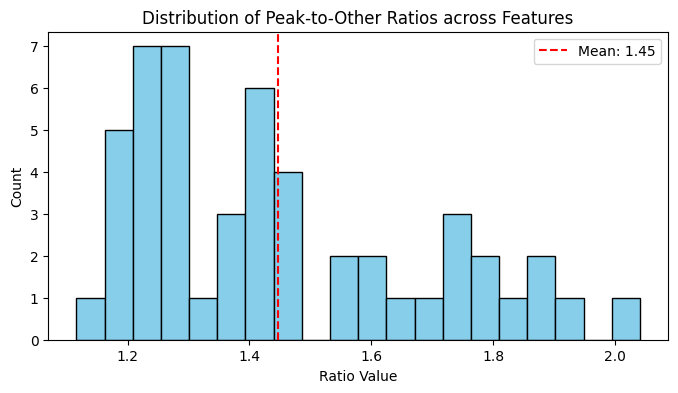

Epoch: 1, Loss: 37.746037, LR: 0.010000
Epoch: 2, Loss: 34.248795, LR: 0.010000
Epoch: 3, Loss: 31.309999, LR: 0.010000
Epoch: 4, Loss: 28.868298, LR: 0.010000
Epoch: 5, Loss: 26.854679, LR: 0.010000
Epoch: 6, Loss: 25.213505, LR: 0.010000
Epoch: 7, Loss: 23.895336, LR: 0.010000
Epoch: 8, Loss: 22.849306, LR: 0.010000
Epoch: 9, Loss: 22.025940, LR: 0.010000
Epoch: 10, Loss: 21.380707, LR: 0.010000
Epoch: 11, Loss: 20.873653, LR: 0.010000
Epoch: 12, Loss: 20.469658, LR: 0.010000
Epoch: 13, Loss: 20.139807, LR: 0.010000
Epoch: 14, Loss: 19.860996, LR: 0.010000
Epoch: 15, Loss: 19.615288, LR: 0.010000
Epoch: 16, Loss: 19.389238, LR: 0.010000
Epoch: 17, Loss: 19.173073, LR: 0.010000
Epoch: 18, Loss: 18.960030, LR: 0.010000
Epoch: 19, Loss: 18.745722, LR: 0.010000
Epoch: 20, Loss: 18.527521, LR: 0.010000
Epoch: 21, Loss: 18.304214, LR: 0.010000
Epoch: 22, Loss: 18.076162, LR: 0.010000
Epoch: 23, Loss: 17.844830, LR: 0.010000
Epoch: 24, Loss: 17.611822, LR: 0.010000
Epoch: 25, Loss: 17.37864

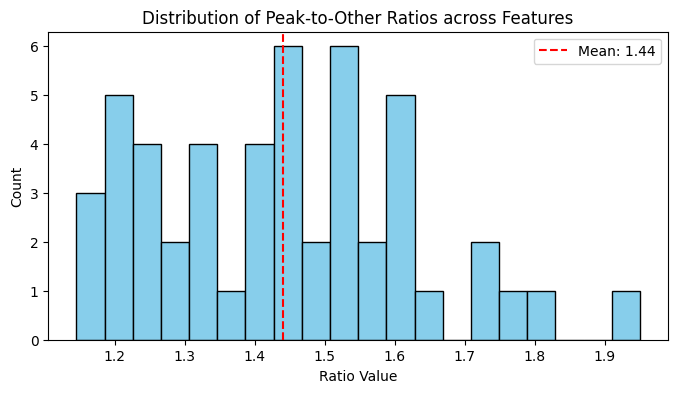

Epoch: 1, Loss: 33.131969, LR: 0.010000
Epoch: 2, Loss: 29.988075, LR: 0.010000
Epoch: 3, Loss: 27.388430, LR: 0.010000
Epoch: 4, Loss: 25.258438, LR: 0.010000
Epoch: 5, Loss: 23.528584, LR: 0.010000
Epoch: 6, Loss: 22.138388, LR: 0.010000
Epoch: 7, Loss: 21.028908, LR: 0.010000
Epoch: 8, Loss: 20.146122, LR: 0.010000
Epoch: 9, Loss: 19.445091, LR: 0.010000
Epoch: 10, Loss: 18.887081, LR: 0.010000
Epoch: 11, Loss: 18.439627, LR: 0.010000
Epoch: 12, Loss: 18.077391, LR: 0.010000
Epoch: 13, Loss: 17.781267, LR: 0.010000
Epoch: 14, Loss: 17.536741, LR: 0.010000
Epoch: 15, Loss: 17.332098, LR: 0.010000
Epoch: 16, Loss: 17.157845, LR: 0.010000
Epoch: 17, Loss: 17.006655, LR: 0.010000
Epoch: 18, Loss: 16.872896, LR: 0.010000
Epoch: 19, Loss: 16.752455, LR: 0.010000
Epoch: 20, Loss: 16.642250, LR: 0.010000
Epoch: 21, Loss: 16.539581, LR: 0.010000
Epoch: 22, Loss: 16.441835, LR: 0.010000
Epoch: 23, Loss: 16.346508, LR: 0.010000
Epoch: 24, Loss: 16.251318, LR: 0.010000
Epoch: 25, Loss: 16.15447

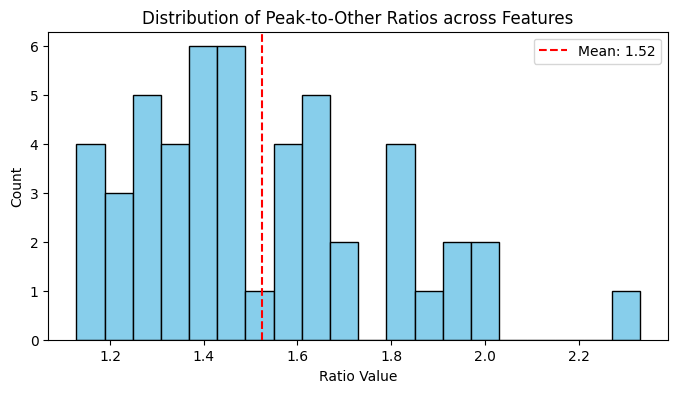

Epoch: 1, Loss: 39.084999, LR: 0.010000
Epoch: 2, Loss: 35.386078, LR: 0.010000
Epoch: 3, Loss: 32.265369, LR: 0.010000
Epoch: 4, Loss: 29.653116, LR: 0.010000
Epoch: 5, Loss: 27.474894, LR: 0.010000
Epoch: 6, Loss: 25.666063, LR: 0.010000
Epoch: 7, Loss: 24.165493, LR: 0.010000
Epoch: 8, Loss: 22.922041, LR: 0.010000
Epoch: 9, Loss: 21.893967, LR: 0.010000
Epoch: 10, Loss: 21.045376, LR: 0.010000
Epoch: 11, Loss: 20.345520, LR: 0.010000
Epoch: 12, Loss: 19.768642, LR: 0.010000
Epoch: 13, Loss: 19.293037, LR: 0.010000
Epoch: 14, Loss: 18.900436, LR: 0.010000
Epoch: 15, Loss: 18.575937, LR: 0.010000
Epoch: 16, Loss: 18.307508, LR: 0.010000
Epoch: 17, Loss: 18.084707, LR: 0.010000
Epoch: 18, Loss: 17.897726, LR: 0.010000
Epoch: 19, Loss: 17.736832, LR: 0.010000
Epoch: 20, Loss: 17.592878, LR: 0.010000
Epoch: 21, Loss: 17.458452, LR: 0.010000
Epoch: 22, Loss: 17.328148, LR: 0.010000
Epoch: 23, Loss: 17.198084, LR: 0.010000
Epoch: 24, Loss: 17.065393, LR: 0.010000
Epoch: 25, Loss: 16.92797

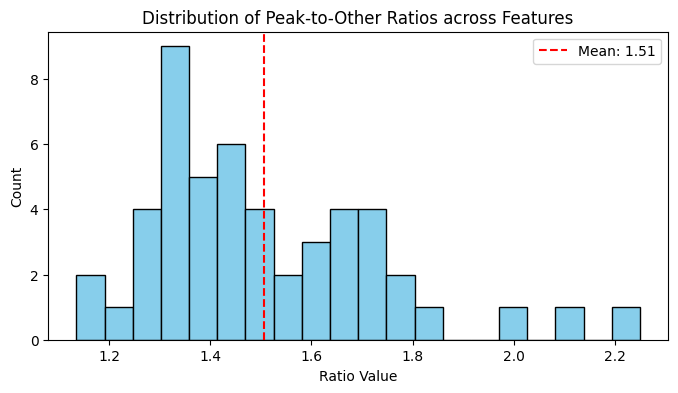

Epoch: 1, Loss: 36.353836, LR: 0.010000
Epoch: 2, Loss: 32.981987, LR: 0.010000
Epoch: 3, Loss: 30.176336, LR: 0.010000
Epoch: 4, Loss: 27.853388, LR: 0.010000
Epoch: 5, Loss: 25.940876, LR: 0.010000
Epoch: 6, Loss: 24.370600, LR: 0.010000
Epoch: 7, Loss: 23.086126, LR: 0.010000
Epoch: 8, Loss: 22.038212, LR: 0.010000
Epoch: 9, Loss: 21.184290, LR: 0.010000
Epoch: 10, Loss: 20.487209, LR: 0.010000
Epoch: 11, Loss: 19.916170, LR: 0.010000
Epoch: 12, Loss: 19.446110, LR: 0.010000
Epoch: 13, Loss: 19.056398, LR: 0.010000
Epoch: 14, Loss: 18.730175, LR: 0.010000
Epoch: 15, Loss: 18.453602, LR: 0.010000
Epoch: 16, Loss: 18.215027, LR: 0.010000
Epoch: 17, Loss: 18.004616, LR: 0.010000
Epoch: 18, Loss: 17.814247, LR: 0.010000
Epoch: 19, Loss: 17.637321, LR: 0.010000
Epoch: 20, Loss: 17.468704, LR: 0.010000
Epoch: 21, Loss: 17.304407, LR: 0.010000
Epoch: 22, Loss: 17.141558, LR: 0.010000
Epoch: 23, Loss: 16.978498, LR: 0.010000
Epoch: 24, Loss: 16.814648, LR: 0.010000
Epoch: 25, Loss: 16.64997

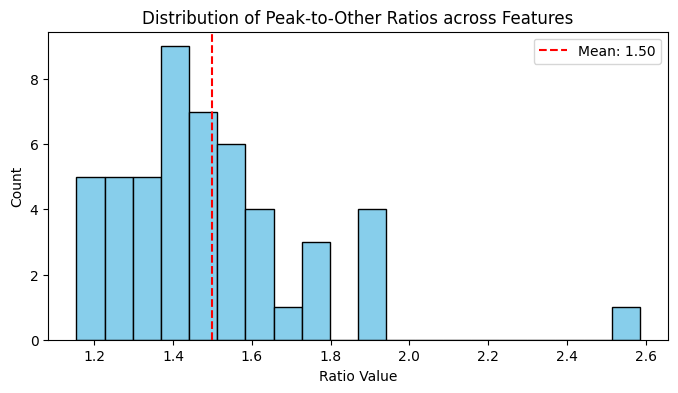


--- Testing Factor: 3 ---
Epoch: 1, Loss: 41.774967, LR: 0.010000
Epoch: 2, Loss: 37.443195, LR: 0.010000
Epoch: 3, Loss: 33.948593, LR: 0.010000
Epoch: 4, Loss: 31.184526, LR: 0.010000
Epoch: 5, Loss: 29.031086, LR: 0.010000
Epoch: 6, Loss: 27.380205, LR: 0.010000
Epoch: 7, Loss: 26.140715, LR: 0.010000
Epoch: 8, Loss: 25.235445, LR: 0.010000
Epoch: 9, Loss: 24.594530, LR: 0.010000
Epoch: 10, Loss: 24.155882, LR: 0.010000
Epoch: 11, Loss: 23.868225, LR: 0.010000
Epoch: 12, Loss: 23.690348, LR: 0.010000
Epoch: 13, Loss: 23.587851, LR: 0.010000
Epoch: 14, Loss: 23.532230, LR: 0.010000
Epoch: 15, Loss: 23.500973, LR: 0.010000
Epoch: 16, Loss: 23.477308, LR: 0.010000
Epoch: 17, Loss: 23.449114, LR: 0.010000
Epoch: 18, Loss: 23.407328, LR: 0.010000
Epoch: 19, Loss: 23.344822, LR: 0.010000
Epoch: 20, Loss: 23.256237, LR: 0.010000
Epoch: 21, Loss: 23.138231, LR: 0.010000
Epoch: 22, Loss: 22.989466, LR: 0.010000
Epoch: 23, Loss: 22.810272, LR: 0.010000
Epoch: 24, Loss: 22.602264, LR: 0.01000

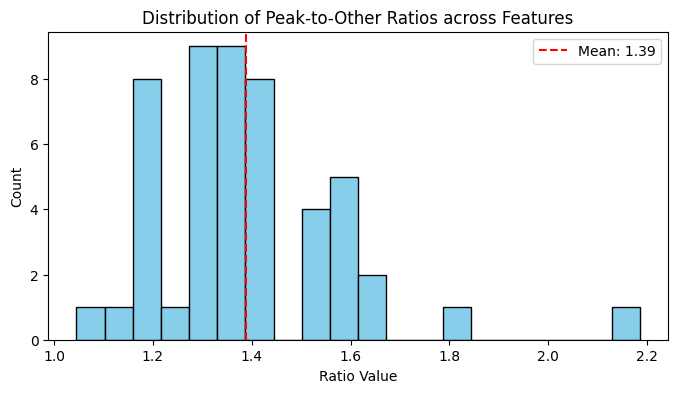

Epoch: 1, Loss: 48.630276, LR: 0.010000
Epoch: 2, Loss: 43.632881, LR: 0.010000
Epoch: 3, Loss: 39.659832, LR: 0.010000
Epoch: 4, Loss: 36.538925, LR: 0.010000
Epoch: 5, Loss: 34.130363, LR: 0.010000
Epoch: 6, Loss: 32.307655, LR: 0.010000
Epoch: 7, Loss: 30.962086, LR: 0.010000
Epoch: 8, Loss: 29.997921, LR: 0.010000
Epoch: 9, Loss: 29.324703, LR: 0.010000
Epoch: 10, Loss: 28.865105, LR: 0.010000
Epoch: 11, Loss: 28.556746, LR: 0.010000
Epoch: 12, Loss: 28.348919, LR: 0.010000
Epoch: 13, Loss: 28.200758, LR: 0.010000
Epoch: 14, Loss: 28.080175, LR: 0.010000
Epoch: 15, Loss: 27.962809, LR: 0.010000
Epoch: 16, Loss: 27.830862, LR: 0.010000
Epoch: 17, Loss: 27.673014, LR: 0.010000
Epoch: 18, Loss: 27.484434, LR: 0.010000
Epoch: 19, Loss: 27.265173, LR: 0.010000
Epoch: 20, Loss: 27.017740, LR: 0.010000
Epoch: 21, Loss: 26.745239, LR: 0.010000
Epoch: 22, Loss: 26.450649, LR: 0.010000
Epoch: 23, Loss: 26.136713, LR: 0.010000
Epoch: 24, Loss: 25.806025, LR: 0.010000
Epoch: 25, Loss: 25.46089

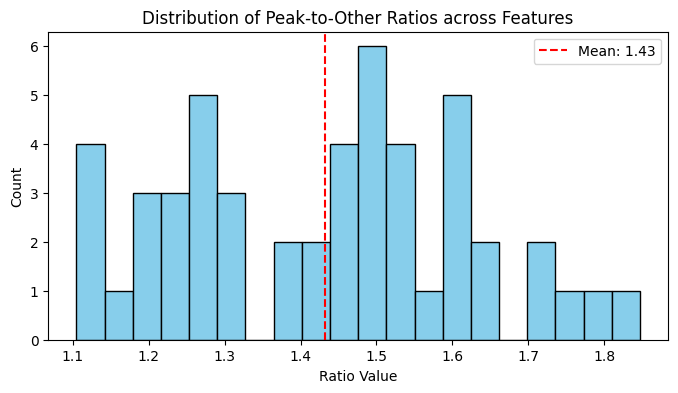

Epoch: 1, Loss: 39.518963, LR: 0.010000
Epoch: 2, Loss: 35.411194, LR: 0.010000
Epoch: 3, Loss: 32.171982, LR: 0.010000
Epoch: 4, Loss: 29.658873, LR: 0.010000
Epoch: 5, Loss: 27.764465, LR: 0.010000
Epoch: 6, Loss: 26.381802, LR: 0.010000
Epoch: 7, Loss: 25.405287, LR: 0.010000
Epoch: 8, Loss: 24.742487, LR: 0.010000
Epoch: 9, Loss: 24.312386, LR: 0.010000
Epoch: 10, Loss: 24.048616, LR: 0.010000
Epoch: 11, Loss: 23.897398, LR: 0.010000
Epoch: 12, Loss: 23.816261, LR: 0.010000
Epoch: 13, Loss: 23.772621, LR: 0.010000
Epoch: 14, Loss: 23.742050, LR: 0.010000
Epoch: 15, Loss: 23.705933, LR: 0.010000
Epoch: 16, Loss: 23.650402, LR: 0.010000
Epoch: 17, Loss: 23.566326, LR: 0.010000
Epoch: 18, Loss: 23.449028, LR: 0.010000
Epoch: 19, Loss: 23.297396, LR: 0.010000
Epoch: 20, Loss: 23.112879, LR: 0.010000
Epoch: 21, Loss: 22.898411, LR: 0.010000
Epoch: 22, Loss: 22.657602, LR: 0.010000
Epoch: 23, Loss: 22.394321, LR: 0.010000
Epoch: 24, Loss: 22.112455, LR: 0.010000
Epoch: 25, Loss: 21.81571

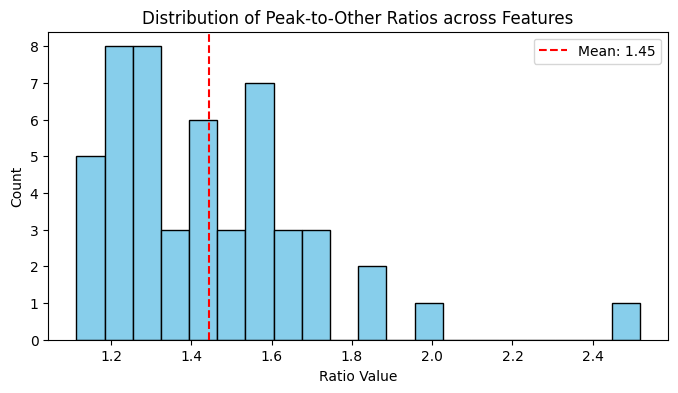

Epoch: 1, Loss: 41.248959, LR: 0.010000
Epoch: 2, Loss: 37.263538, LR: 0.010000
Epoch: 3, Loss: 34.144875, LR: 0.010000
Epoch: 4, Loss: 31.709833, LR: 0.010000
Epoch: 5, Loss: 29.850151, LR: 0.010000
Epoch: 6, Loss: 28.466125, LR: 0.010000
Epoch: 7, Loss: 27.467077, LR: 0.010000
Epoch: 8, Loss: 26.771770, LR: 0.010000
Epoch: 9, Loss: 26.305490, LR: 0.010000
Epoch: 10, Loss: 26.005169, LR: 0.010000
Epoch: 11, Loss: 25.818512, LR: 0.010000
Epoch: 12, Loss: 25.704536, LR: 0.010000
Epoch: 13, Loss: 25.631788, LR: 0.010000
Epoch: 14, Loss: 25.576780, LR: 0.010000
Epoch: 15, Loss: 25.522633, LR: 0.010000
Epoch: 16, Loss: 25.457546, LR: 0.010000
Epoch: 17, Loss: 25.373142, LR: 0.010000
Epoch: 18, Loss: 25.263393, LR: 0.010000
Epoch: 19, Loss: 25.123957, LR: 0.010000
Epoch: 20, Loss: 24.951853, LR: 0.010000
Epoch: 21, Loss: 24.745701, LR: 0.010000
Epoch: 22, Loss: 24.506012, LR: 0.010000
Epoch: 23, Loss: 24.234919, LR: 0.010000
Epoch: 24, Loss: 23.935246, LR: 0.010000
Epoch: 25, Loss: 23.61023

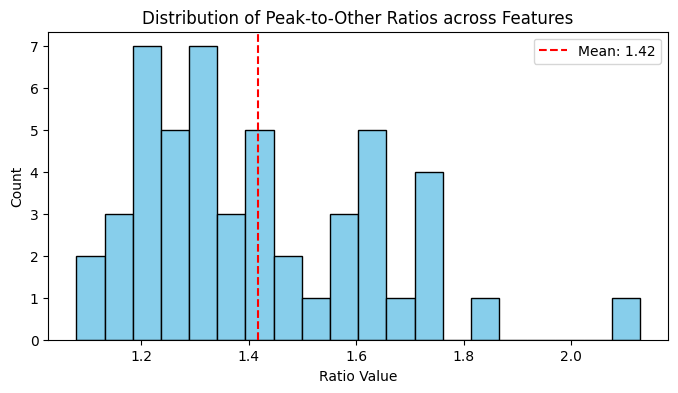

Epoch: 1, Loss: 40.497559, LR: 0.010000
Epoch: 2, Loss: 36.439213, LR: 0.010000
Epoch: 3, Loss: 33.219704, LR: 0.010000
Epoch: 4, Loss: 30.709459, LR: 0.010000
Epoch: 5, Loss: 28.796618, LR: 0.010000
Epoch: 6, Loss: 27.371696, LR: 0.010000
Epoch: 7, Loss: 26.338589, LR: 0.010000
Epoch: 8, Loss: 25.615768, LR: 0.010000
Epoch: 9, Loss: 25.133047, LR: 0.010000
Epoch: 10, Loss: 24.830544, LR: 0.010000
Epoch: 11, Loss: 24.658386, LR: 0.010000
Epoch: 12, Loss: 24.573799, LR: 0.010000
Epoch: 13, Loss: 24.540686, LR: 0.010000
Epoch: 14, Loss: 24.529438, LR: 0.010000
Epoch: 15, Loss: 24.516766, LR: 0.010000
Epoch: 16, Loss: 24.485411, LR: 0.010000
Epoch: 17, Loss: 24.423132, LR: 0.010000
Epoch: 18, Loss: 24.322166, LR: 0.010000
Epoch: 19, Loss: 24.178749, LR: 0.010000
Epoch: 20, Loss: 23.992107, LR: 0.010000
Epoch: 21, Loss: 23.763657, LR: 0.010000
Epoch: 22, Loss: 23.496586, LR: 0.010000
Epoch: 23, Loss: 23.195723, LR: 0.010000
Epoch: 24, Loss: 22.867182, LR: 0.010000
Epoch: 25, Loss: 22.51769

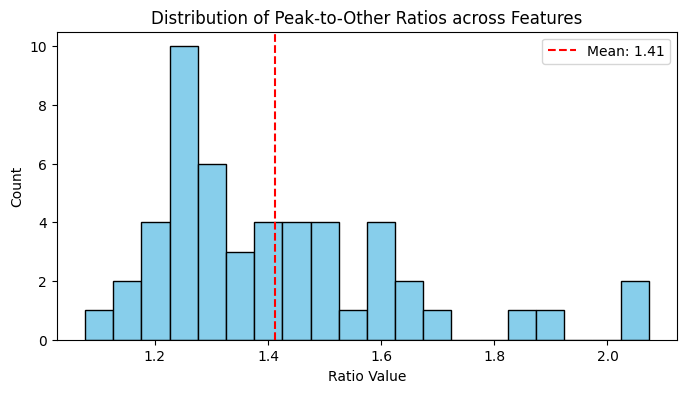

Epoch: 1, Loss: 42.440697, LR: 0.010000
Epoch: 2, Loss: 37.935154, LR: 0.010000
Epoch: 3, Loss: 34.282581, LR: 0.010000
Epoch: 4, Loss: 31.377905, LR: 0.010000
Epoch: 5, Loss: 29.112373, LR: 0.010000
Epoch: 6, Loss: 27.389410, LR: 0.010000
Epoch: 7, Loss: 26.115408, LR: 0.010000
Epoch: 8, Loss: 25.204983, LR: 0.010000
Epoch: 9, Loss: 24.582556, LR: 0.010000
Epoch: 10, Loss: 24.181705, LR: 0.010000
Epoch: 11, Loss: 23.943674, LR: 0.010000
Epoch: 12, Loss: 23.817411, LR: 0.010000
Epoch: 13, Loss: 23.759871, LR: 0.010000
Epoch: 14, Loss: 23.736748, LR: 0.010000
Epoch: 15, Loss: 23.722040, LR: 0.010000
Epoch: 16, Loss: 23.696695, LR: 0.010000
Epoch: 17, Loss: 23.647137, LR: 0.010000
Epoch: 18, Loss: 23.564423, LR: 0.010000
Epoch: 19, Loss: 23.443935, LR: 0.010000
Epoch: 20, Loss: 23.284769, LR: 0.010000
Epoch: 21, Loss: 23.088686, LR: 0.010000
Epoch: 22, Loss: 22.859245, LR: 0.010000
Epoch: 23, Loss: 22.600998, LR: 0.010000
Epoch: 24, Loss: 22.318922, LR: 0.010000
Epoch: 25, Loss: 22.01813

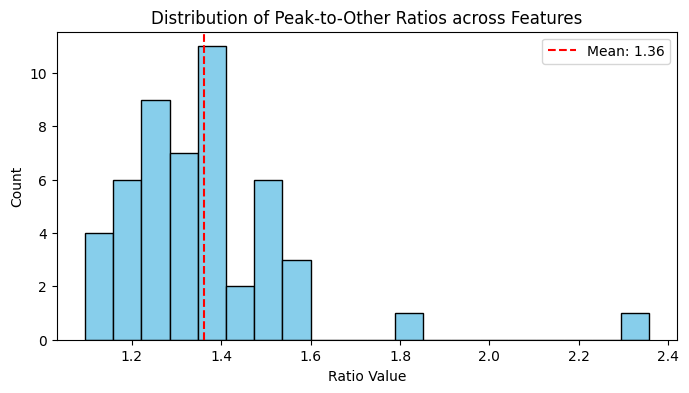

Epoch: 1, Loss: 43.912952, LR: 0.010000
Epoch: 2, Loss: 39.331924, LR: 0.010000
Epoch: 3, Loss: 35.583725, LR: 0.010000
Epoch: 4, Loss: 32.578014, LR: 0.010000
Epoch: 5, Loss: 30.209921, LR: 0.010000
Epoch: 6, Loss: 28.380507, LR: 0.010000
Epoch: 7, Loss: 26.999809, LR: 0.010000
Epoch: 8, Loss: 25.985415, LR: 0.010000
Epoch: 9, Loss: 25.259962, LR: 0.010000
Epoch: 10, Loss: 24.755693, LR: 0.010000
Epoch: 11, Loss: 24.415163, LR: 0.010000
Epoch: 12, Loss: 24.190132, LR: 0.010000
Epoch: 13, Loss: 24.041910, LR: 0.010000
Epoch: 14, Loss: 23.941471, LR: 0.010000
Epoch: 15, Loss: 23.867771, LR: 0.010000
Epoch: 16, Loss: 23.805302, LR: 0.010000
Epoch: 17, Loss: 23.742548, LR: 0.010000
Epoch: 18, Loss: 23.671034, LR: 0.010000
Epoch: 19, Loss: 23.584343, LR: 0.010000
Epoch: 20, Loss: 23.477606, LR: 0.010000
Epoch: 21, Loss: 23.347660, LR: 0.010000
Epoch: 22, Loss: 23.193426, LR: 0.010000
Epoch: 23, Loss: 23.015657, LR: 0.010000
Epoch: 24, Loss: 22.816103, LR: 0.010000
Epoch: 25, Loss: 22.59687

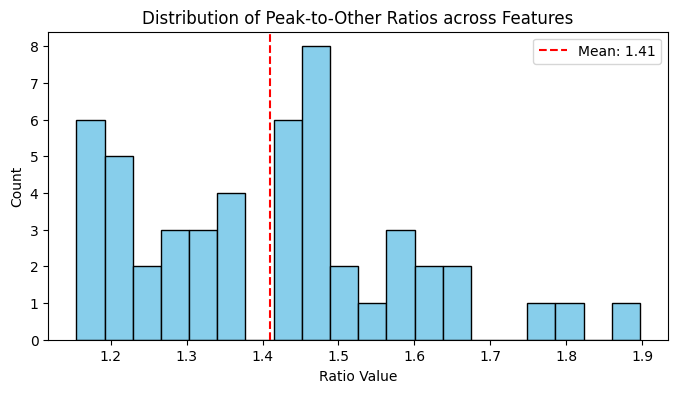

Epoch: 1, Loss: 40.866631, LR: 0.010000
Epoch: 2, Loss: 36.517719, LR: 0.010000
Epoch: 3, Loss: 33.052071, LR: 0.010000
Epoch: 4, Loss: 30.306911, LR: 0.010000
Epoch: 5, Loss: 28.160564, LR: 0.010000
Epoch: 6, Loss: 26.512070, LR: 0.010000
Epoch: 7, Loss: 25.272892, LR: 0.010000
Epoch: 8, Loss: 24.361740, LR: 0.010000
Epoch: 9, Loss: 23.708197, LR: 0.010000
Epoch: 10, Loss: 23.253628, LR: 0.010000
Epoch: 11, Loss: 22.948179, LR: 0.010000
Epoch: 12, Loss: 22.752155, LR: 0.010000
Epoch: 13, Loss: 22.634665, LR: 0.010000
Epoch: 14, Loss: 22.570955, LR: 0.010000
Epoch: 15, Loss: 22.540617, LR: 0.010000
Epoch: 16, Loss: 22.526928, LR: 0.010000
Epoch: 17, Loss: 22.516809, LR: 0.010000
Epoch: 18, Loss: 22.500477, LR: 0.010000
Epoch: 19, Loss: 22.470978, LR: 0.010000
Epoch: 20, Loss: 22.423864, LR: 0.010000
Epoch: 21, Loss: 22.356598, LR: 0.010000
Epoch: 22, Loss: 22.267710, LR: 0.010000
Epoch: 23, Loss: 22.156548, LR: 0.010000
Epoch: 24, Loss: 22.023266, LR: 0.010000
Epoch: 25, Loss: 21.86869

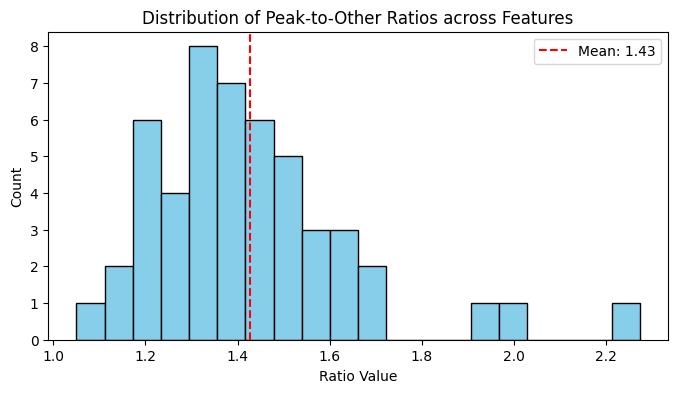

Epoch: 1, Loss: 42.971455, LR: 0.010000
Epoch: 2, Loss: 38.381042, LR: 0.010000
Epoch: 3, Loss: 34.704590, LR: 0.010000
Epoch: 4, Loss: 31.816505, LR: 0.010000
Epoch: 5, Loss: 29.578310, LR: 0.010000
Epoch: 6, Loss: 27.878963, LR: 0.010000
Epoch: 7, Loss: 26.623106, LR: 0.010000
Epoch: 8, Loss: 25.727118, LR: 0.010000
Epoch: 9, Loss: 25.115452, LR: 0.010000
Epoch: 10, Loss: 24.723328, LR: 0.010000
Epoch: 11, Loss: 24.493725, LR: 0.010000
Epoch: 12, Loss: 24.375282, LR: 0.010000
Epoch: 13, Loss: 24.325512, LR: 0.010000
Epoch: 14, Loss: 24.312506, LR: 0.010000
Epoch: 15, Loss: 24.313290, LR: 0.010000
Epoch: 16, Loss: 24.310827, LR: 0.010000
Epoch: 17, Loss: 24.292063, LR: 0.010000
Epoch: 18, Loss: 24.247860, LR: 0.010000
Epoch: 19, Loss: 24.172749, LR: 0.010000
Epoch: 20, Loss: 24.063766, LR: 0.010000
Epoch: 21, Loss: 23.919495, LR: 0.010000
Epoch: 22, Loss: 23.739624, LR: 0.010000
Epoch: 23, Loss: 23.525227, LR: 0.010000
Epoch: 24, Loss: 23.279020, LR: 0.010000
Epoch: 25, Loss: 23.00502

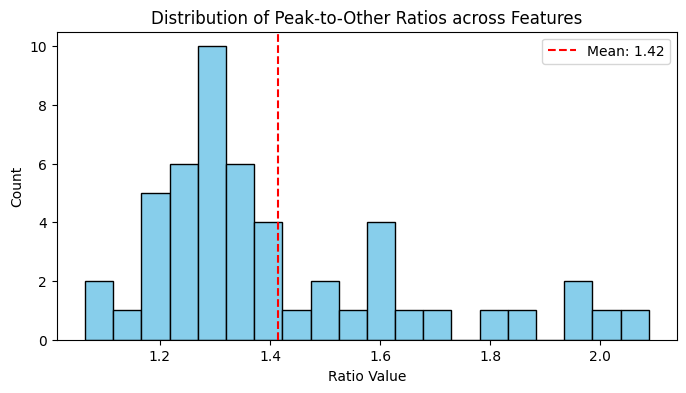

Epoch: 1, Loss: 41.144123, LR: 0.010000
Epoch: 2, Loss: 36.722141, LR: 0.010000
Epoch: 3, Loss: 33.244244, LR: 0.010000
Epoch: 4, Loss: 30.526966, LR: 0.010000
Epoch: 5, Loss: 28.431967, LR: 0.010000
Epoch: 6, Loss: 26.845112, LR: 0.010000
Epoch: 7, Loss: 25.666622, LR: 0.010000
Epoch: 8, Loss: 24.810074, LR: 0.010000
Epoch: 9, Loss: 24.204926, LR: 0.010000
Epoch: 10, Loss: 23.791225, LR: 0.010000
Epoch: 11, Loss: 23.516966, LR: 0.010000
Epoch: 12, Loss: 23.338400, LR: 0.010000
Epoch: 13, Loss: 23.220898, LR: 0.010000
Epoch: 14, Loss: 23.139011, LR: 0.010000
Epoch: 15, Loss: 23.073868, LR: 0.010000
Epoch: 16, Loss: 23.010796, LR: 0.010000
Epoch: 17, Loss: 22.937902, LR: 0.010000
Epoch: 18, Loss: 22.845684, LR: 0.010000
Epoch: 19, Loss: 22.727728, LR: 0.010000
Epoch: 20, Loss: 22.580912, LR: 0.010000
Epoch: 21, Loss: 22.404734, LR: 0.010000
Epoch: 22, Loss: 22.200579, LR: 0.010000
Epoch: 23, Loss: 21.971235, LR: 0.010000
Epoch: 24, Loss: 21.720352, LR: 0.010000
Epoch: 25, Loss: 21.45180

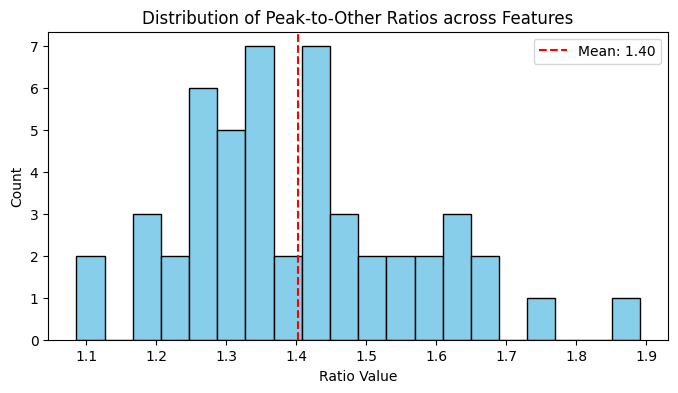


--- Testing Factor: 4 ---
Epoch: 1, Loss: 48.776546, LR: 0.010000
Epoch: 2, Loss: 43.547840, LR: 0.010000
Epoch: 3, Loss: 39.507183, LR: 0.010000
Epoch: 4, Loss: 36.492455, LR: 0.010000
Epoch: 5, Loss: 34.341724, LR: 0.010000
Epoch: 6, Loss: 32.896656, LR: 0.010000
Epoch: 7, Loss: 32.005325, LR: 0.010000
Epoch: 8, Loss: 31.524948, LR: 0.010000
Epoch: 9, Loss: 31.324778, LR: 0.010000
Epoch: 10, Loss: 31.293575, LR: 0.010000
Epoch: 11, Loss: 31.339849, LR: 0.010000
Epoch: 12, Loss: 31.393995, LR: 0.010000
Epoch: 13, Loss: 31.407940, LR: 0.010000
Epoch: 14, Loss: 31.351494, LR: 0.010000
Epoch: 15, Loss: 31.207848, LR: 0.010000
Epoch: 16, Loss: 30.971512, LR: 0.010000
Epoch: 17, Loss: 30.646950, LR: 0.010000
Epoch: 18, Loss: 30.244570, LR: 0.010000
Epoch: 19, Loss: 29.778194, LR: 0.010000
Epoch: 20, Loss: 29.262430, LR: 0.010000
Epoch: 21, Loss: 28.712244, LR: 0.010000
Epoch: 22, Loss: 28.141855, LR: 0.010000
Epoch: 23, Loss: 27.563660, LR: 0.010000
Epoch: 24, Loss: 26.987732, LR: 0.01000

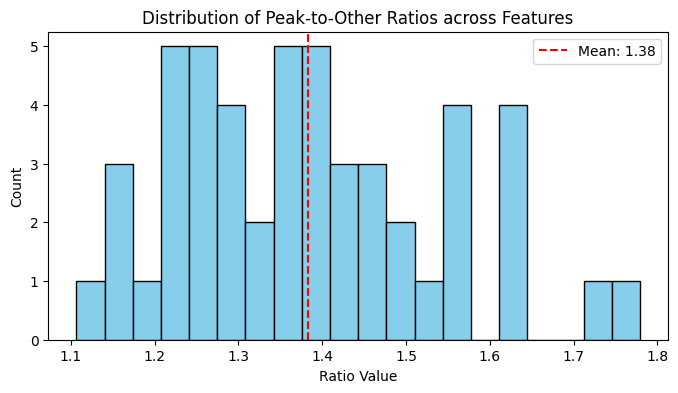

Epoch: 1, Loss: 44.967587, LR: 0.010000
Epoch: 2, Loss: 40.113907, LR: 0.010000
Epoch: 3, Loss: 36.398388, LR: 0.010000
Epoch: 4, Loss: 33.649940, LR: 0.010000
Epoch: 5, Loss: 31.703802, LR: 0.010000
Epoch: 6, Loss: 30.397251, LR: 0.010000
Epoch: 7, Loss: 29.579191, LR: 0.010000
Epoch: 8, Loss: 29.124365, LR: 0.010000
Epoch: 9, Loss: 28.928049, LR: 0.010000
Epoch: 10, Loss: 28.896107, LR: 0.010000
Epoch: 11, Loss: 28.955700, LR: 0.010000
Epoch: 12, Loss: 29.049191, LR: 0.010000
Epoch: 13, Loss: 29.132324, LR: 0.010000
Epoch: 14, Loss: 29.172400, LR: 0.010000
Epoch: 15, Loss: 29.146788, LR: 0.010000
Epoch: 16, Loss: 29.042595, LR: 0.010000
Epoch: 17, Loss: 28.855322, LR: 0.010000
Epoch: 18, Loss: 28.587143, LR: 0.010000
Epoch: 19, Loss: 28.244999, LR: 0.010000
Epoch: 20, Loss: 27.838818, LR: 0.010000
Epoch: 21, Loss: 27.380163, LR: 0.010000
Epoch: 22, Loss: 26.881361, LR: 0.010000
Epoch: 23, Loss: 26.354771, LR: 0.010000
Epoch: 24, Loss: 25.812159, LR: 0.010000
Epoch: 25, Loss: 25.26420

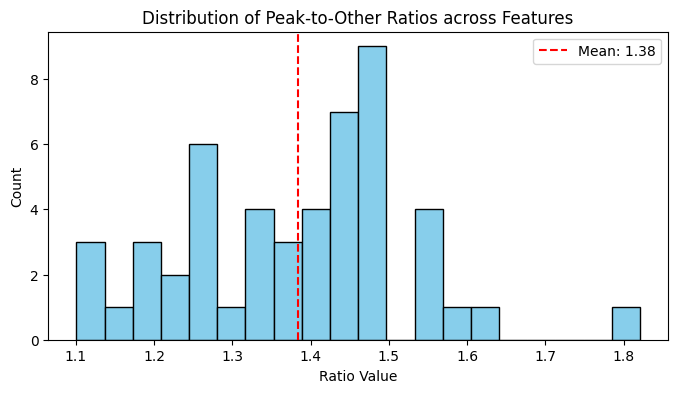

Epoch: 1, Loss: 47.146503, LR: 0.010000
Epoch: 2, Loss: 42.137669, LR: 0.010000
Epoch: 3, Loss: 38.278343, LR: 0.010000
Epoch: 4, Loss: 35.375378, LR: 0.010000
Epoch: 5, Loss: 33.282169, LR: 0.010000
Epoch: 6, Loss: 31.844767, LR: 0.010000
Epoch: 7, Loss: 30.913826, LR: 0.010000
Epoch: 8, Loss: 30.361834, LR: 0.010000
Epoch: 9, Loss: 30.080870, LR: 0.010000
Epoch: 10, Loss: 29.976456, LR: 0.010000
Epoch: 11, Loss: 29.966967, LR: 0.010000
Epoch: 12, Loss: 29.985630, LR: 0.010000
Epoch: 13, Loss: 29.982817, LR: 0.010000
Epoch: 14, Loss: 29.925623, LR: 0.010000
Epoch: 15, Loss: 29.796099, LR: 0.010000
Epoch: 16, Loss: 29.587969, LR: 0.010000
Epoch: 17, Loss: 29.303040, LR: 0.010000
Epoch: 18, Loss: 28.948090, LR: 0.010000
Epoch: 19, Loss: 28.532602, LR: 0.010000
Epoch: 20, Loss: 28.067652, LR: 0.010000
Epoch: 21, Loss: 27.564678, LR: 0.010000
Epoch: 22, Loss: 27.034754, LR: 0.010000
Epoch: 23, Loss: 26.488708, LR: 0.010000
Epoch: 24, Loss: 25.936584, LR: 0.010000
Epoch: 25, Loss: 25.38679

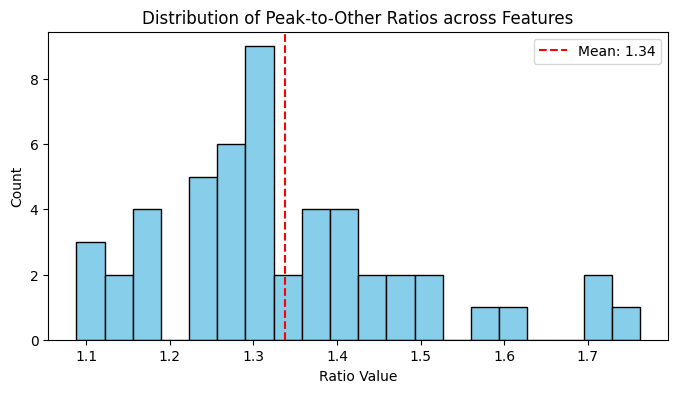

Epoch: 1, Loss: 46.075092, LR: 0.010000
Epoch: 2, Loss: 41.291279, LR: 0.010000
Epoch: 3, Loss: 37.571712, LR: 0.010000
Epoch: 4, Loss: 34.757992, LR: 0.010000
Epoch: 5, Loss: 32.712452, LR: 0.010000
Epoch: 6, Loss: 31.291437, LR: 0.010000
Epoch: 7, Loss: 30.362129, LR: 0.010000
Epoch: 8, Loss: 29.804146, LR: 0.010000
Epoch: 9, Loss: 29.507820, LR: 0.010000
Epoch: 10, Loss: 29.382984, LR: 0.010000
Epoch: 11, Loss: 29.356281, LR: 0.010000
Epoch: 12, Loss: 29.368935, LR: 0.010000
Epoch: 13, Loss: 29.376577, LR: 0.010000
Epoch: 14, Loss: 29.347965, LR: 0.010000
Epoch: 15, Loss: 29.262753, LR: 0.010000
Epoch: 16, Loss: 29.109127, LR: 0.010000
Epoch: 17, Loss: 28.881992, LR: 0.010000
Epoch: 18, Loss: 28.582270, LR: 0.010000
Epoch: 19, Loss: 28.215826, LR: 0.010000
Epoch: 20, Loss: 27.791840, LR: 0.010000
Epoch: 21, Loss: 27.321466, LR: 0.010000
Epoch: 22, Loss: 26.816811, LR: 0.010000
Epoch: 23, Loss: 26.290043, LR: 0.010000
Epoch: 24, Loss: 25.752710, LR: 0.010000
Epoch: 25, Loss: 25.21533

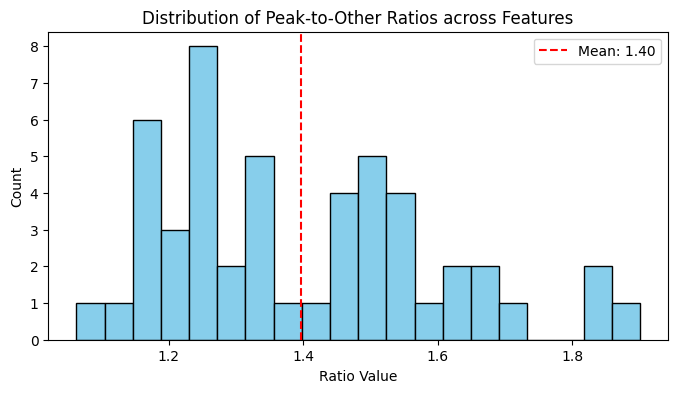

Epoch: 1, Loss: 50.189423, LR: 0.010000
Epoch: 2, Loss: 44.863785, LR: 0.010000
Epoch: 3, Loss: 40.702633, LR: 0.010000
Epoch: 4, Loss: 37.534962, LR: 0.010000
Epoch: 5, Loss: 35.196804, LR: 0.010000
Epoch: 6, Loss: 33.532112, LR: 0.010000
Epoch: 7, Loss: 32.394402, LR: 0.010000
Epoch: 8, Loss: 31.660393, LR: 0.010000
Epoch: 9, Loss: 31.222897, LR: 0.010000
Epoch: 10, Loss: 30.989634, LR: 0.010000
Epoch: 11, Loss: 30.881670, LR: 0.010000
Epoch: 12, Loss: 30.832973, LR: 0.010000
Epoch: 13, Loss: 30.791576, LR: 0.010000
Epoch: 14, Loss: 30.720205, LR: 0.010000
Epoch: 15, Loss: 30.594830, LR: 0.010000
Epoch: 16, Loss: 30.402140, LR: 0.010000
Epoch: 17, Loss: 30.137053, LR: 0.010000
Epoch: 18, Loss: 29.800667, LR: 0.010000
Epoch: 19, Loss: 29.398405, LR: 0.010000
Epoch: 20, Loss: 28.938351, LR: 0.010000
Epoch: 21, Loss: 28.430311, LR: 0.010000
Epoch: 22, Loss: 27.885237, LR: 0.010000
Epoch: 23, Loss: 27.314474, LR: 0.010000
Epoch: 24, Loss: 26.729057, LR: 0.010000
Epoch: 25, Loss: 26.13927

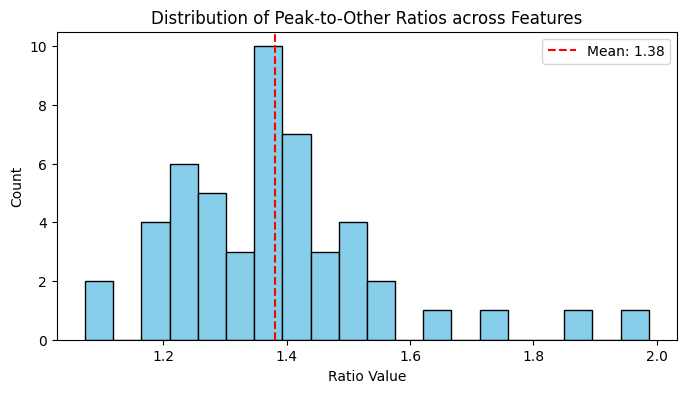

Epoch: 1, Loss: 48.916698, LR: 0.010000
Epoch: 2, Loss: 43.698414, LR: 0.010000
Epoch: 3, Loss: 39.755707, LR: 0.010000
Epoch: 4, Loss: 36.824566, LR: 0.010000
Epoch: 5, Loss: 34.722908, LR: 0.010000
Epoch: 6, Loss: 33.300713, LR: 0.010000
Epoch: 7, Loss: 32.410557, LR: 0.010000
Epoch: 8, Loss: 31.906416, LR: 0.010000
Epoch: 9, Loss: 31.662998, LR: 0.010000
Epoch: 10, Loss: 31.579391, LR: 0.010000
Epoch: 11, Loss: 31.571600, LR: 0.010000
Epoch: 12, Loss: 31.572979, LR: 0.010000
Epoch: 13, Loss: 31.537537, LR: 0.010000
Epoch: 14, Loss: 31.437519, LR: 0.010000
Epoch: 15, Loss: 31.259180, LR: 0.010000
Epoch: 16, Loss: 30.998129, LR: 0.010000
Epoch: 17, Loss: 30.656374, LR: 0.010000
Epoch: 18, Loss: 30.241472, LR: 0.010000
Epoch: 19, Loss: 29.764997, LR: 0.010000
Epoch: 20, Loss: 29.240652, LR: 0.010000
Epoch: 21, Loss: 28.682550, LR: 0.010000
Epoch: 22, Loss: 28.103891, LR: 0.010000
Epoch: 23, Loss: 27.516182, LR: 0.010000
Epoch: 24, Loss: 26.928879, LR: 0.010000
Epoch: 25, Loss: 26.34945

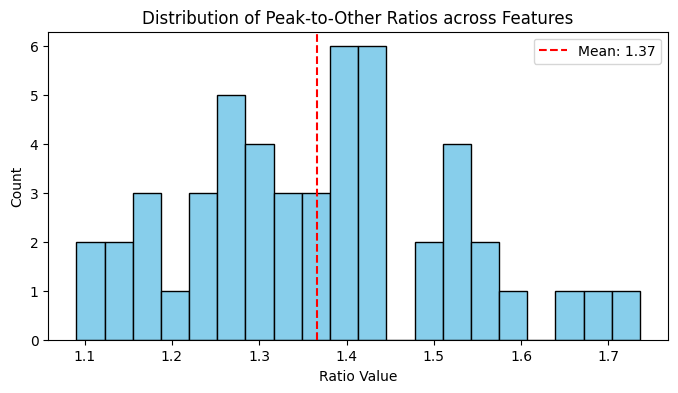

Epoch: 1, Loss: 52.139900, LR: 0.010000
Epoch: 2, Loss: 46.241714, LR: 0.010000
Epoch: 3, Loss: 41.593201, LR: 0.010000
Epoch: 4, Loss: 38.034084, LR: 0.010000
Epoch: 5, Loss: 35.399281, LR: 0.010000
Epoch: 6, Loss: 33.530872, LR: 0.010000
Epoch: 7, Loss: 32.276070, LR: 0.010000
Epoch: 8, Loss: 31.496025, LR: 0.010000
Epoch: 9, Loss: 31.070747, LR: 0.010000
Epoch: 10, Loss: 30.893202, LR: 0.010000
Epoch: 11, Loss: 30.870224, LR: 0.010000
Epoch: 12, Loss: 30.924473, LR: 0.010000
Epoch: 13, Loss: 30.992666, LR: 0.010000
Epoch: 14, Loss: 31.026005, LR: 0.010000
Epoch: 15, Loss: 30.991728, LR: 0.010000
Epoch: 16, Loss: 30.870304, LR: 0.010000
Epoch: 17, Loss: 30.652632, LR: 0.010000
Epoch: 18, Loss: 30.338764, LR: 0.010000
Epoch: 19, Loss: 29.936169, LR: 0.010000
Epoch: 20, Loss: 29.456865, LR: 0.010000
Epoch: 21, Loss: 28.915403, LR: 0.010000
Epoch: 22, Loss: 28.327059, LR: 0.010000
Epoch: 23, Loss: 27.706732, LR: 0.010000
Epoch: 24, Loss: 27.068510, LR: 0.010000
Epoch: 25, Loss: 26.42561

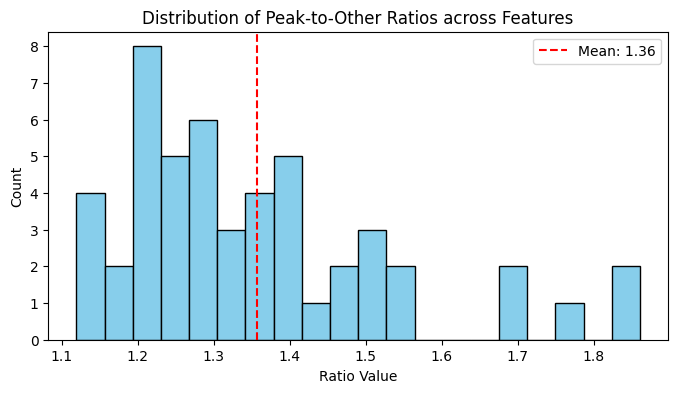

Epoch: 1, Loss: 50.341282, LR: 0.010000
Epoch: 2, Loss: 44.917618, LR: 0.010000
Epoch: 3, Loss: 40.620216, LR: 0.010000
Epoch: 4, Loss: 37.326168, LR: 0.010000
Epoch: 5, Loss: 34.881008, LR: 0.010000
Epoch: 6, Loss: 33.120190, LR: 0.010000
Epoch: 7, Loss: 31.896299, LR: 0.010000
Epoch: 8, Loss: 31.083868, LR: 0.010000
Epoch: 9, Loss: 30.574591, LR: 0.010000
Epoch: 10, Loss: 30.272181, LR: 0.010000
Epoch: 11, Loss: 30.095928, LR: 0.010000
Epoch: 12, Loss: 29.982183, LR: 0.010000
Epoch: 13, Loss: 29.883173, LR: 0.010000
Epoch: 14, Loss: 29.764851, LR: 0.010000
Epoch: 15, Loss: 29.605650, LR: 0.010000
Epoch: 16, Loss: 29.394333, LR: 0.010000
Epoch: 17, Loss: 29.127035, LR: 0.010000
Epoch: 18, Loss: 28.804554, LR: 0.010000
Epoch: 19, Loss: 28.430458, LR: 0.010000
Epoch: 20, Loss: 28.009806, LR: 0.010000
Epoch: 21, Loss: 27.548412, LR: 0.010000
Epoch: 22, Loss: 27.053072, LR: 0.010000
Epoch: 23, Loss: 26.532042, LR: 0.010000
Epoch: 24, Loss: 25.994858, LR: 0.010000
Epoch: 25, Loss: 25.45161

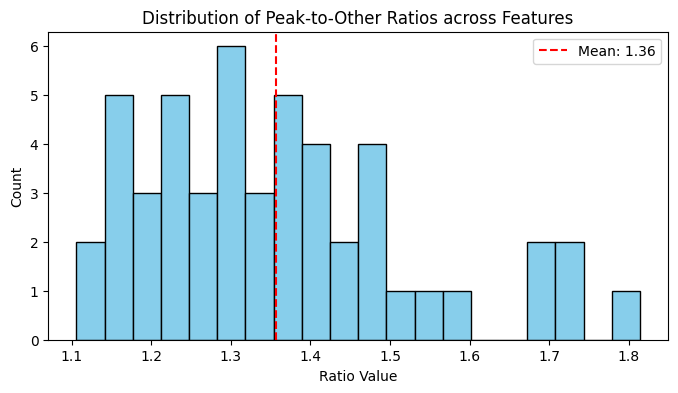

Epoch: 1, Loss: 50.235531, LR: 0.010000
Epoch: 2, Loss: 44.806435, LR: 0.010000
Epoch: 3, Loss: 40.564453, LR: 0.010000
Epoch: 4, Loss: 37.343960, LR: 0.010000
Epoch: 5, Loss: 34.982605, LR: 0.010000
Epoch: 6, Loss: 33.324734, LR: 0.010000
Epoch: 7, Loss: 32.229145, LR: 0.010000
Epoch: 8, Loss: 31.560160, LR: 0.010000
Epoch: 9, Loss: 31.193621, LR: 0.010000
Epoch: 10, Loss: 31.025932, LR: 0.010000
Epoch: 11, Loss: 30.972340, LR: 0.010000
Epoch: 12, Loss: 30.963245, LR: 0.010000
Epoch: 13, Loss: 30.943781, LR: 0.010000
Epoch: 14, Loss: 30.875471, LR: 0.010000
Epoch: 15, Loss: 30.735085, LR: 0.010000
Epoch: 16, Loss: 30.511868, LR: 0.010000
Epoch: 17, Loss: 30.205139, LR: 0.010000
Epoch: 18, Loss: 29.821434, LR: 0.010000
Epoch: 19, Loss: 29.371674, LR: 0.010000
Epoch: 20, Loss: 28.868958, LR: 0.010000
Epoch: 21, Loss: 28.326927, LR: 0.010000
Epoch: 22, Loss: 27.758675, LR: 0.010000
Epoch: 23, Loss: 27.175936, LR: 0.010000
Epoch: 24, Loss: 26.588690, LR: 0.010000
Epoch: 25, Loss: 26.00546

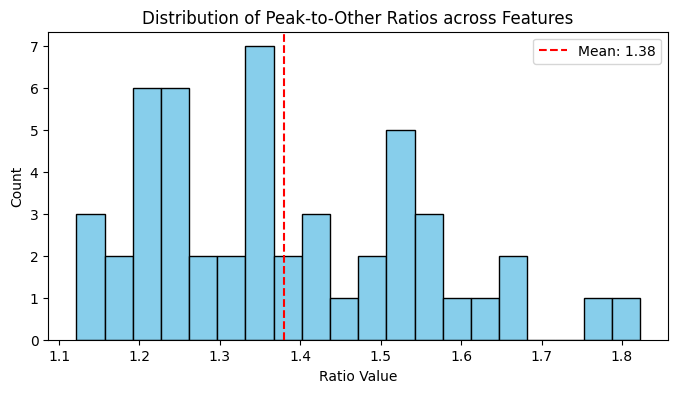

Epoch: 1, Loss: 50.337940, LR: 0.010000
Epoch: 2, Loss: 44.893528, LR: 0.010000
Epoch: 3, Loss: 40.603565, LR: 0.010000
Epoch: 4, Loss: 37.318241, LR: 0.010000
Epoch: 5, Loss: 34.884823, LR: 0.010000
Epoch: 6, Loss: 33.156738, LR: 0.010000
Epoch: 7, Loss: 31.996033, LR: 0.010000
Epoch: 8, Loss: 31.270191, LR: 0.010000
Epoch: 9, Loss: 30.856197, LR: 0.010000
Epoch: 10, Loss: 30.647202, LR: 0.010000
Epoch: 11, Loss: 30.559677, LR: 0.010000
Epoch: 12, Loss: 30.529011, LR: 0.010000
Epoch: 13, Loss: 30.506924, LR: 0.010000
Epoch: 14, Loss: 30.459774, LR: 0.010000
Epoch: 15, Loss: 30.364305, LR: 0.010000
Epoch: 16, Loss: 30.208918, LR: 0.010000
Epoch: 17, Loss: 29.990063, LR: 0.010000
Epoch: 18, Loss: 29.708954, LR: 0.010000
Epoch: 19, Loss: 29.369886, LR: 0.010000
Epoch: 20, Loss: 28.978086, LR: 0.010000
Epoch: 21, Loss: 28.539764, LR: 0.010000
Epoch: 22, Loss: 28.062437, LR: 0.010000
Epoch: 23, Loss: 27.554150, LR: 0.010000
Epoch: 24, Loss: 27.022995, LR: 0.010000
Epoch: 25, Loss: 26.47717

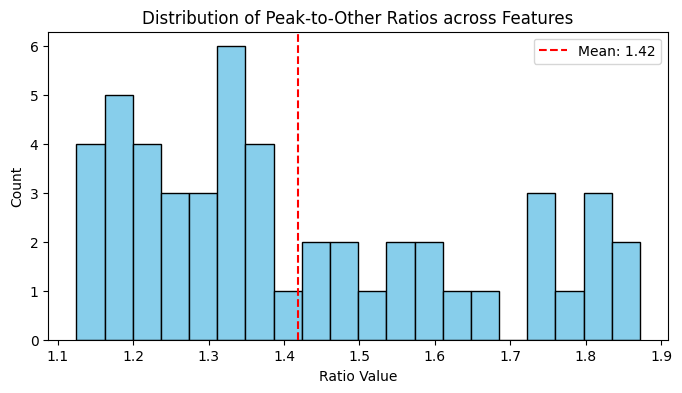


--- Testing Factor: 5 ---
Epoch: 1, Loss: 52.401260, LR: 0.010000
Epoch: 2, Loss: 46.182117, LR: 0.010000
Epoch: 3, Loss: 41.503479, LR: 0.010000
Epoch: 4, Loss: 38.116398, LR: 0.010000
Epoch: 5, Loss: 35.781796, LR: 0.010000
Epoch: 6, Loss: 34.291218, LR: 0.010000
Epoch: 7, Loss: 33.449162, LR: 0.010000
Epoch: 8, Loss: 33.077030, LR: 0.010000
Epoch: 9, Loss: 33.008942, LR: 0.010000
Epoch: 10, Loss: 33.098370, LR: 0.010000
Epoch: 11, Loss: 33.227577, LR: 0.010000
Epoch: 12, Loss: 33.310814, LR: 0.010000
Epoch: 13, Loss: 33.292355, LR: 0.010000
Epoch: 14, Loss: 33.141933, LR: 0.010000
Epoch: 15, Loss: 32.849113, LR: 0.010000
Epoch: 16, Loss: 32.418633, LR: 0.010000
Epoch: 17, Loss: 31.866371, LR: 0.010000
Epoch: 18, Loss: 31.214918, LR: 0.010000
Epoch: 19, Loss: 30.489597, LR: 0.010000
Epoch: 20, Loss: 29.715660, LR: 0.010000
Epoch: 21, Loss: 28.916552, LR: 0.010000
Epoch: 22, Loss: 28.112812, LR: 0.010000
Epoch: 23, Loss: 27.321665, LR: 0.010000
Epoch: 24, Loss: 26.557154, LR: 0.01000

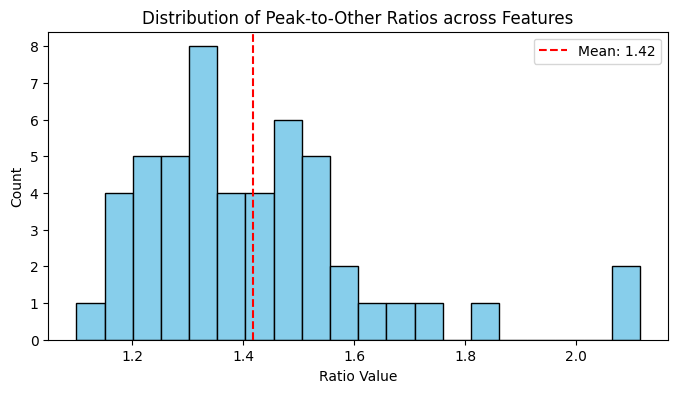

Epoch: 1, Loss: 47.959419, LR: 0.010000
Epoch: 2, Loss: 42.567593, LR: 0.010000
Epoch: 3, Loss: 38.525475, LR: 0.010000
Epoch: 4, Loss: 35.632896, LR: 0.010000
Epoch: 5, Loss: 33.690720, LR: 0.010000
Epoch: 6, Loss: 32.503029, LR: 0.010000
Epoch: 7, Loss: 31.877884, LR: 0.010000
Epoch: 8, Loss: 31.639116, LR: 0.010000
Epoch: 9, Loss: 31.636745, LR: 0.010000
Epoch: 10, Loss: 31.749266, LR: 0.010000
Epoch: 11, Loss: 31.881197, LR: 0.010000
Epoch: 12, Loss: 31.961393, LR: 0.010000
Epoch: 13, Loss: 31.942787, LR: 0.010000
Epoch: 14, Loss: 31.799679, LR: 0.010000
Epoch: 15, Loss: 31.524044, LR: 0.010000
Epoch: 16, Loss: 31.121841, LR: 0.010000
Epoch: 17, Loss: 30.608717, LR: 0.010000
Epoch: 18, Loss: 30.005516, LR: 0.010000
Epoch: 19, Loss: 29.334780, LR: 0.010000
Epoch: 20, Loss: 28.618498, LR: 0.010000
Epoch: 21, Loss: 27.876631, LR: 0.010000
Epoch: 22, Loss: 27.126425, LR: 0.010000
Epoch: 23, Loss: 26.382408, LR: 0.010000
Epoch: 24, Loss: 25.656775, LR: 0.010000
Epoch: 25, Loss: 24.95985

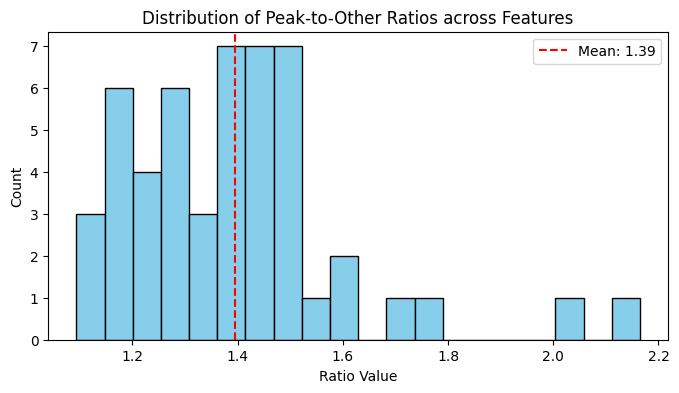

Epoch: 1, Loss: 48.748997, LR: 0.010000
Epoch: 2, Loss: 43.420475, LR: 0.010000
Epoch: 3, Loss: 39.427536, LR: 0.010000
Epoch: 4, Loss: 36.576649, LR: 0.010000
Epoch: 5, Loss: 34.668362, LR: 0.010000
Epoch: 6, Loss: 33.500309, LR: 0.010000
Epoch: 7, Loss: 32.884506, LR: 0.010000
Epoch: 8, Loss: 32.652462, LR: 0.010000
Epoch: 9, Loss: 32.657005, LR: 0.010000
Epoch: 10, Loss: 32.773941, LR: 0.010000
Epoch: 11, Loss: 32.905201, LR: 0.010000
Epoch: 12, Loss: 32.978493, LR: 0.010000
Epoch: 13, Loss: 32.944996, LR: 0.010000
Epoch: 14, Loss: 32.777115, LR: 0.010000
Epoch: 15, Loss: 32.465370, LR: 0.010000
Epoch: 16, Loss: 32.014847, LR: 0.010000
Epoch: 17, Loss: 31.441002, LR: 0.010000
Epoch: 18, Loss: 30.765387, LR: 0.010000
Epoch: 19, Loss: 30.012222, LR: 0.010000
Epoch: 20, Loss: 29.206013, LR: 0.010000
Epoch: 21, Loss: 28.370068, LR: 0.010000
Epoch: 22, Loss: 27.525574, LR: 0.010000
Epoch: 23, Loss: 26.691183, LR: 0.010000
Epoch: 24, Loss: 25.882860, LR: 0.010000
Epoch: 25, Loss: 25.11384

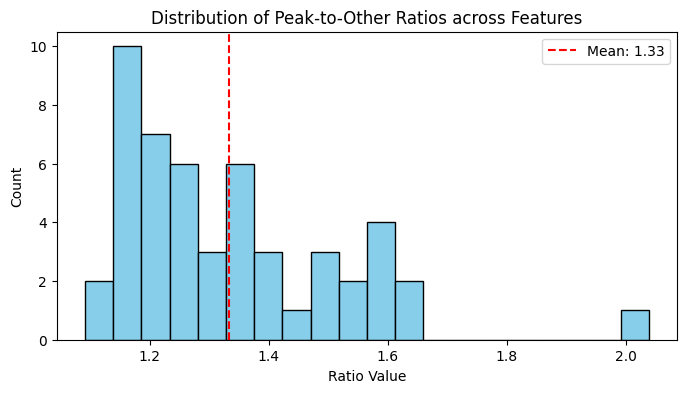

Epoch: 1, Loss: 50.428326, LR: 0.010000
Epoch: 2, Loss: 44.846710, LR: 0.010000
Epoch: 3, Loss: 40.609428, LR: 0.010000
Epoch: 4, Loss: 37.537537, LR: 0.010000
Epoch: 5, Loss: 35.454655, LR: 0.010000
Epoch: 6, Loss: 34.170086, LR: 0.010000
Epoch: 7, Loss: 33.494560, LR: 0.010000
Epoch: 8, Loss: 33.246452, LR: 0.010000
Epoch: 9, Loss: 33.263023, LR: 0.010000
Epoch: 10, Loss: 33.406021, LR: 0.010000
Epoch: 11, Loss: 33.563267, LR: 0.010000
Epoch: 12, Loss: 33.651886, LR: 0.010000
Epoch: 13, Loss: 33.617481, LR: 0.010000
Epoch: 14, Loss: 33.431366, LR: 0.010000
Epoch: 15, Loss: 33.086643, LR: 0.010000
Epoch: 16, Loss: 32.593399, LR: 0.010000
Epoch: 17, Loss: 31.973284, LR: 0.010000
Epoch: 18, Loss: 31.254089, LR: 0.010000
Epoch: 19, Loss: 30.465267, LR: 0.010000
Epoch: 20, Loss: 29.634874, LR: 0.010000
Epoch: 21, Loss: 28.787954, LR: 0.010000
Epoch: 22, Loss: 27.945791, LR: 0.010000
Epoch: 23, Loss: 27.125711, LR: 0.010000
Epoch: 24, Loss: 26.341251, LR: 0.010000
Epoch: 25, Loss: 25.60251

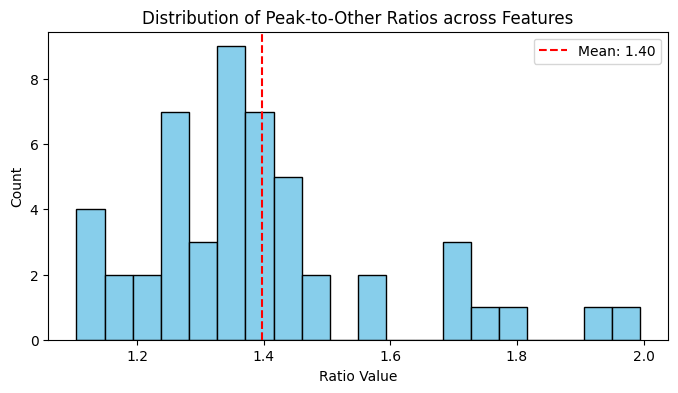

Epoch: 1, Loss: 50.441818, LR: 0.010000
Epoch: 2, Loss: 45.004539, LR: 0.010000
Epoch: 3, Loss: 40.934521, LR: 0.010000
Epoch: 4, Loss: 38.011227, LR: 0.010000
Epoch: 5, Loss: 36.042812, LR: 0.010000
Epoch: 6, Loss: 34.830521, LR: 0.010000
Epoch: 7, Loss: 34.187408, LR: 0.010000
Epoch: 8, Loss: 33.936253, LR: 0.010000
Epoch: 9, Loss: 33.924892, LR: 0.010000
Epoch: 10, Loss: 34.030014, LR: 0.010000
Epoch: 11, Loss: 34.152275, LR: 0.010000
Epoch: 12, Loss: 34.216953, LR: 0.010000
Epoch: 13, Loss: 34.175430, LR: 0.010000
Epoch: 14, Loss: 34.002514, LR: 0.010000
Epoch: 15, Loss: 33.691418, LR: 0.010000
Epoch: 16, Loss: 33.248665, LR: 0.010000
Epoch: 17, Loss: 32.690250, LR: 0.010000
Epoch: 18, Loss: 32.038307, LR: 0.010000
Epoch: 19, Loss: 31.317760, LR: 0.010000
Epoch: 20, Loss: 30.553350, LR: 0.010000
Epoch: 21, Loss: 29.767759, LR: 0.010000
Epoch: 22, Loss: 28.980858, LR: 0.010000
Epoch: 23, Loss: 28.209476, LR: 0.010000
Epoch: 24, Loss: 27.467293, LR: 0.010000
Epoch: 25, Loss: 26.76484

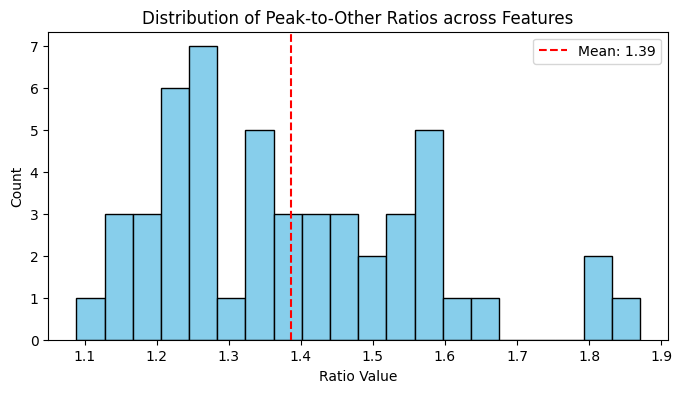

Epoch: 1, Loss: 53.125988, LR: 0.010000
Epoch: 2, Loss: 47.016499, LR: 0.010000
Epoch: 3, Loss: 42.400692, LR: 0.010000
Epoch: 4, Loss: 39.053123, LR: 0.010000
Epoch: 5, Loss: 36.750153, LR: 0.010000
Epoch: 6, Loss: 35.281570, LR: 0.010000
Epoch: 7, Loss: 34.450535, LR: 0.010000
Epoch: 8, Loss: 34.071796, LR: 0.010000
Epoch: 9, Loss: 33.976315, LR: 0.010000
Epoch: 10, Loss: 34.026936, LR: 0.010000
Epoch: 11, Loss: 34.125008, LR: 0.010000
Epoch: 12, Loss: 34.198009, LR: 0.010000
Epoch: 13, Loss: 34.194702, LR: 0.010000
Epoch: 14, Loss: 34.082924, LR: 0.010000
Epoch: 15, Loss: 33.846523, LR: 0.010000
Epoch: 16, Loss: 33.482189, LR: 0.010000
Epoch: 17, Loss: 32.996510, LR: 0.010000
Epoch: 18, Loss: 32.403351, LR: 0.010000
Epoch: 19, Loss: 31.721508, LR: 0.010000
Epoch: 20, Loss: 30.972408, LR: 0.010000
Epoch: 21, Loss: 30.178209, LR: 0.010000
Epoch: 22, Loss: 29.360281, LR: 0.010000
Epoch: 23, Loss: 28.538216, LR: 0.010000
Epoch: 24, Loss: 27.729128, LR: 0.010000
Epoch: 25, Loss: 26.94733

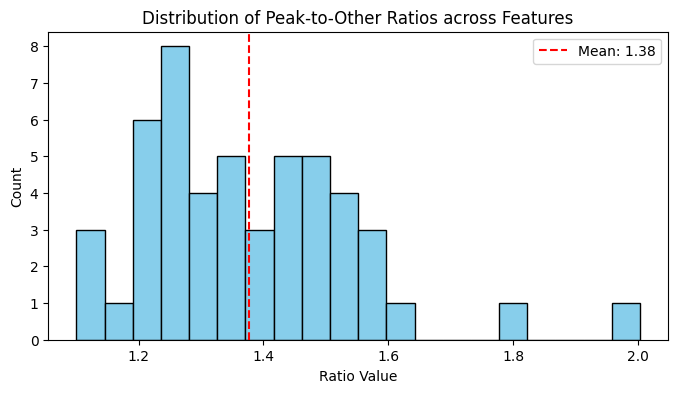

Epoch: 1, Loss: 53.198025, LR: 0.010000
Epoch: 2, Loss: 47.300999, LR: 0.010000
Epoch: 3, Loss: 42.883621, LR: 0.010000
Epoch: 4, Loss: 39.698242, LR: 0.010000
Epoch: 5, Loss: 37.544075, LR: 0.010000
Epoch: 6, Loss: 36.228291, LR: 0.010000
Epoch: 7, Loss: 35.551933, LR: 0.010000
Epoch: 8, Loss: 35.320061, LR: 0.010000
Epoch: 9, Loss: 35.361263, LR: 0.010000
Epoch: 10, Loss: 35.532326, LR: 0.010000
Epoch: 11, Loss: 35.722214, LR: 0.010000
Epoch: 12, Loss: 35.851501, LR: 0.010000
Epoch: 13, Loss: 35.869606, LR: 0.010000
Epoch: 14, Loss: 35.749660, LR: 0.010000
Epoch: 15, Loss: 35.482727, LR: 0.010000
Epoch: 16, Loss: 35.072548, LR: 0.010000
Epoch: 17, Loss: 34.531830, LR: 0.010000
Epoch: 18, Loss: 33.879505, LR: 0.010000
Epoch: 19, Loss: 33.138241, LR: 0.010000
Epoch: 20, Loss: 32.332165, LR: 0.010000
Epoch: 21, Loss: 31.485121, LR: 0.010000
Epoch: 22, Loss: 30.619484, LR: 0.010000
Epoch: 23, Loss: 29.755571, LR: 0.010000
Epoch: 24, Loss: 28.911274, LR: 0.010000
Epoch: 25, Loss: 28.10178

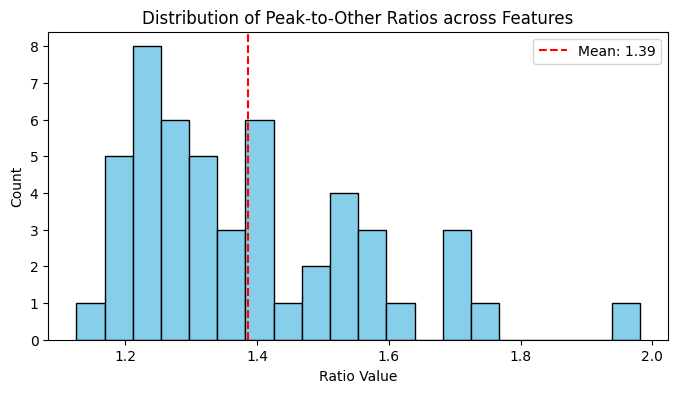

Epoch: 1, Loss: 51.558590, LR: 0.010000
Epoch: 2, Loss: 45.840252, LR: 0.010000
Epoch: 3, Loss: 41.550304, LR: 0.010000
Epoch: 4, Loss: 38.422432, LR: 0.010000
Epoch: 5, Loss: 36.247009, LR: 0.010000
Epoch: 6, Loss: 34.851238, LR: 0.010000
Epoch: 7, Loss: 34.062584, LR: 0.010000
Epoch: 8, Loss: 33.711643, LR: 0.010000
Epoch: 9, Loss: 33.647583, LR: 0.010000
Epoch: 10, Loss: 33.736870, LR: 0.010000
Epoch: 11, Loss: 33.870090, LR: 0.010000
Epoch: 12, Loss: 33.962822, LR: 0.010000
Epoch: 13, Loss: 33.956772, LR: 0.010000
Epoch: 14, Loss: 33.819557, LR: 0.010000
Epoch: 15, Loss: 33.540634, LR: 0.010000
Epoch: 16, Loss: 33.125439, LR: 0.010000
Epoch: 17, Loss: 32.589951, LR: 0.010000
Epoch: 18, Loss: 31.956070, LR: 0.010000
Epoch: 19, Loss: 31.248190, LR: 0.010000
Epoch: 20, Loss: 30.490671, LR: 0.010000
Epoch: 21, Loss: 29.705992, LR: 0.010000
Epoch: 22, Loss: 28.913786, LR: 0.010000
Epoch: 23, Loss: 28.130701, LR: 0.010000
Epoch: 24, Loss: 27.370567, LR: 0.010000
Epoch: 25, Loss: 26.64462

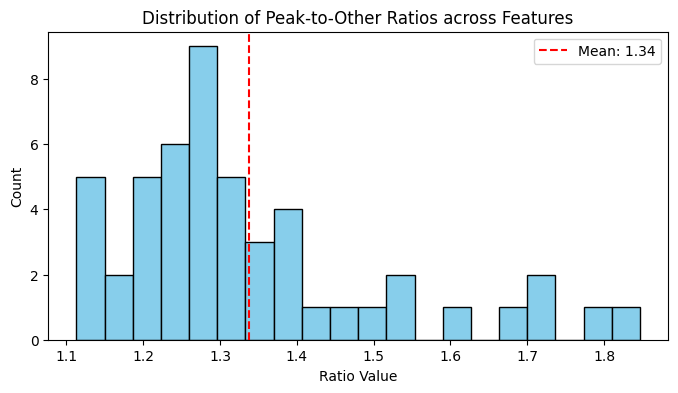

Epoch: 1, Loss: 49.340458, LR: 0.010000
Epoch: 2, Loss: 43.984909, LR: 0.010000
Epoch: 3, Loss: 39.931030, LR: 0.010000
Epoch: 4, Loss: 37.003674, LR: 0.010000
Epoch: 5, Loss: 35.018585, LR: 0.010000
Epoch: 6, Loss: 33.784985, LR: 0.010000
Epoch: 7, Loss: 33.114677, LR: 0.010000
Epoch: 8, Loss: 32.841972, LR: 0.010000
Epoch: 9, Loss: 32.823330, LR: 0.010000
Epoch: 10, Loss: 32.933361, LR: 0.010000
Epoch: 11, Loss: 33.069767, LR: 0.010000
Epoch: 12, Loss: 33.155689, LR: 0.010000
Epoch: 13, Loss: 33.139885, LR: 0.010000
Epoch: 14, Loss: 32.993275, LR: 0.010000
Epoch: 15, Loss: 32.704430, LR: 0.010000
Epoch: 16, Loss: 32.275936, LR: 0.010000
Epoch: 17, Loss: 31.720945, LR: 0.010000
Epoch: 18, Loss: 31.059668, LR: 0.010000
Epoch: 19, Loss: 30.315975, LR: 0.010000
Epoch: 20, Loss: 29.514730, LR: 0.010000
Epoch: 21, Loss: 28.679991, LR: 0.010000
Epoch: 22, Loss: 27.833876, LR: 0.010000
Epoch: 23, Loss: 26.995863, LR: 0.010000
Epoch: 24, Loss: 26.182392, LR: 0.010000
Epoch: 25, Loss: 25.40677

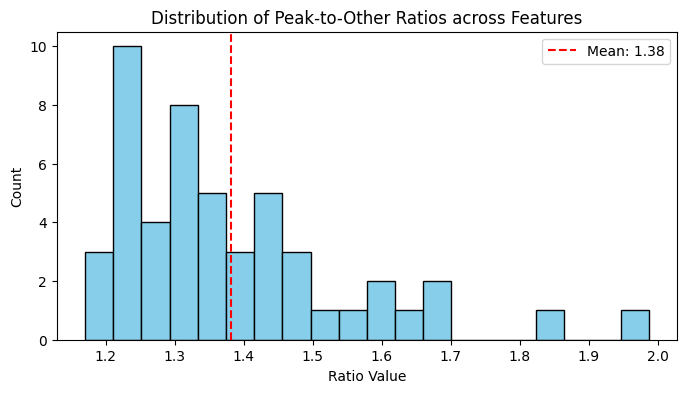

Epoch: 1, Loss: 51.904938, LR: 0.010000
Epoch: 2, Loss: 46.112919, LR: 0.010000
Epoch: 3, Loss: 41.843834, LR: 0.010000
Epoch: 4, Loss: 38.835930, LR: 0.010000
Epoch: 5, Loss: 36.847118, LR: 0.010000
Epoch: 6, Loss: 35.653038, LR: 0.010000
Epoch: 7, Loss: 35.042721, LR: 0.010000
Epoch: 8, Loss: 34.821842, LR: 0.010000
Epoch: 9, Loss: 34.825497, LR: 0.010000
Epoch: 10, Loss: 34.920502, LR: 0.010000
Epoch: 11, Loss: 35.002762, LR: 0.010000
Epoch: 12, Loss: 34.996025, LR: 0.010000
Epoch: 13, Loss: 34.852276, LR: 0.010000
Epoch: 14, Loss: 34.550259, LR: 0.010000
Epoch: 15, Loss: 34.090523, LR: 0.010000
Epoch: 16, Loss: 33.488434, LR: 0.010000
Epoch: 17, Loss: 32.767830, LR: 0.010000
Epoch: 18, Loss: 31.956181, LR: 0.010000
Epoch: 19, Loss: 31.081333, LR: 0.010000
Epoch: 20, Loss: 30.169678, LR: 0.010000
Epoch: 21, Loss: 29.245174, LR: 0.010000
Epoch: 22, Loss: 28.328823, LR: 0.010000
Epoch: 23, Loss: 27.438416, LR: 0.010000
Epoch: 24, Loss: 26.588434, LR: 0.010000
Epoch: 25, Loss: 25.78998

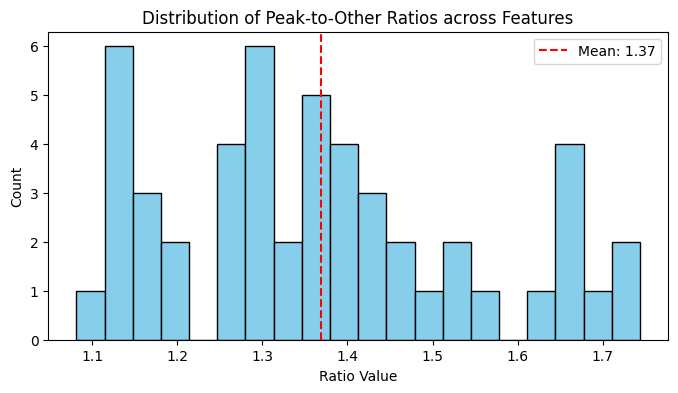

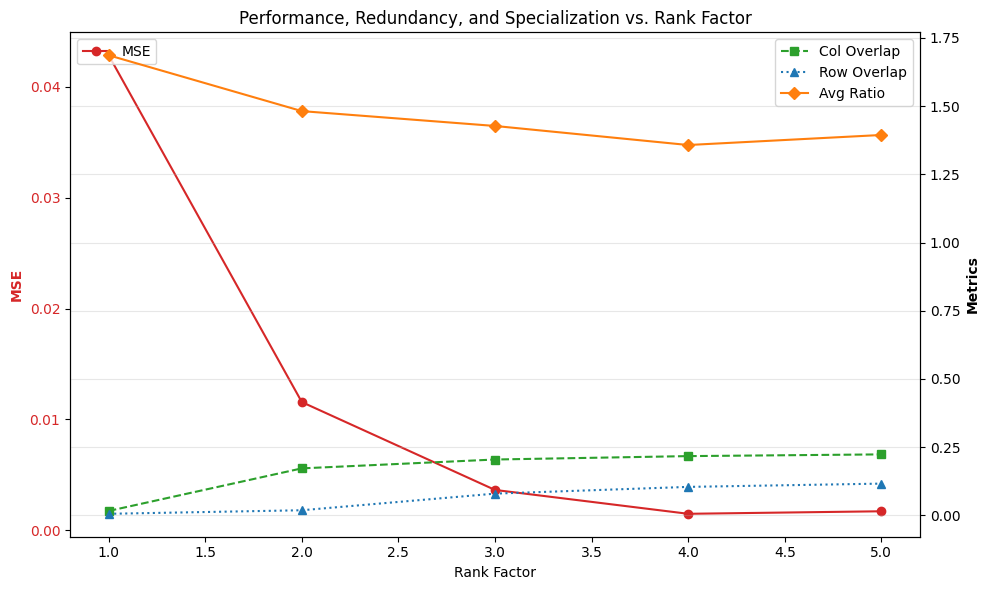

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# ... (Include your existing calculate_global_specialization_ratio function here) ...

factors = [1, 2, 3, 4, 5]
num_trials = 10
results = {f: {"mse": float('inf'), "col": 0.0, "row": 0.0, "ratio": 0.0} for f in factors}

for factor in factors:
    print(f"\n--- Testing Factor: {factor} ---")
    rank = max(1, (min(d_in, d_out) // n_components) * factor)
    min_overlap_sum = float('inf')

    for trial in range(num_trials):
        components = train(model.weights.detach().cpu(), data, rank=rank)
        comp_list = [U @ torch.diag(F.softplus(S)) @ V.T for U, S, V in components]

        err = get_activation_reconstruction_error(model, data, comp_list)
        col_avg, _, row_avg, _ = get_orthogonality_metrics(components)

        # Calculate Average Specialization Ratio for this trial
        ratio = calculate_global_specialization_ratio(data, components, device)

        overlap_sum = col_avg + row_avg
        if overlap_sum < min_overlap_sum:
            min_overlap_sum = overlap_sum
            results[factor]["mse"] = err.item() if hasattr(err, 'item') else err
            results[factor]["col"] = col_avg
            results[factor]["row"] = row_avg
            results[factor]["ratio"] = ratio

# Extracting data
mses = [results[f]["mse"] for f in factors]
cols = [results[f]["col"] for f in factors]
rows = [results[f]["row"] for f in factors]
ratios = [results[f]["ratio"] for f in factors]

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-Axis: MSE
ax1.set_xlabel('Rank Factor')
ax1.set_ylabel('MSE', color='tab:red', fontweight='bold')
ax1.plot(factors, mses, marker='o', color='tab:red', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Right Y-Axis: Redundancy & Specialization
ax2 = ax1.twinx()
ax2.set_ylabel('Metrics', color='black', fontweight='bold')
ax2.plot(factors, cols, marker='s', linestyle='--', color='tab:green', label='Col Overlap')
ax2.plot(factors, rows, marker='^', linestyle=':', color='tab:blue', label='Row Overlap')
ax2.plot(factors, ratios, marker='D', linestyle='-', color='tab:orange', label='Avg Ratio')

ax2.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Performance, Redundancy, and Specialization vs. Rank Factor')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
def get_loss2(mat, tf_components, of_components, data, tf_indices, of_indices, batch_size=32):
    # Ensure mat is on the same device as reconstructed for calculations
    mat_on_device = mat.to(device)

    # matrix reconstruction loss
    tf_comp_list = []
    of_comp_list = []
    n_tf_components = len(tf_components)
    n_of_components = len(of_components)
    n_components = n_tf_components + n_of_components
    reconstructed = torch.zeros_like(mat_on_device, device=device)

    for U, S, V in tf_components:
        S = F.softplus(S)
        Mi = U @ torch.diag(S) @ (V.T)
        tf_comp_list.append(Mi)
        reconstructed += Mi

    for U, S, B in of_components:
        S = F.softplus(S)
        Mi = U @ torch.diag(S) @ (B.T)
        of_comp_list.append(Mi)
        reconstructed += Mi

    # Matrix reconstruction error
    reconstruction_error = ((mat_on_device - reconstructed)**2).mean()

    # Matrix Cosine Similarity Loss
    mat_flat = mat_on_device.view(-1)
    reconstructed_flat = reconstructed.view(-1)
    matrix_cosine_sim = F.cosine_similarity(mat_flat, reconstructed_flat, dim=0)
    matrix_cosine_loss = (1 - matrix_cosine_sim)

    # Column space orthogonality (between TF and OF components)
    loss_col = torch.tensor(0.0, device=device)
    for i in range(n_tf_components):
        U_i, _, _ = tf_components[i]
        U_i_norm, _ = torch.linalg.qr(U_i.to(torch.float32))
        for j in range(n_of_components):
            U_j, _, _ = of_components[j]
            U_j_norm, _ = torch.linalg.qr(U_j.to(torch.float32))
            overlap = U_i_norm.T @ U_j_norm
            rank_i = U_i_norm.shape[1]
            rank_j = U_j_norm.shape[1]
            norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, device=device, dtype=torch.float32))
            loss_col += (torch.norm(overlap, p="fro") / norm_factor)

    # === NORMALIZED LEAKAGE LOSS ===
    # Combine all V matrices from TF and OF components
    V_tf = torch.cat([V for _,_,V in tf_components], dim=1)  # [n_features, total_tf_rank]
    V_of = torch.cat([V for _,_,V in of_components], dim=1)  # [n_features, total_of_rank]

    # Get orthonormal bases
    Q_tf, _ = torch.linalg.qr(V_tf)  # [n_features, rank_tf]
    Q_of, _ = torch.linalg.qr(V_of)  # [n_features, rank_of]

    # Projection matrix onto TF's column space
    P_tf = Q_tf @ Q_tf.T  # [n_features, n_features]

    # Projection matrix onto orthogonal complement of TF's column space
    I = torch.eye(Q_tf.shape[0], device=device)
    P_null_tf = I - P_tf  # Projects onto null space of TF's row space

    # Measure how much OF's row space lies in TF's null space
    # Ideally: Q_of should be fully in null space of TF, so P_null_tf @ Q_of = Q_of
    # Equivalent to: Q_of.T @ P_null_tf @ Q_of should be identity
    overlap = Q_of.T @ P_null_tf @ Q_of  # [rank_of, rank_of]

    # Normalized leakage loss
    # If perfect: overlap = I, so loss = 0
    # If completely overlapping: overlap = 0, so loss = 1
    identity = torch.eye(overlap.shape[0], device=device)
    leakage_loss = torch.norm(identity - overlap, p='fro')

    # Normalize to [0, 1] range by dividing by maximum possible Frobenius norm
    max_possible_norm = torch.sqrt(torch.tensor(overlap.shape[0], device=device, dtype=torch.float32))
    leakage_loss_normalized = leakage_loss / max_possible_norm

    # Alternative normalization: by number of dimensions
    # leakage_loss_normalized = leakage_loss / (overlap.shape[0])

    if n_components > 1:
        n_pairs = n_tf_components * n_of_components
        loss_col /= n_pairs

    total_batches = data.shape[0] // batch_size

    # Activation reconstruction and specialization losses
    total_activation_reconstruction_loss = 0.0
    total_sparsity_loss = 0.0
    total_activation_cosine_sim = 0.0

    for i in range(total_batches):
        data_slice = data[i*batch_size:(i+1)*batch_size].to(device)

        tf_comp_hidden = torch.stack([torch.einsum('bn,mn->bm', data_slice, Mi) for Mi in tf_comp_list], dim=1).sum(dim=1)
        of_comp_hidden = torch.stack([torch.einsum('bn,mn->bm', data_slice, Mi) for Mi in of_comp_list], dim=1).sum(dim=1)
        comp_hidden = tf_comp_hidden + of_comp_hidden

        target_activations_batch = torch.einsum('bn,mn->bm', data_slice, mat_on_device)
        reconstruction_batch_loss = F.mse_loss(target_activations_batch, comp_hidden, reduction='mean')
        total_activation_reconstruction_loss += reconstruction_batch_loss.item()

        # Optional: Add batch-wise cosine similarity
        target_flat = target_activations_batch.view(-1)
        reconstructed_flat = comp_hidden.view(-1)
        batch_cosine_sim = F.cosine_similarity(target_flat, reconstructed_flat, dim=0)
        total_activation_cosine_sim += batch_cosine_sim.item()

    # Average over batches
    total_activation_reconstruction_loss /= total_batches
    total_activation_cosine_sim /= total_batches
    activation_cosine_loss = (1 - total_activation_cosine_sim)

    # Combined loss with normalized leakage loss
    total_loss = (
        1.0 * reconstruction_error +                    # Matrix reconstruction
        3.0 * loss_col +                                # Column space orthogonality
        2.0 * leakage_loss_normalized +                 # Row space leakage (normalized)
        0.0 * total_activation_reconstruction_loss +    # Activation reconstruction
        0.0 * matrix_cosine_loss +                      # Matrix cosine similarity
        0.0 * activation_cosine_loss                    # Activation cosine similarity
    )

    return total_loss

In [ ]:
def train2(mat, data,tf_indices,of_indices, n_tf_components=2,n_of_components=3, n_iterations=85, batch_size=32,tf_rank=4,of_rank=4):
    d_out, d_in = mat.shape
    tf_components = []
    of_components = []

    # Initialize components
    for _ in range(n_tf_components):
        U = torch.nn.init.xavier_normal_(torch.empty(d_out, tf_rank, requires_grad=True))
        V = torch.nn.init.xavier_normal_(torch.empty(d_in, tf_rank, requires_grad=True))
        S = torch.ones(tf_rank, requires_grad=True)
        tf_components.append((U, S, V))

    for _ in range(n_of_components):
        U = torch.nn.init.xavier_normal_(torch.empty(d_out, of_rank, requires_grad=True))
        B = torch.nn.init.xavier_normal_(torch.empty(d_in, of_rank, requires_grad=True))
        S = torch.ones(of_rank, requires_grad=True)
        of_components.append((U, S, B))
    tf_param = [p for comp in tf_components for p in comp ]
    of_param = [p for comp in of_components for p in comp ]
    param = tf_param + of_param
    optimizer = torch.optim.Adam(param, lr=1e-2)

    # --- Scheduler Setup ---
    # mode='min' because we want to reduce LR when loss stops decreasing
    # factor=0.5 means new_lr = lr * 0.5
    # patience=5 means wait 5 epochs of no improvement before dropping LR
    '''scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2   )'''

    for epoch in range(n_iterations):
        optimizer.zero_grad()
        loss = get_loss2(mat, tf_components, of_components, data, tf_indices, of_indices, batch_size=32)
        loss.backward()
        optimizer.step()

        # --- Update Scheduler ---
        #scheduler.step(loss)

        print(f"Epoch: {epoch+1}, Loss: {loss.item():.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    return tf_components,of_components

In [ ]:
tf_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
of_indices = [i for i in range(50) if i not in tf_indices]
# TF: First 12 features, OF: Last 38 features

In [ ]:
# Option 1: Conservative (stable, prevents overfitting)
'''components1 = train2(
    model.weights.detach().cpu(),
    data,
    tf_indices,
    of_indices,
    n_tf_components=2,
    n_of_components=4,
    n_iterations=100,
    batch_size=32,
    tf_rank=2,  # Each TF component has 2 dims
    of_rank=2   # Each OF component has 2 dims
)'''
# Total rank = (2*2) + (4*2) = 4 + 8 = 12/20 neurons (60% capacity)

# Option 2: Expressive (more capacity for OF features)
'''components2 = train2(
    model.weights.detach().cpu(),
    data,
    tf_indices,
    of_indices,
    n_tf_components=2,
    n_of_components=4,
    n_iterations=100,
    batch_size=32,
    tf_rank=2,  # Keep TF small (few features)
    of_rank=3   # OF gets more capacity (many features)
)'''
# Total rank = 4 + 12 = 16/20 neurons (80% capacity)

# Option 3: Max capacity (risky, may overfit)
components3 = train2(
    model.weights.detach().cpu(),
    data,
    tf_indices,
    of_indices,
    n_tf_components=2,
    n_of_components=4,
    n_iterations=150,
    batch_size=32,
    tf_rank=3,  # Max for TF
    of_rank=4   # Max for OF
)
# Total rank = 6 + 16 = 22 > 20! Will cause issues

Epoch: 1, Loss: 1.275665, LR: 0.010000
Epoch: 2, Loss: 1.086170, LR: 0.010000
Epoch: 3, Loss: 0.926735, LR: 0.010000
Epoch: 4, Loss: 0.803916, LR: 0.010000
Epoch: 5, Loss: 0.710105, LR: 0.010000
Epoch: 6, Loss: 0.634723, LR: 0.010000
Epoch: 7, Loss: 0.570019, LR: 0.010000
Epoch: 8, Loss: 0.515193, LR: 0.010000
Epoch: 9, Loss: 0.470473, LR: 0.010000
Epoch: 10, Loss: 0.432991, LR: 0.010000
Epoch: 11, Loss: 0.400285, LR: 0.010000
Epoch: 12, Loss: 0.372027, LR: 0.010000
Epoch: 13, Loss: 0.347815, LR: 0.010000
Epoch: 14, Loss: 0.325805, LR: 0.010000
Epoch: 15, Loss: 0.304599, LR: 0.010000
Epoch: 16, Loss: 0.284104, LR: 0.010000
Epoch: 17, Loss: 0.264873, LR: 0.010000
Epoch: 18, Loss: 0.247240, LR: 0.010000
Epoch: 19, Loss: 0.230951, LR: 0.010000
Epoch: 20, Loss: 0.215630, LR: 0.010000
Epoch: 21, Loss: 0.201855, LR: 0.010000
Epoch: 22, Loss: 0.190545, LR: 0.010000
Epoch: 23, Loss: 0.182209, LR: 0.010000
Epoch: 24, Loss: 0.176032, LR: 0.010000
Epoch: 25, Loss: 0.171425, LR: 0.010000
Epoch: 26

In [ ]:
tf_comp_list =[]
of_comp_list = []
for U, S, V in components3[0]:
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (V.T)
    tf_comp_list.append(Mi)

for U, S, B in components3[1]:
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (B.T)
    of_comp_list.append(Mi)

In [ ]:
def get_matrix_reconstruction_metrics(model, tf_comp_list,of_comp_list):
  reconstructed_matrix = torch.zeros_like(model.weights)
  for Mi in tf_comp_list:
    reconstructed_matrix += Mi

  for Mi in of_comp_list:
    reconstructed_matrix += Mi

  reconstruction_error = F.mse_loss(model.weights, reconstructed_matrix, reduction='mean')
  matrix_cosine_sim = F.cosine_similarity(model.weights.view(-1), reconstructed_matrix.view(-1), dim=0)
  return reconstruction_error, matrix_cosine_sim


In [ ]:
reconstruct_error, matrix_cosine_sim = get_matrix_reconstruction_metrics(model, tf_comp_list,of_comp_list)
print(f'reconstruct_error: {reconstruct_error}')
print(f'matrix_cosine_sim: {matrix_cosine_sim}')

reconstruct_error: 0.018716342747211456
matrix_cosine_sim: 0.8282968997955322


In [ ]:
def get_activation_reconstruction_error(model, data,tf_indices,of_indices, tf_comp_list,of_comp_list):
  target = torch.einsum('bn,mn->bm', data, model.weights)

  tf_reconstruction = torch.stack([torch.einsum('bn,mn->bm', data, Mi) for Mi in tf_comp_list], dim=1).sum(dim=1)
  of_reconstruction = torch.stack([torch.einsum('bn,mn->bm', data, Mi) for Mi in of_comp_list], dim=1).sum(dim=1)
  reconstruction = tf_reconstruction + of_reconstruction

  reconstruct_error = F.mse_loss(target, reconstruction, reduction='mean')

  data_of_masked = data.clone()
  data_of_masked[:, of_indices] = 0

  data_tf_masked = data.clone()
  data_tf_masked[:, tf_indices] = 0

  target_tf = torch.einsum('bn,mn->bm', data_tf_masked, model.weights)
  target_of = torch.einsum('bn,mn->bm', data_of_masked, model.weights)

  tf_reconstruction = torch.stack([torch.einsum('bn,mn->bm', data_of_masked, Mi) for Mi in tf_comp_list], dim=1).sum(dim=1)
  of_reconstruction = torch.stack([torch.einsum('bn,mn->bm', data_tf_masked, Mi) for Mi in of_comp_list], dim=1).sum(dim=1)


  tf_reconstruction_error = F.mse_loss(target_tf, tf_reconstruction, reduction='mean')
  of_reconstruction_error = F.mse_loss(target_of, of_reconstruction, reduction='mean')

  return reconstruct_error, tf_reconstruction_error, of_reconstruction_error

In [ ]:
reconstruct_error, tf_reconstruction_error, of_reconstruction_error = get_activation_reconstruction_error(model, data,tf_indices,of_indices, tf_comp_list,of_comp_list)
print(f'reconstruct_error: {reconstruct_error}')
print(f'tf_reconstruction_error: {tf_reconstruction_error}')
print(f'of_reconstruction_error: {of_reconstruction_error}')

reconstruct_error: 0.029861800372600555
tf_reconstruction_error: 0.07489967346191406
of_reconstruction_error: 0.055537156760692596


In [ ]:
def get_cross_activation_reconstruction_error(model,tf_indices,of_indices,data, tf_comp_list,of_comp_list,batch_size = 32):
    total_batches = data.shape[0] // batch_size

    data_tf_masked = data.clone()
    data_tf_masked[:, tf_indices] = 0

    data_of_masked = data.clone()
    data_of_masked[:, of_indices] = 0

    total_cross_reconstruction_tf = 0.0
    total_cross_reconstruction_of = 0.0
    average_tf_cross_cosine = 0.0
    average_of_cross_cosine = 0.0

    for i in range(total_batches):
        data_tf_masked_slice = data_tf_masked[i*batch_size:(i+1)*batch_size].to(device)  # Only OF features
        data_of_masked_slice = data_of_masked[i*batch_size:(i+1)*batch_size].to(device)  # Only TF features
        data_slice = data[i*batch_size:(i+1)*batch_size].to(device)
        target = torch.einsum('bn,mn->bm', data_slice, model.weights)

        # TF components on data_tf_masked_slice (which has OF features only) - this should be ZERO

        tf_comp_on_of = torch.stack([torch.einsum('bn,mn->bm', data_tf_masked_slice, Mi) for Mi in tf_comp_list], dim=1).sum(dim=1)
        # Make it a scalar by taking mean over all elements of the resulting (batch_size, d_out) tensor
        cross_reconstruction_tf = torch.norm(tf_comp_on_of, dim=1).mean()

        tf_cross_cosine = F.cosine_similarity(tf_comp_on_of.view(-1), target.view(-1), dim=0)


        # OF components on data_of_masked_slice (which has TF features only) - this should be ZERO
        of_comp_on_tf = torch.stack([torch.einsum('bn,mn->bm', data_of_masked_slice, Mi) for Mi in of_comp_list], dim=1).sum(dim=1)
        # Make it a scalar by taking mean over all elements of the resulting (batch_size, d_out) tensor
        cross_reconstruction_of = torch.norm(of_comp_on_tf, dim=1).mean()
        #print(f'tf_comp_on_of shape:{tf_comp_on_of.shape}')
        #print(f'of_comp_on_tf shape:{of_comp_on_tf.shape}')
        #print(f'target shape:{target.shape}')
        of_cross_cosine = F.cosine_similarity(of_comp_on_tf.view(-1), target.view(-1), dim=0)

        total_cross_reconstruction_tf += cross_reconstruction_tf.item()
        total_cross_reconstruction_of += cross_reconstruction_of.item()
        average_tf_cross_cosine += tf_cross_cosine.item()
        average_of_cross_cosine += of_cross_cosine.item()

    return total_cross_reconstruction_tf / total_batches, total_cross_reconstruction_of / total_batches, average_tf_cross_cosine / total_batches, average_of_cross_cosine / total_batches


In [ ]:
total_cross_reconstruction_tf,total_cross_reconstruction_of,average_tf_cross_cosine,average_of_cross_cosine = get_cross_activation_reconstruction_error(model,tf_indices,of_indices,data, tf_comp_list,of_comp_list,batch_size = 32)
print(f'total_cross_reconstruction_tf: {total_cross_reconstruction_tf}')
print(f'total_cross_reconstruction_of: {total_cross_reconstruction_of}')
print(f'average_tf_cross_cosine: {average_tf_cross_cosine}')
print(f'average_of_cross_cosine: {average_of_cross_cosine}')

total_cross_reconstruction_tf: 0.4062397764968872
total_cross_reconstruction_of: 0.32307609407424925
average_tf_cross_cosine: 0.3578678057479858
average_of_cross_cosine: 0.3201366837263107


In [ ]:
def get_overlap_metrics(tf_comp_list, of_comp_list):
    """
    Compute pairwise row space and column space overlaps between TF and OF components.

    Args:
        tf_comp_list: List of TF component matrices (each is a matrix Mi)
        of_comp_list: List of OF component matrices (each is a matrix Mi)

    Returns:
        tuple: (column_overlaps, row_overlaps) where each is a 2D tensor of shape (len(tf_comp_list), len(of_comp_list))
    """
    n_tf = len(tf_comp_list)
    n_of = len(of_comp_list)

    column_overlaps = torch.zeros(n_tf, n_of)
    row_overlaps = torch.zeros(n_tf, n_of)

    for i, M_tf in enumerate(tf_comp_list):
        # Get orthonormal basis for column space
        U_tf, _ = torch.linalg.qr(M_tf.to(torch.float32))
        rank_tf = U_tf.shape[1] if U_tf.dim() > 1 else 1
        if U_tf.dim() == 1:
            U_tf = U_tf.unsqueeze(1)

        # Get orthonormal basis for row space
        V_tf, _ = torch.linalg.qr(M_tf.T.to(torch.float32))
        if V_tf.dim() == 1:
            V_tf = V_tf.unsqueeze(1)

        for j, M_of in enumerate(of_comp_list):
            # Column space overlap
            U_of, _ = torch.linalg.qr(M_of.to(torch.float32))
            rank_of = U_of.shape[1] if U_of.dim() > 1 else 1
            if U_of.dim() == 1:
                U_of = U_of.unsqueeze(1)

            col_overlap = U_tf.T @ U_of
            norm_factor = torch.sqrt(torch.tensor(rank_tf * rank_of, device=M_tf.device))
            column_overlaps[i, j] = torch.norm(col_overlap, p='fro') / norm_factor

            # Row space overlap
            V_of, _ = torch.linalg.qr(M_of.T.to(torch.float32))
            if V_of.dim() == 1:
                V_of = V_of.unsqueeze(1)

            row_overlap = V_tf.T @ V_of
            row_overlaps[i, j] = torch.norm(row_overlap, p='fro') / norm_factor

    return column_overlaps, row_overlaps

In [ ]:
# Get overlap metrics
column_overlaps, row_overlaps = get_overlap_metrics(tf_comp_list, of_comp_list)

print("=" * 60)
print("COLUMN SPACE OVERLAPS (U^T @ U)")
print("=" * 60)
print(f"Shape: {column_overlaps.shape}")
print()
for i in range(column_overlaps.shape[0]):
    for j in range(column_overlaps.shape[1]):
        print(f"TF_{i} <-> OF_{j}: {column_overlaps[i, j]:.6f}")
    print()

print("\n" + "=" * 60)
print("ROW SPACE OVERLAPS (V^T @ V)")
print("=" * 60)
print(f"Shape: {row_overlaps.shape}")
print()
for i in range(row_overlaps.shape[0]):
    for j in range(row_overlaps.shape[1]):
        print(f"TF_{i} <-> OF_{j}: {row_overlaps[i, j]:.6f}")
    print()

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Column Overlaps - Mean: {column_overlaps.mean():.6f}, Std: {column_overlaps.std():.6f}")
print(f"Column Overlaps - Min: {column_overlaps.min():.6f}, Max: {column_overlaps.max():.6f}")
print(f"Row Overlaps    - Mean: {row_overlaps.mean():.6f}, Std: {row_overlaps.std():.6f}")
print(f"Row Overlaps    - Min: {row_overlaps.min():.6f}, Max: {row_overlaps.max():.6f}")

COLUMN SPACE OVERLAPS (U^T @ U)
Shape: torch.Size([2, 4])

TF_0 <-> OF_0: 0.223607
TF_0 <-> OF_1: 0.223607
TF_0 <-> OF_2: 0.223607
TF_0 <-> OF_3: 0.223607

TF_1 <-> OF_0: 0.223607
TF_1 <-> OF_1: 0.223607
TF_1 <-> OF_2: 0.223607
TF_1 <-> OF_3: 0.223607


ROW SPACE OVERLAPS (V^T @ V)
Shape: torch.Size([2, 4])

TF_0 <-> OF_0: 0.147049
TF_0 <-> OF_1: 0.145411
TF_0 <-> OF_2: 0.142477
TF_0 <-> OF_3: 0.148254

TF_1 <-> OF_0: 0.145541
TF_1 <-> OF_1: 0.147597
TF_1 <-> OF_2: 0.148068
TF_1 <-> OF_3: 0.146344


SUMMARY STATISTICS
Column Overlaps - Mean: 0.223607, Std: 0.000000
Column Overlaps - Min: 0.223607, Max: 0.223607
Row Overlaps    - Mean: 0.146342, Std: 0.001896
Row Overlaps    - Min: 0.142477, Max: 0.148254


In [ ]:
def evaluate_component_effects(
    current_weights,
    data,
    tf_indices,
    of_indices,
    tf_comp_list,
    of_comp_list
):
    """
    Evaluate component effects relative to the CURRENT matrix
    being decomposed.
    """

    def get_data_active(data, active_indices):
        data_active = data.clone()
        inactive_indices = [
            i for i in range(data.shape[1])
            if i not in active_indices
        ]
        data_active[:, inactive_indices] = 0
        return data_active

    def effect_on_data(weights, data_subset, comp_list):
        if len(comp_list) == 0:
            return 0.0, 0.0

        weights = weights.to(data_subset.device)

        # Stack components and sum them
        comp_sum = torch.stack([Mi.to(weights.device) for Mi in comp_list]).sum(dim=0)

        original_recon = data_subset @ weights.T
        reduced_recon = data_subset @ (weights - comp_sum).T

        mse_degradation = F.mse_loss(
            original_recon,
            reduced_recon
        ).item()

        cosine_sim = F.cosine_similarity(
            original_recon.flatten(),
            reduced_recon.flatten(),
            dim=0
        ).item()

        return mse_degradation, cosine_sim

    # Move data to same device as weights
    device = current_weights.device
    data = data.to(device)

    data_tf_active = get_data_active(data, tf_indices)
    data_of_active = get_data_active(data, of_indices)

    results = {
        "tf_on_tf": effect_on_data(
            current_weights,
            data_tf_active,
            tf_comp_list
        ),
        "tf_on_of": effect_on_data(
            current_weights,
            data_of_active,
            tf_comp_list
        ),
        "of_on_tf": effect_on_data(
            current_weights,
            data_tf_active,
            of_comp_list
        ),
        "of_on_of": effect_on_data(
            current_weights,
            data_of_active,
            of_comp_list
        )
    }

    return results


# Usage:
results = evaluate_component_effects(
    current_weights=model.weights,
    data=data,
    tf_indices=tf_indices,
    of_indices=of_indices,
    tf_comp_list=tf_comp_list,
    of_comp_list=of_comp_list
)

print(f"TF on TF: MSE={results['tf_on_tf'][0]:.6f}, Cos={results['tf_on_tf'][1]:.4f}")
print(f"TF on OF: MSE={results['tf_on_of'][0]:.6f}, Cos={results['tf_on_of'][1]:.4f}")
print(f"OF on TF: MSE={results['of_on_tf'][0]:.6f}, Cos={results['of_on_tf'][1]:.4f}")
print(f"OF on OF: MSE={results['of_on_of'][0]:.6f}, Cos={results['of_on_of'][1]:.4f}")

# Calculate specialization scores
tf_specialization = results['tf_on_tf'][1] - results['tf_on_of'][1]
of_specialization = results['of_on_of'][1] - results['of_on_tf'][1]

print(f"\nTF Specialization: {tf_specialization:.4f}")
print(f"OF Specialization: {of_specialization:.4f}")

TF on TF: MSE=0.004078, Cos=0.9078
TF on OF: MSE=0.010381, Cos=0.9237
OF on TF: MSE=0.009585, Cos=0.7656
OF on OF: MSE=0.031674, Cos=0.7437

TF Specialization: -0.0159
OF Specialization: -0.0219


In [ ]:
for Mi in tf_comp_list:
    Mi[:,of_indices] = 0

for Mi in of_comp_list:
    Mi[:,tf_indices] = 0
results = evaluate_component_effects(
    current_weights=model.weights,
    data=data,
    tf_indices=tf_indices,
    of_indices=of_indices,
    tf_comp_list=tf_comp_list,
    of_comp_list=of_comp_list
)

print(f"TF on TF: MSE={results['tf_on_tf'][0]:.6f}, Cos={results['tf_on_tf'][1]:.4f}")
print(f"TF on OF: MSE={results['tf_on_of'][0]:.6f}, Cos={results['tf_on_of'][1]:.4f}")
print(f"OF on TF: MSE={results['of_on_tf'][0]:.6f}, Cos={results['of_on_tf'][1]:.4f}")
print(f"OF on OF: MSE={results['of_on_of'][0]:.6f}, Cos={results['of_on_of'][1]:.4f}")

# Calculate specialization scores
tf_specialization = results['tf_on_tf'][1] - results['tf_on_of'][1]
of_specialization = results['of_on_of'][1] - results['of_on_tf'][1]

print(f"\nTF Specialization: {tf_specialization:.4f}")
print(f"OF Specialization: {of_specialization:.4f}")

TF on TF: MSE=0.004078, Cos=0.9078
TF on OF: MSE=0.000000, Cos=1.0001
OF on TF: MSE=0.000000, Cos=1.0001
OF on OF: MSE=0.031674, Cos=0.7437

TF Specialization: -0.0923
OF Specialization: -0.2564
